In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r'C:\Users\cihat\Desktop\Ubiqum\House Prices\Data\train.csv')

In [3]:
pd.set_option('display.max_rows', 500)

In [4]:
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
nan_counts = data.isna().sum()
columns_with_nan = nan_counts[nan_counts > 0]
print(columns_with_nan)

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In column 'LotFrontage' there are NaN values. I'll drop that column. Because:

1. There are too many (259) rows with NaN values.
2. I don't know if that means those houses don't have linear connection to street or it's because of data error.
3. I couldn't find a way to replace values with meaningful value.
4. That information doesn't have much importance when comparing with other variables in data frame. So dropping it will have limited affect to my models' accuracies.

In [7]:
data=data.drop('LotFrontage', axis=1)

In column 'Alley' value NaN means there's no alley access; it doesn't mean they are NULL values. Because of that I replace NaN values to 'NoAlley' in order to avoid confusion.

In [8]:
data['Alley'] = data['Alley'].fillna('NoAlley')

In column 'YearRemodAdd', even if house isn't remodeled same year in 'YearBuilt' column is written. In order to models' to distinguish those houses not remodelled, I'll add new variable called 'Remodeled' with TRUE or FALSE values.

And I'll replace 'YearRemodAdd' values of not remodeled houses with 0.

In [9]:
data['Remodeled'] = data['YearBuilt'] != data['YearRemodAdd']

columns = list(data.columns)
remod_index = columns.index('YearRemodAdd')
columns.insert(remod_index, columns.pop(columns.index('Remodeled')))
data = data[columns]

In [10]:
data.loc[data['YearRemodAdd'] == data['YearBuilt'], 'YearRemodAdd'] = 0

In the column MasVnrType, there are many rows with the value 'None' and some with NaN. 'None' indicates no masonry veneer. However, in Jupyter Notebook, both 'None' and NaN values appear as NaN, which can be confusing. To clarify, I'll replace NaN values which are actually 'None' in  with 'NoVnr'.

To distinguish between rows originally containing 'None' and those with actual NaN values, I'll use the MasVnrArea column. Rows with 'None' in MasVnrType have a MasVnrArea value of 0.

Additionally there are rows which have NaN values in both 'MasVnrType' and 'MasVnrArea' columns. I'll replace those values in 'MasVnrType' column with 'NoVnr' and values of same rows in 'MasVnrArea' with 0.

In [11]:
data.loc[data['MasVnrArea'] == 0 & data['MasVnrType'].isna(), 'MasVnrType'] = 'NoVnr'
data.loc[data['MasVnrArea'].isna(), 'MasVnrType'] = 'NoVnr'
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)

There are 5 rows with NaN (actually 'None') values in 'MasVnrType' column. Their 'MasVnrArea' values aren't 0. That means those houses have Masonry veneer. They can't be replaced by 'NoVnr' (No veneer). Instead of that I'll replace them by most frequent masonry veneer type in their corresponding neighborhood.

In [12]:
# Filter out 'NoVnr' and find the most frequent 'MasVnrType' for each 'Neighborhood'
most_frequent_masvnrtype = (
    data[data['MasVnrType'] != 'NoVnr']
    .groupby('Neighborhood')['MasVnrType']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
)

# Function to fill NaN values in 'MasVnrType' based on the most frequent value in the neighborhood
def fill_masvnrtype(row):
    if pd.isna(row['MasVnrType']):  # Check if the value is NaN
        return most_frequent_masvnrtype.get(row['Neighborhood'], row['MasVnrType'])
    return row['MasVnrType']

# Apply the function to fill NaN values
data['MasVnrType'] = data.apply(fill_masvnrtype, axis=1)

In columns 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1' and 'BsmtFinType2' value NaN means there's no basement; it doesn't mean they are NULL values. Because of that I replace NaN values to 'NB' in order to avoid confusion.

In [13]:
columns_to_replace = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
data[columns_to_replace] = data[columns_to_replace].fillna('NB')

In column 'FireplaceQu' value NaN means there's no fireplace; it doesn't mean they are NULL values. Because of that I replace NaN values to 'NF' in order to avoid confusion.

There's 1 row with NaN value in 'Electrical' column. I'll replace it by most frequent 'Electrical' value in it's neighborhood.

In [14]:
# Compute the most frequent 'Electrical' value for each Neighborhood
most_frequent_electrical = (
    data.groupby('Neighborhood')['Electrical']
    .apply(lambda x: x.mode()[0] if not x.mode().empty else None)
)

# Replace NaN values in 'Electrical' with the most frequent value in the corresponding Neighborhood
data['Electrical'] = data.apply(
    lambda row: most_frequent_electrical[row['Neighborhood']]
    if pd.isna(row['Electrical']) else row['Electrical'], axis=1
)

In [15]:
data['FireplaceQu'] = data['FireplaceQu'].fillna('NF')

In column 'GarageType' value NaN means there's no garage; it doesn't mean they are NULL values. Because of that I replace NaN values to 'NoGar' in order to avoid confusion.

In [16]:
data['GarageType'] = data['GarageType'].fillna('NoGar')

In column 'GarageFinish' value NaN means there's no garage; it doesn't mean they are NULL values. Because of that I replace NaN values to 'NoG' in order to avoid confusion.

In [17]:
data['GarageFinish'] = data['GarageFinish'].fillna('NoG')

In columns 'GarageQual' and 'GarageCond' value NaN means there's no garage; it doesn't mean they are NULL values. Because of that I replace NaN values to 'NG' in order to avoid confusion.

In [18]:
columns_to_replace = ['GarageQual', 'GarageCond']
data[columns_to_replace] = data[columns_to_replace].fillna('NG')

In column 'GarageYrBlt' there are NaN values. All houses with NaN values in 'GarageYrBlt' are the ones don't have garage. In order to increase model accuracy I'll create new variable with TRUE or FALSE values to indicate if a house has garage or not. And after that I'll replace NaN values in 'GarageYrBlt' column with 0.

In [19]:
# Create the 'HasGarage' column with True/False based on 'GarageType'
data['HasGarage'] = data['GarageType'] != 'NoGar'

# Reorder the columns to place 'HasGarage' just before 'GarageType'
columns = list(data.columns)
garage_type_index = columns.index('GarageType')  # Find the index of 'GarageType'
# Insert 'HasGarage' before 'GarageType'
columns.insert(garage_type_index, columns.pop(columns.index('HasGarage')))
data = data[columns]  # Reorder the DataFrame

In [20]:
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)

In column 'PoolQC' value NaN means there's no pool; it doesn't mean they are NULL values. Because of that I replace NaN values to 'NP' in order to avoid confusion.

In [21]:
data['PoolQC'] = data['PoolQC'].fillna('NP')

In column 'Fence' value NaN means there's no fence; it doesn't mean they are NULL values. Because of that I replace NaN values to 'NoFen' in order to avoid confusion.

In [22]:
data['Fence'] = data['Fence'].fillna('NoFen')

In column 'MiscFeature' value NaN means none; it doesn't mean they are NULL values. Because of that I replace NaN values to 'None' in order to avoid confusion.

In [23]:
data['MiscFeature'] = data['MiscFeature'].fillna('None')

'Condition1' and 'Condition2' columns show proximity to various conditions. If there's only one proximity, value in 'Condition1' column is repeated in 'Condition2'. Because of that I replace value in these rows to 'None'.

In [24]:
data.loc[data['Condition1'] == data['Condition2'], 'Condition2'] = 'None'

In [25]:
nan_counts = data.isna().sum()
columns_with_nan = nan_counts[nan_counts > 0]
print(columns_with_nan)

Series([], dtype: int64)


'CentralAir' column has two values. 'Y' (Yes) and 'N' (No). In order to simplify data I'll convert 'Y' to True and 'N' to False and change column type to boolean.

In [26]:
data['CentralAir'] = data['CentralAir'].map({'Y': True, 'N': False}).astype(bool)

In [27]:
# Convert 'MSSubClass' to string
data['MSSubClass'] = data['MSSubClass'].astype('str')

# Convert specified columns to float64
float_columns = [
    'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
    'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'
]
data[float_columns] = data[float_columns].astype('float64')

# Convert specified columns to int64
int_columns = [
    'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFullBath', 'BsmtHalfBath',
    'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'GarageYrBlt', 'GarageCars', 'MoSold', 'YrSold'
]
data[int_columns] = data[int_columns].astype('int64')

In [28]:
# Verify the changes
print(data.dtypes)

Id                 int64
MSSubClass        object
MSZoning          object
LotArea          float64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
Remodeled           bool
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1       float64
BsmtFinType2      object
BsmtFinSF2       float64
BsmtUnfSF        float64
TotalBsmtSF      float64
Heating           object


In [29]:
data.head().transpose()

,0,1,2,3,4
Id,1,2,3,4,5
MSSubClass,60,20,60,70,60
MSZoning,RL,RL,RL,RL,RL
LotArea,8450.0,9600.0,11250.0,9550.0,14260.0
Street,Pave,Pave,Pave,Pave,Pave
Alley,NoAlley,NoAlley,NoAlley,NoAlley,NoAlley
LotShape,Reg,Reg,IR1,IR1,IR1
LandContour,Lvl,Lvl,Lvl,Lvl,Lvl
Utilities,AllPub,AllPub,AllPub,AllPub,AllPub
LotConfig,Inside,FR2,Inside,Corner,FR2


In [30]:
data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

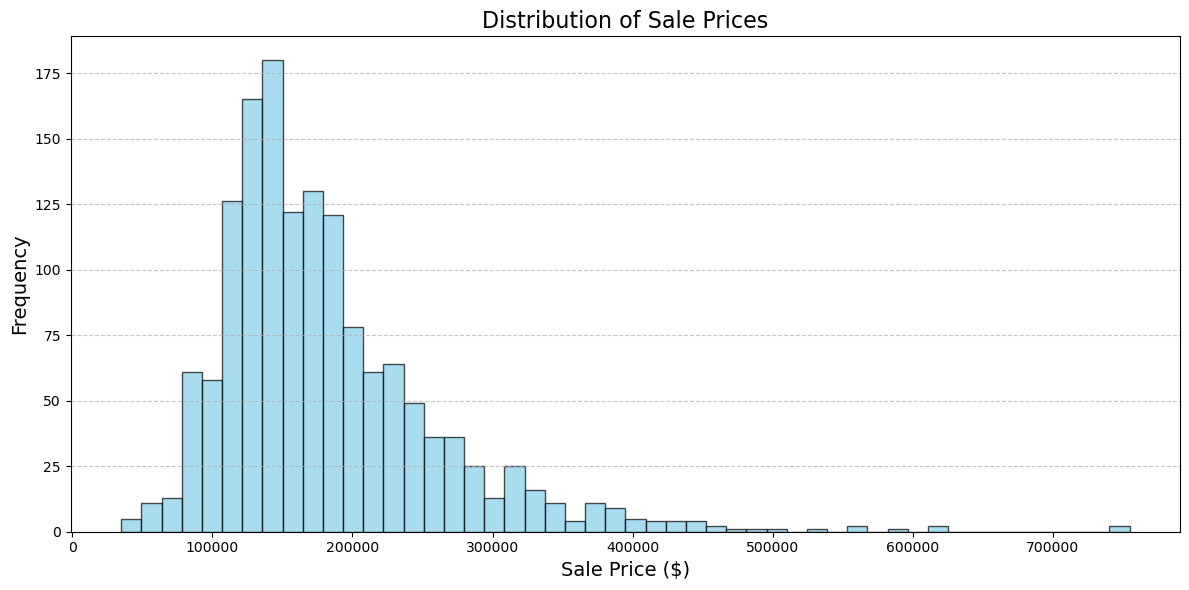

In [32]:
plt.figure(figsize=(12, 6))
plt.hist(data['SalePrice'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Sale Prices', fontsize=16)
plt.xlabel('Sale Price ($)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Analysis of Sale Price Distribution**

The histogram displays the distribution of house sale prices in the dataset:

1. **Sale Price Concentration**
   - The majority of houses have sale prices between **\\$120,000 and \\$160,000**, representing the most common price range (mode).
   - This indicates that the dataset predominantly consists of mid-range housing.

2. **Skewness**
   - The distribution is **right-skewed**, with a long tail extending toward higher sale prices.
   - This suggests that while most houses are relatively affordable, there are a few high-value properties that act as outliers.

3. **Price Ranges**
   - A significant number of houses are priced below **\\$300,000**.
   - Very few houses exceed the **\\$400,000** mark, emphasizing the rarity of high-value properties.

4. **Potential Data Considerations**
   - The skewed nature of the data may require **transformations** (e.g., log transformation) if used in predictive modeling, to mitigate the influence of high-priced outliers.
   - The dataset provides valuable insights into housing prices, primarily focusing on affordable to mid-range properties, making it suitable for **market anilysis** or **pr*cng predictions**.
ng predictions**.
ng predictions**.
ng predictions**.
ng predictions**.
ng predictions**.
ng predictions**.
ng predictions**.


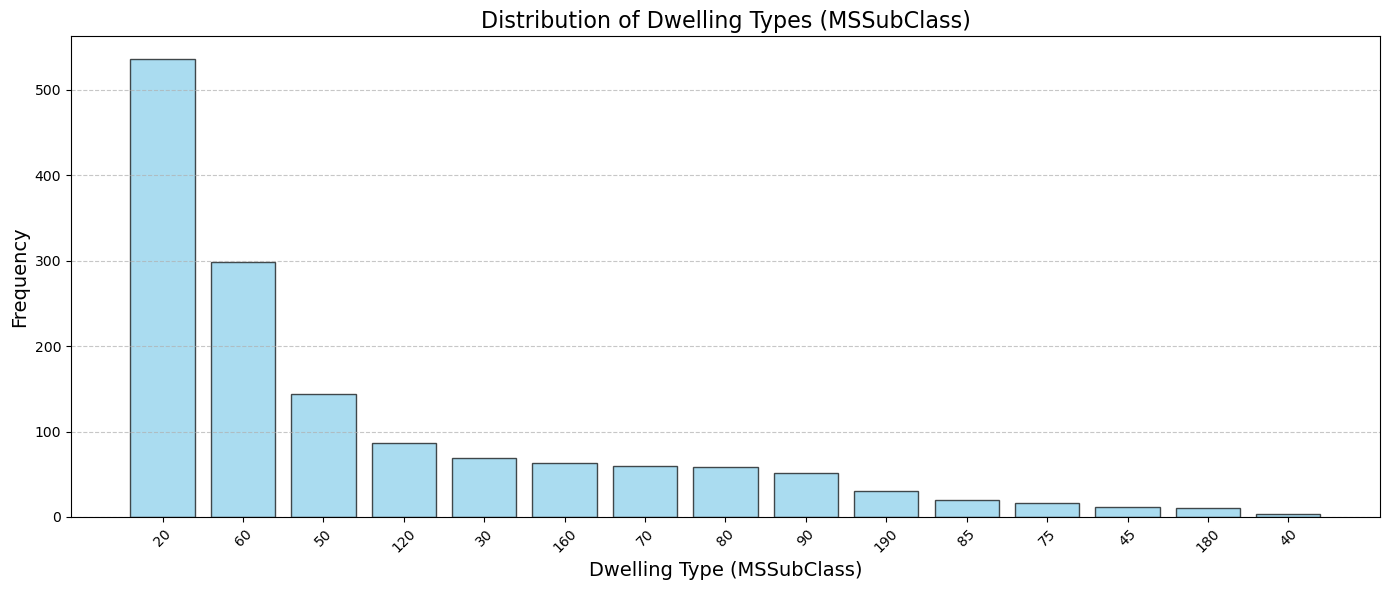

In [33]:
ms_subclass_counts = data['MSSubClass'].value_counts()

plt.figure(figsize=(14, 6))
plt.bar(ms_subclass_counts.index.astype(str), ms_subclass_counts.values, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Dwelling Types (MSSubClass)', fontsize=16)
plt.xlabel('Dwelling Type (MSSubClass)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Dwelling Types (MSSubClass)**

This histogram provides insights into the frequency of different dwelling types (`MSSubClass`) in the dataset. Here are the key takeaways:

1. **Dominant Dwelling Types**:
   - The most common dwelling type is **20 (1-STORY 1946 & NEWER ALL STYLES)**, with over 500 occurrences.
   - The second most frequent type is **60 (2-STORY 1946 & NEWER)**, with around 300 occurrences.
   - These two categories account for the majority of the houses, suggesting that newer single- and two-story houses dominate the dataset.

2. **Rare Dwelling Types**:
   - Categories like **40 (1-STORY W/FINISHED ATTIC ALL AGES)**, **180 (PUD - MULTILEVEL)**, and **75 (2-1/2 STORY ALL AGES)** have very few houses, indicating they are uncommon in this dataset.

3. **Insights About the Housing Stock**:
   - The distribution highlights that most houses fall into relatively modern and common categories, reflecting typical housing trends in the area.
   - Older or unique house styles (e.g., **1-1/2 STORY PUD**, **2-1/2 STORY**, or **SPLIT FOYER**) are less represented, which may indicate these styles are less popular or were less frequently constructed.

4. **Data Considerations**:
   - The imbalance in category frequencies could impact predictive models if `MSSubClass` is used as a feature. It may require encoding or balancing techniques to ensure less frequent categories do not disproportionately affect the results.
   - Rare dwelling types might provide unique insights, but their sparsity could make it harder to generalize patterns from them.

---

**Potential Uses for Analysis**:
- This histogram can help in understanding the housing composition of the dataset and identifying which dwelling types are prevalent or rare.
- It provides valuable context for segmentation, pricing analysis, and understanding market trends.


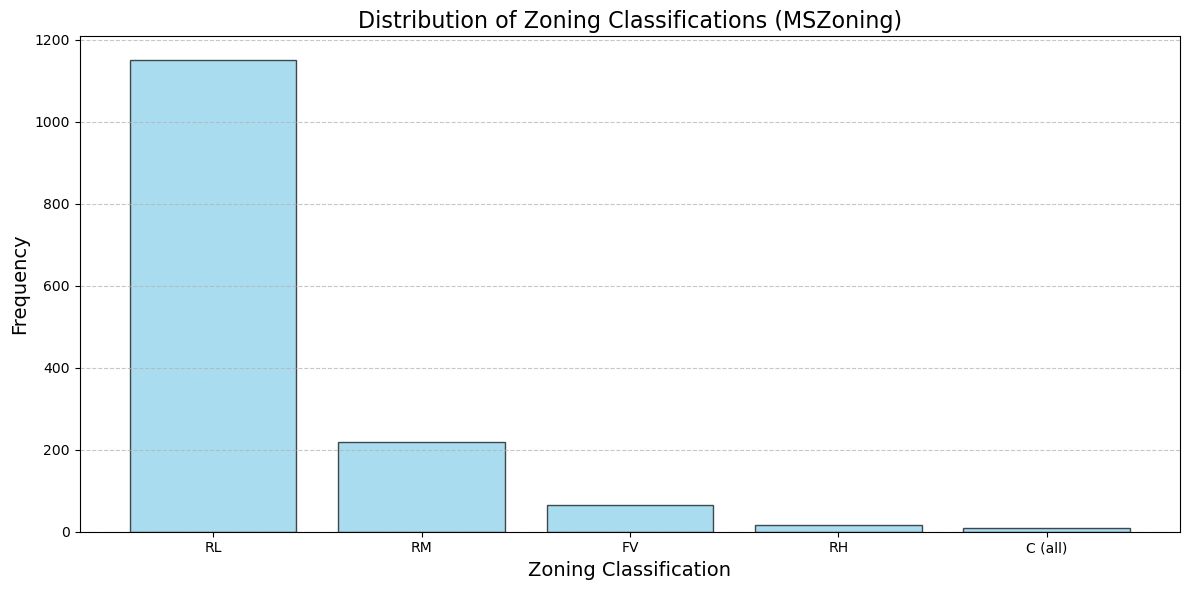

In [34]:
mszoning_counts = data['MSZoning'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(mszoning_counts.index, mszoning_counts.values, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Zoning Classifications (MSZoning)', fontsize=16)
plt.xlabel('Zoning Classification', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Zoning Classifications (MSZoning)**

This bar chart provides insights into the zoning classifications (`MSZoning`) of the houses in the dataset. Here are the key takeaways:

1. **Dominant Zoning Classification**:
   - The most prevalent zoning classification is **RL (Residential Low Density)**, accounting for the vast majority of properties (over 1,100 occurrences).
   - This indicates that most of the houses in the dataset are located in low-density residential areas, which may reflect suburban or less densely populated regions.

2. **Other Zoning Classifications**:
   - The second most frequent zoning classification is **RM (Residential Medium Density)**, with around 200 occurrences.
   - **FV (Floating Village Residential)**, **RH (Residential High Density)**, and **C (Commercial)** are far less common, indicating that these zoning types are either niche or limited in availability.

3. **Insights About Zoning Patterns**:
   - The dominance of **RL** zoning suggests that the dataset is heavily skewed toward single-family, detached housing in low-density areas.
   - The relatively smaller number of medium-density and high-density residential zones (**RM** and **RH**) could indicate fewer multi-family housing units or apartment complexes in the dataset.
   - Commercially zoned properties (**C**) are minimal, likely reflecting the focus of this dataset on residential housing.

4. **Data Considerations**:
   - The strong imbalance in the frequency of zoning classifications may need to be addressed if `MSZoning` is used as a feature in predictive modeling. Balancing techniques or careful encoding may help prevent the dominance of `RL` from overshadowing other zoning types.
   - Zoning classifications can provide valuable context for pricing models, as they may correlate with property values, development restrictions, and buyer preferences.

---

**Potential Applications**:
- **Market Analysis**: Understanding the prevalence of zoning types can inform decisions about target demographics or housing trends.
- **Pricing Analysis**: Properties in less common zones (e.g., **FV**, **RH**, or **C**) may have unique pricing dynamics due to their scarcity.
- **Urban Planning Insights**: The dataset's focus on low-density residential zoning highlights patterns that may align with suburban development.


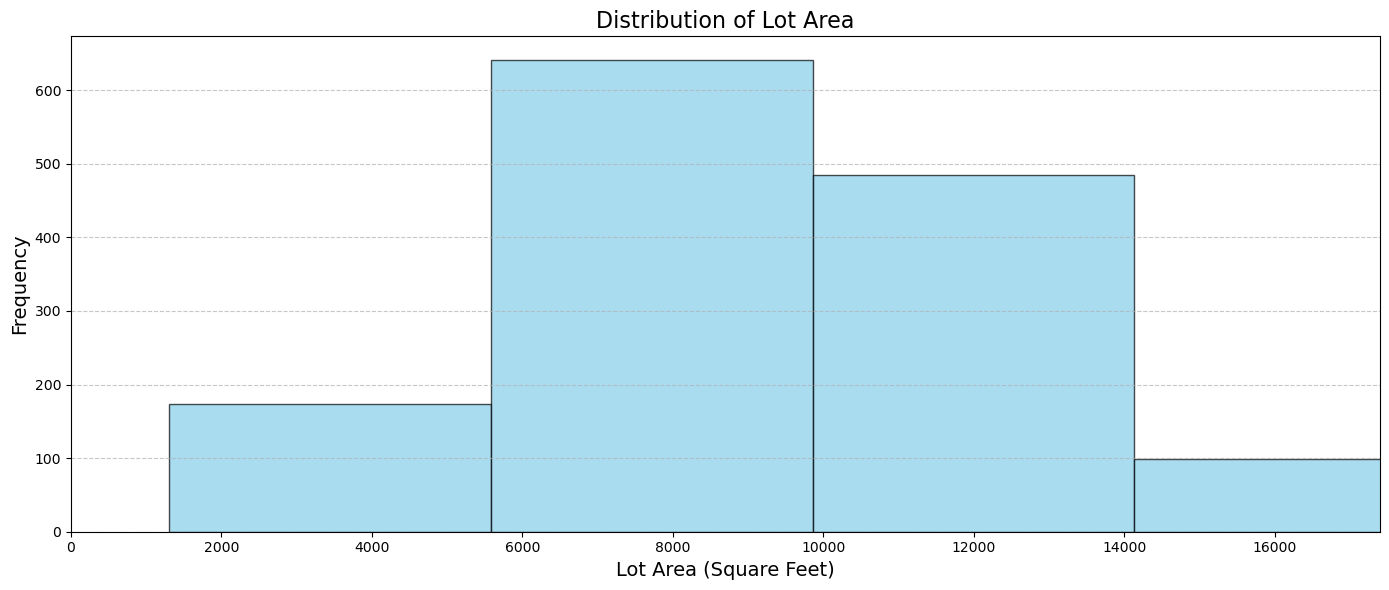

In [35]:
plt.figure(figsize=(14, 6))
plt.hist(data['LotArea'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Lot Area', fontsize=16)
plt.xlabel('Lot Area (Square Feet)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.xlim(0, data['LotArea'].quantile(0.95))  # Focus on the lower 95% of values to reduce outlier impact

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Lot Area**

The histogram provides insights into the distribution of lot sizes (`LotArea`) in the dataset. Here are the key observations:

1. **Concentration of Lot Areas**:
   - The majority of lot sizes are concentrated between **6,000 and 14,000 square feet**, as evident from the tall bars in the middle range.
   - This suggests that most houses in the dataset are built on standard-sized residential lots, reflecting typical suburban or residential developments.

2. **Smaller Lot Areas**:
   - A noticeable number of properties have smaller lots (under **6,000 square feet**), which could indicate denser urban or medium-density residential areas.

3. **Larger Lot Areas**:
   - There are relatively fewer properties with lot sizes exceeding **14,000 square feet**, reflecting that large lots are less common.

4. **Potential Exclusion of Outliers**:
   - The x-axis is limited to the **95th percentile** of lot areas, excluding the largest lot sizes. While this improves the visibility of the main distribution, it means that **extreme outliers** (very large lots) are not represented in the histogram.

5. **Skewed Distribution**:
   - The distribution is **right-skewed**, with a long tail toward larger lot areas. This indicates the presence of outliers, even though they are not shown in this histogram.

6. **Insights on Housing Characteristics**:
   - The distribution highlights that the dataset primarily consists of standard-sized lots, with a small portion of unusually large or small properties. This aligns with typical residenanalyses or predictive modeling.


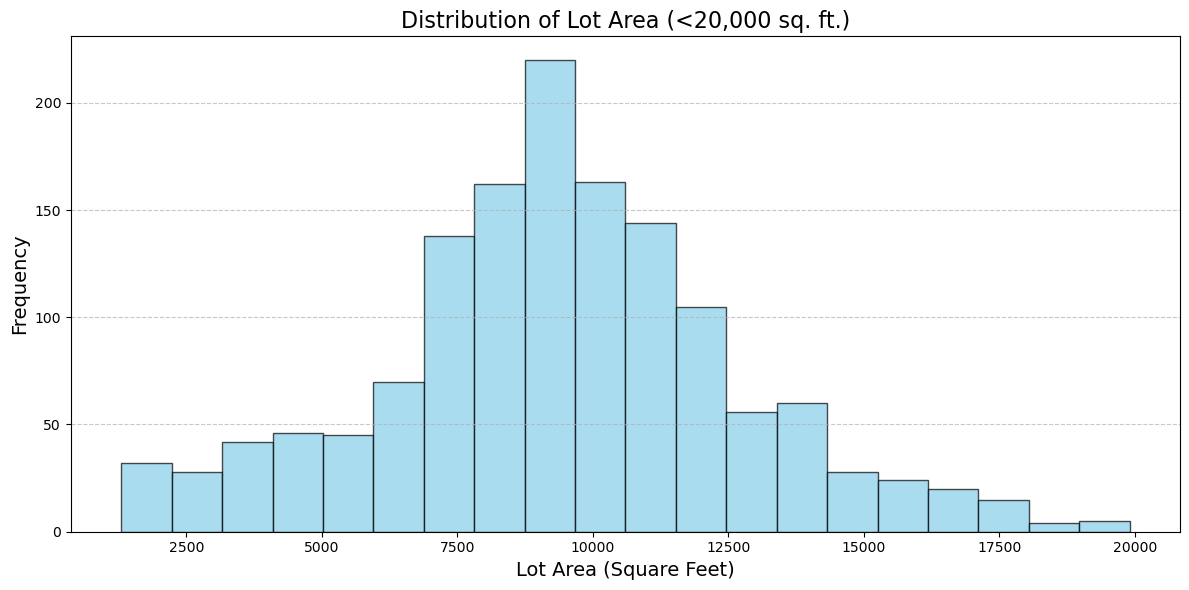

In [36]:
plt.figure(figsize=(12, 6))
plt.hist(data.loc[data['LotArea'] < 20000, 'LotArea'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Lot Area (<20,000 sq. ft.)', fontsize=16)
plt.xlabel('Lot Area (Square Feet)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Lot Area (<20,000 sq. ft.)**

This histogram provides a refined view of `LotArea` values, focusing on properties with lot sizes under **20,000 square feet**. Let’s analyze it in comparison to the previous histogram, which included all lot areas:

---

**Key Observations**:
1. **Improved Focus**:
   - By limiting the lot area to properties below **20,000 square feet**, this histogram excludes outliers (very large lots) that previously skewed the visualization.
   - This allows for a clearer understanding of the **main distribution**, which represents the majority of properties.

2. **Normal Distribution Shape**:
   - The histogram now resembles a **bell-shaped curve**, indicating that most lot areas cluster around a central range, with fewer properties on either extreme.
   - The peak occurs near **10,000 square feet**, which appears to be the most common lot size for properties in this dataset.

3. **Smaller and Larger Lots**:
   - There are relatively fewer properties with lot sizes under **5,000 square feet**, suggesting that smaller lots are less common.
   - Similarly, properties with lot sizes exceeding **15,000 square feet** are uncommon, representing the upper end of the lot area range.

4. **Range Representation**:
   - This histogram captures **nearly all typical properties**, as very few lots exceed the **20,000 sq. ft. threshold**. By excluding outliers, the visualization remains informative without unnecessary compression of the main distribution.

5. **Comparison with Previous Histogram**:
   - The earlier histogram included outliers, which stretched the x-axis and compressed the distribution of smaller lots, making it harder to interpret.
   - This refined histogram provides better granularity, highlighting the main trends without being influenced by extreme values.

---

**Insights for Analysis**:
1. **Central Range**:
   - Most properties have lot sizes between **7,500 and 12,500 square feet**, aligning with typical suburban housing developments.

2. **Outliers**:
   - Larger lots above 20,000 square feet (excluded here) are rare and should be analyzed separately to understand their characteristics (e.g., pricing or zoning differences).

3. **Applicability**:
   - This distribution is representative of the dataset's typical properties and can be used for predictive modeling or market analysis without distortion from outliers.

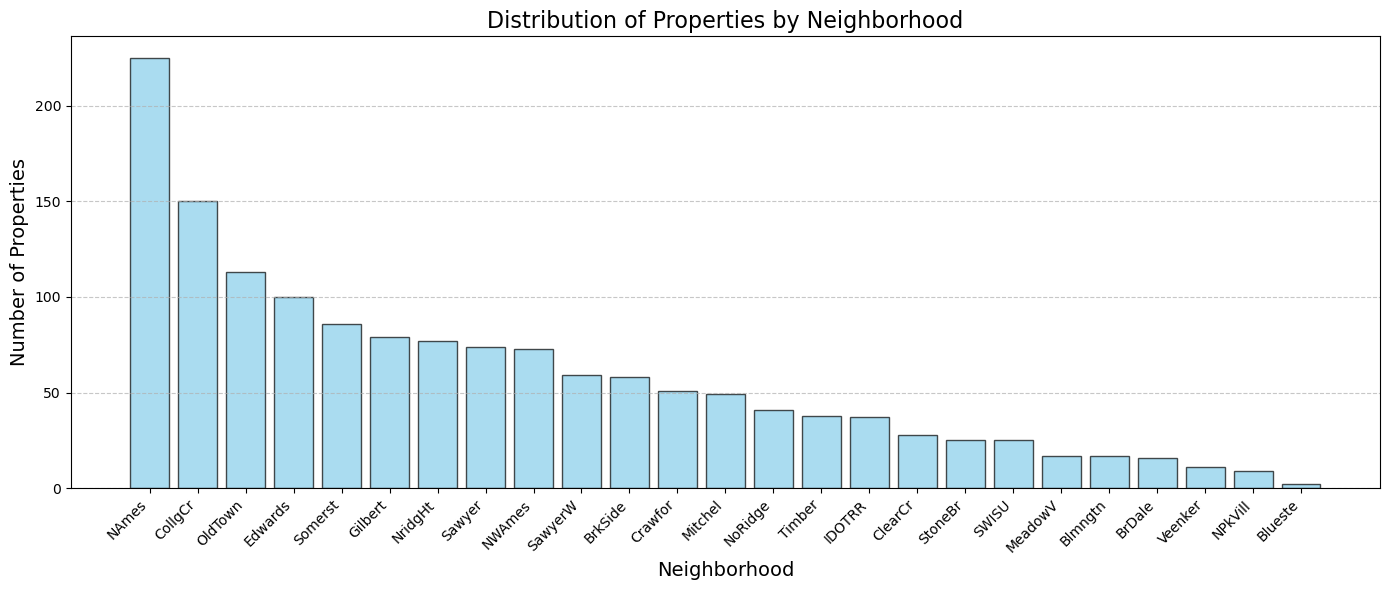

In [37]:
neighborhood_counts = data['Neighborhood'].value_counts(ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(neighborhood_counts.index, neighborhood_counts.values, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Properties by Neighborhood', fontsize=16)
plt.xlabel('Neighborhood', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)

plt.xticks(rotation=45, fontsize=10, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Updated Comments on the Distribution of Properties by Neighborhood**

This bar chart represents the count of properties in each neighborhood, which are **physical locations within Ames city limits**. The following observations are updated with the context of neighborhood names and their descriptions:

---

**Key Observations**:
1. **Dominant Neighborhoods**:
   - The **North Ames (NAmes)** neighborhood has the highest representation in the dataset, with over **200 properties**. This suggests that it is a highly populated or frequently studied area.
   - **College Creek (CollgCr)** and **Old Town (OldTown)** are the next most represented neighborhoods, each with over **100 properties**.

2. **Moderately Represented Neighborhoods**:
   - Neighborhoods like **Edwards**, **Somerset**, and **Gilbert** have between **100 and 150 properties**, indicating a balanced representation in the dataset.

3. **Least Represented Neighborhoods**:
   - Some neighborhoods, such as **Bluestem (Blueste)**, **Northpark Villa (NPkVill)**, and **Veenker**, have very few properties (less than 20). These neighborhoods are rare in the dataset and may represent less developed or less frequently sampled areas.

4. **Skewed Representation**:
   - The distribution is highly **skewed**, with a few neighborhoods like **NAmes**, **CollgCr**, and **OldTown** dominating the dataset. Many neighborhoods, particularly **Blueste** and **NPkVill**, have significantly lower representation.

---

**Insights for Analysis**:
1. **Imbalanced Neighborhood Representation**:
   - The dominance of certain neighborhoods like **North Ames (NAmes)** may create biases in analyses or predictive models. Balancing the representation or accounting for this imbalance is crucial.

2. **Market Characteristics**:
   - The high representation of certain neighborhoods could reflect housing demand, population density, or the focus of the dataset on specific areas within Ames.

3. **Rare Neighborhoods**:
   - Rare neighborhoods like **Bluestem** and **Northpark Villa** could exhibit unique characteristics, such as higher property values or specific zoning restrictions, which are worth investigating separately.l** to understand what makes them distinct.


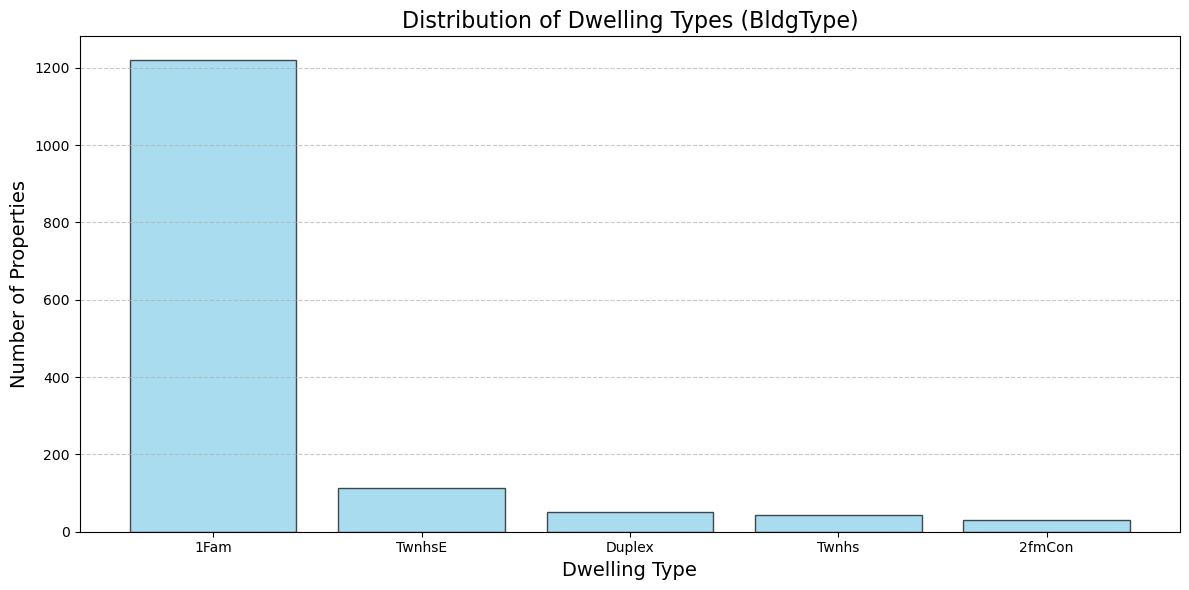

In [38]:
bldgtype_counts = data['BldgType'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(bldgtype_counts.index, bldgtype_counts.values, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Dwelling Types (BldgType)', fontsize=16)
plt.xlabel('Dwelling Type', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Dwelling Types (BldgType)**

This bar chart represents the distribution of properties based on their building type (`BldgType`). Here are the key takeaways:

---

**Key Observations**:
1. **Dominant Dwelling Type**:
   - The majority of properties (**~1200**) are classified as **1Fam (Single-family Detached)**, making it the overwhelmingly dominant building type in the dataset.
   - This suggests that the dataset focuses heavily on standalone, single-family homes, reflecting common residential trends.

2. **Other Dwelling Types**:
   - The remaining dwelling types have significantly fewer properties:
     - **TwnhsE (Townhouse End Unit)** and **TwnhsI (Townhouse Inside Unit)** have moderate representation.
     - **Duplex** and **2FmCon (Two-family Conversion)** are the least represented, each with a small number of properties.

3. **Skewed Distribution**:
   - The distribution is highly **skewed**, with single-family detached homes dominating and other building types contributing only a small fraction of the dataset.

---

**Insights for Analysis**:
1. **Focus on Single-Family Homes**:
   - The dataset is likely tailored for analyzing single-family residential housing, with minimal data on multi-family dwellings or townhomes.

2. **Imbalance in Building Types**:
   - The skewed representation may impact predictive modeling or analysis if `BldgType` is used as a feature. Adjustments like weighting or balancing may be required.

3. **Market Trends**:
   - The high number of single-family homes likely reflects suburban housing patterns, where such properties are the norm.
   - The lower frequency of duplexes and townhouses might indicate limited availability of multi-family dwellings in the region.

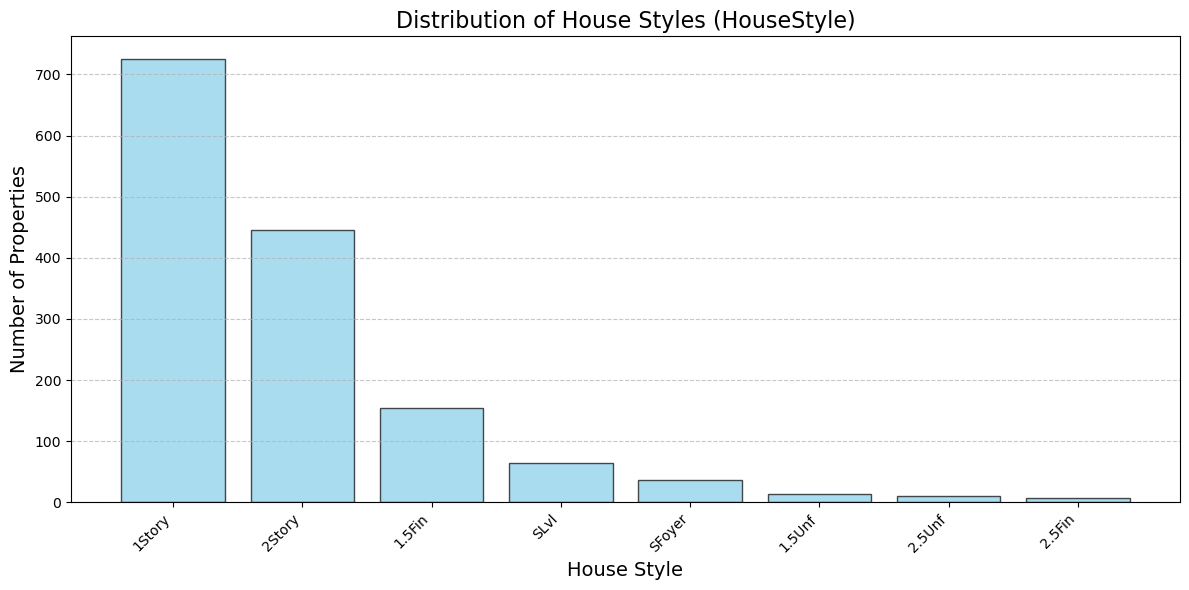

In [39]:
housestyle_counts = data['HouseStyle'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(housestyle_counts.index, housestyle_counts.values, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of House Styles (HouseStyle)', fontsize=16)
plt.xlabel('House Style', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)

plt.xticks(rotation=45, fontsize=10, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of House Styles (HouseStyle)**

This bar chart provides insights into the distribution of house styles in the dataset. Here are the key observations:

---

**Key Observations**:
1. **Dominant House Styles**:
   - **1Story (One story)** houses dominate the dataset, with over **700 properties**, making them the most common style of dwelling.
   - **2Story (Two story)** houses are the second most common, with around **400 properties**.

2. **Moderately Represented Styles**:
   - **1.5Fin (One and one-half story: 2nd level finished)** houses have a moderate presence, with just over **100 properties**.
   - **SLvl (Split Level)** and **SFoyer (Split Foyer)** houses have fewer properties, but they are still noticeable in the dataset.

3. **Rare House Styles**:
   - House styles like **1.5Unf (One and one-half story: 2nd level unfinished)**, **2.5Unf (Two and one-half story: 2nd level unfinished)**, and **2.5Fin (Two and one-half story: 2nd level finished)** are extremely rare, with very few properties.

4. **Skewed Distribution**:
   - The distribution is heavily **skewed**, with a significant focus on **1Story** and **2Story** houses, while other styles are far less represented.

---

**Insights for Analysis**:
1. **Suburban Housing Patterns**:
   - The dominance of **1Story** and **2Story** houses likely reflects suburban or family-oriented housing trends, where such designs are common.

2. **Imbalance in Styles**:
   - The dataset's heavy focus on **1Story** and **2Story** houses may bias any analysis that relies on the `HouseStyle` feature. Rare house styles like **1.5Unf** or **2.5Unf** may require separate treatment or stratified analysis.

3. **Potential Niche Markets**:
   - Rare house styles may represent niche markets, such as properties with unique architectural designs or specific buyer preferences.

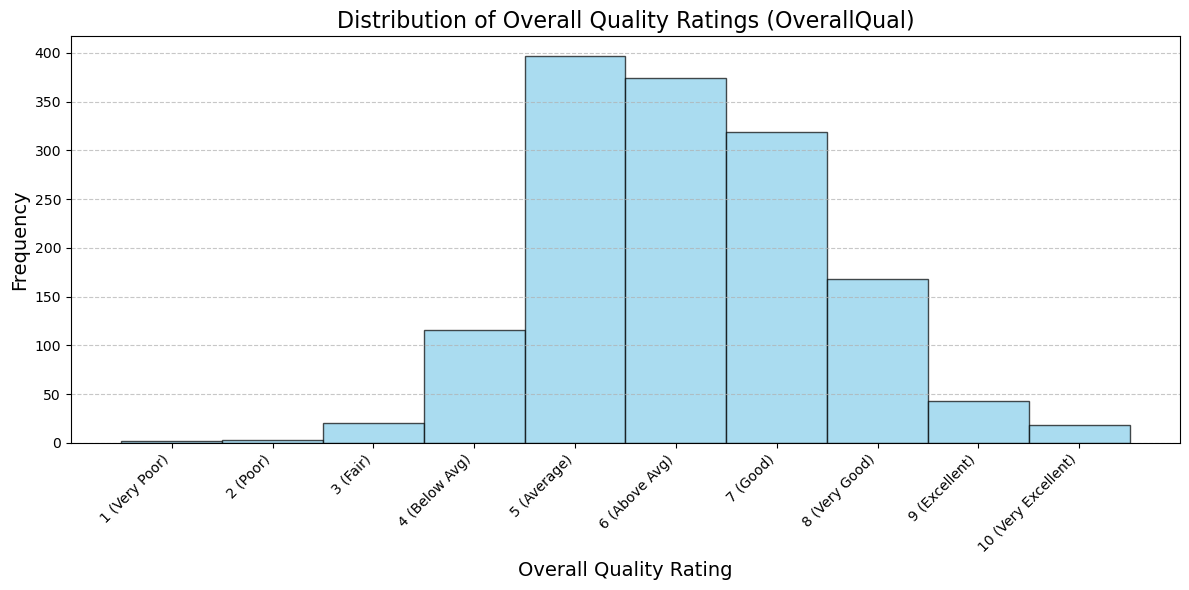

In [40]:
plt.figure(figsize=(12, 6))
plt.hist(data['OverallQual'], bins=range(1, 12), color='skyblue', edgecolor='black', alpha=0.7, align='left')

plt.title('Distribution of Overall Quality Ratings (OverallQual)', fontsize=16)
plt.xlabel('Overall Quality Rating', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.xticks(range(1, 11), [
    '1 (Very Poor)', '2 (Poor)', '3 (Fair)', '4 (Below Avg)', '5 (Average)', 
    '6 (Above Avg)', '7 (Good)', '8 (Very Good)', '9 (Excellent)', '10 (Very Excellent)'
], rotation=45, ha='right', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Overall Quality Ratings (OverallQual)**

This bar chart provides insights into the distribution of overall material and finish quality ratings (`OverallQual`) of the houses in the dataset. The ratings range from **1 (Very Poor)** to **10 (Very Excellent)**. Here are the key observations:

---

**Key Observations**:
1. **Most Common Ratings**:
   - The majority of properties are rated **5 (Average)**, **6 (Above Average)**, and **7 (Good)**, making up the central portion of the distribution.
   - These ratings reflect typical construction quality, with a focus on average to slightly above-average properties.

2. **Higher Quality Ratings**:
   - Houses rated **8 (Very Good)** and **9 (Excellent)** are present but less common than the central ratings.
   - Very high-quality houses rated **10 (Very Excellent)** are rare, indicating that top-tier properties are exceptional in the dataset.

3. **Lower Quality Ratings**:
   - Houses rated **4 (Below Average)** and below are infrequent.
   - Very poor quality properties, rated **1 (Very Poor)** or **2 (Poor)**, are almost negligible, suggesting a minimal focus on poorly constructed homes.

4. **Symmetrical Distribution**:
   - The distribution has a slightly **right-skewed** shape, with a peak around **6 (Above Average)** and fewer properties at the extreme ends of the scale.

---

**Insights for Analysis**:
1. **Focus on Mid-Range Quality**:
   - The dataset predominantly represents mid-range quality properties, which aligns with typical housing market trends.

2. **Rarity of Extremes**:
   - Both extremely low and extremely high-quality properties are underrepresented. This could impact analysis or modeling of features that are highly dependent on property quality.

3. **Market Trends**:
   - The skew toward **5 (Average)** to **7 (Good)** ratings suggests a focus on homes catering to broader market demand rather than luxury or budget housing.

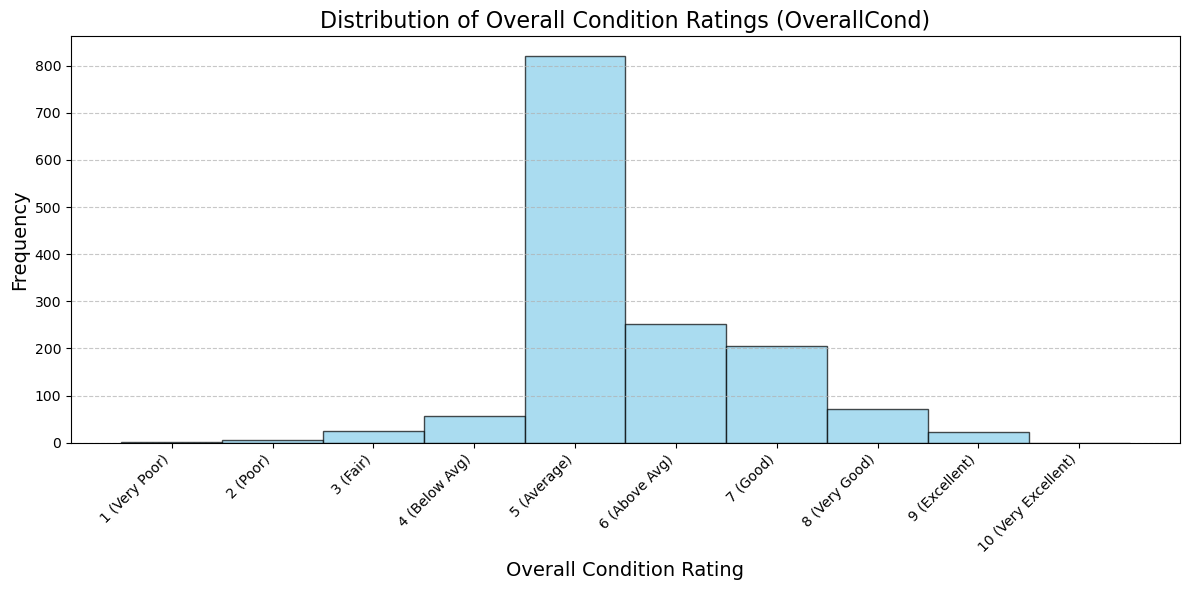

In [41]:
plt.figure(figsize=(12, 6))
plt.hist(data['OverallCond'], bins=range(1, 12), color='skyblue', edgecolor='black', alpha=0.7, align='left')

plt.title('Distribution of Overall Condition Ratings (OverallCond)', fontsize=16)
plt.xlabel('Overall Condition Rating', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.xticks(range(1, 11), [
    '1 (Very Poor)', '2 (Poor)', '3 (Fair)', '4 (Below Avg)', '5 (Average)', 
    '6 (Above Avg)', '7 (Good)', '8 (Very Good)', '9 (Excellent)', '10 (Very Excellent)'
], rotation=45, ha='right', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Overall Condition Ratings (OverallCond)**

This bar chart illustrates the distribution of overall condition ratings (`OverallCond`) of houses in the dataset. The ratings range from **1 (Very Poor)** to **10 (Very Excellent)**, reflecting the physical condition of the houses.

---

**Key Observations**:
1. **Predominance of Average Condition**:
   - The majority of houses are rated **5 (Average)**, with nearly **800 properties**, making it the most common condition rating.
   - This suggests that most properties in the dataset are in an expected, standard condition without significant issues or exceptional improvements.

2. **Moderately Good Conditions**:
   - Houses rated **6 (Above Average)** and **7 (Good)** are also well-represented, indicating a notable proportion of properties with slightly better-than-average conditions.

3. **Lower and Higher Extremes**:
   - Houses rated **8 (Very Good)**, **9 (Excellent)**, and **10 (Very Excellent)** are rare, reflecting limited representation of properties in excellent condition.
   - Similarly, houses rated **4 (Below Average)** and below are uncommon, indicating minimal representation of poorly maintained properties.

4. **Skewed Distribution**:
   - The distribution is **right-skewed**, with the bulk of properties clustering around **5 (Average)** and tapering off toward both lower and higher ratings.

---

**Insights for Analysis**:
1. **Market Trends**:
   - The focus on average and slightly above-average conditions aligns with typical housing markets, where most homes are maintained to meet standard living conditions.

2. **Lack of Extreme Conditions**:
   - The low number of properties rated at the extremes (1–2 or 9–10) suggests that the dataset primarily captures mid-range properties rather than luxury or severely neglected homes.

3. **Predictive Modeling**:
   - The skewed distribution could impact predictive modeling if `OverallCond` is used as a feature. Adjustments may be necessary to ensure rare condition ratings are not overshadowed by the dominant **5 (Average)** category.

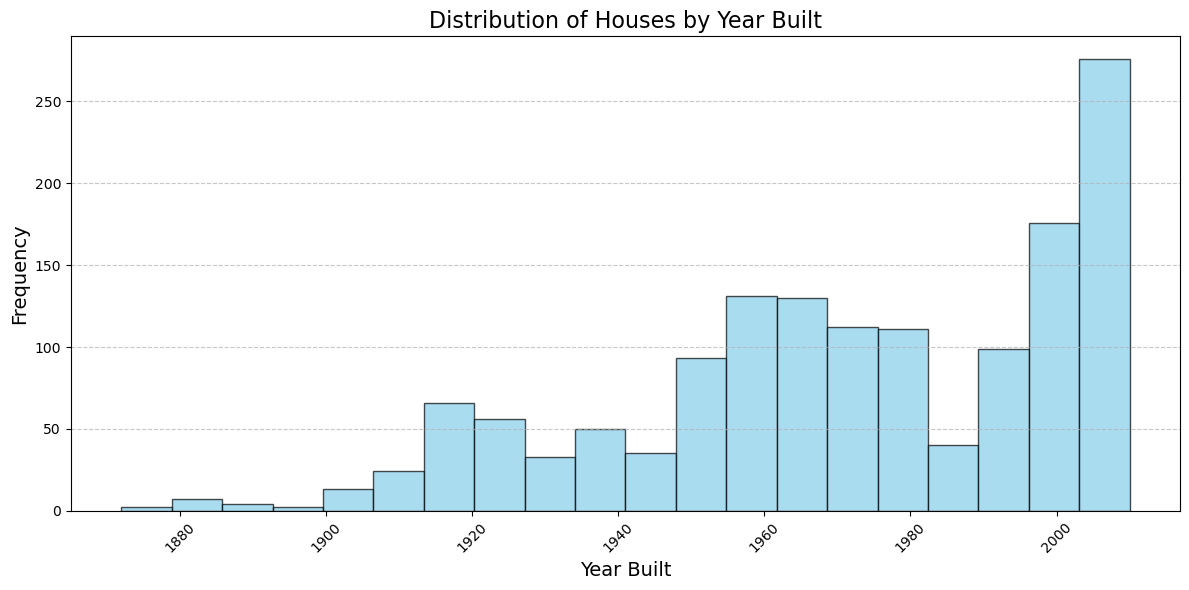

In [42]:
plt.figure(figsize=(12, 6))
plt.hist(data['YearBuilt'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Houses by Year Built', fontsize=16)
plt.xlabel('Year Built', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.xticks(fontsize=10, rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Houses by Year Built**

This histogram illustrates the distribution of houses based on their year of construction. It highlights trends in housing development over time, revealing periods of high and low construction activity.

---

**Key Observations**:
1. **Recent Construction Boom**:
   - The highest concentration of houses was built after the year **2000**, with over **250 properties**. This reflects a significant construction boom in recent decades.

2. **Mid-20th Century Development**:
   - Between **1950 and 1980**, there was consistent construction activity, with each decade contributing a substantial number of properties.

3. **Pre-1950 Construction**:
   - Houses built before **1950** are fewer, with relatively lower frequencies observed for earlier years. This indicates that older properties represent a smaller share of the dataset.

4. **Early 20th Century Trend**:
   - There is a noticeable rise in construction during the early **1900s**, peaking around the **1920s**, followed by a gradual decline until the mid-20th century.

5. **Skewed Distribution**:
   - The distribution is heavily **right-skewed**, indicating that the majority of houses in the dataset were built in the late 20th century or later.

---

**Insights for Analysis**:
1. **Market Focus**:
   - The dataset primarily represents modern housing, with a heavy emphasis on properties built after **1950**. This reflects the dominant construction trends in suburban development.

2. **Vintage Properties**:
   - Houses built before **1950** are fewer and may represent historical or unique architectural styles, potentially influencing their valuation or buyer appeal.

3. **Construction Trends**:
   - The peak in recent construction activity post-2000 may align with housing demands, urban expansion, or economic growth during that period.

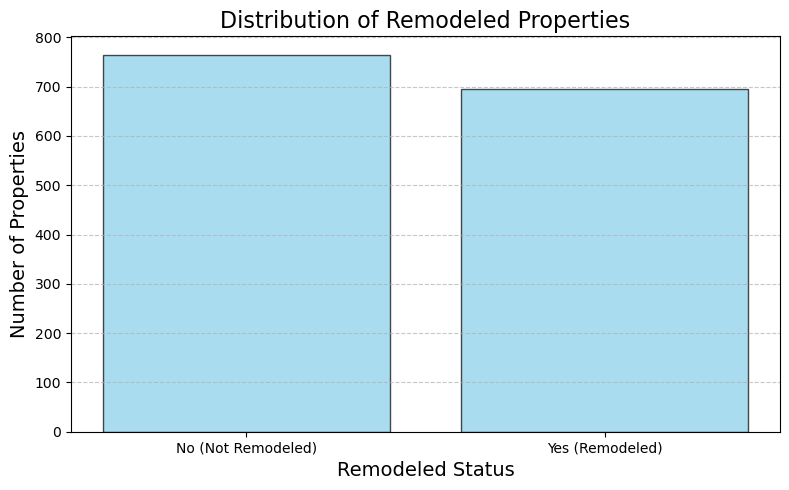

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(
    ['No (Not Remodeled)', 'Yes (Remodeled)'], 
    [data['Remodeled'].value_counts().iloc[0], data['Remodeled'].value_counts().iloc[1]], 
    color='skyblue', edgecolor='black', alpha=0.7
)

plt.title('Distribution of Remodeled Properties', fontsize=16)
plt.xlabel('Remodeled Status', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Remodeled Properties**

This bar chart shows the distribution of properties based on whether they have been remodeled or not. The data is divided into two categories: "Not Remodeled" and "Remodeled."

---

**Key Observations**:
1. **Slight Majority for Not Remodeled**:
   - Properties that **have not been remodeled** slightly outnumber those that have been remodeled.
   - Approximately **700+ properties** are in the "Not Remodeled" category, while **600+ properties** are in the "Remodeled" category.

2. **Even Distribution**:
   - The distribution is fairly balanced, indicating that a substantial proportion of properties in the dataset have undergone remodeling.
   - This balance might reflect an active housing market where renovations and updates are common.

---

**Insights for Analysis**:
1. **Potential for Feature Impact**:
   - The presence of remodeled properties suggests that `Remodeled` could be a valuable feature in analyzing pricing, desirability, or other market-related trends.

2. **Market Trends**:
   - The near-equal distribution might indicate that remodeling is a frequent activity, possibly reflecting homeowners' efforts to maintain or increase property value.

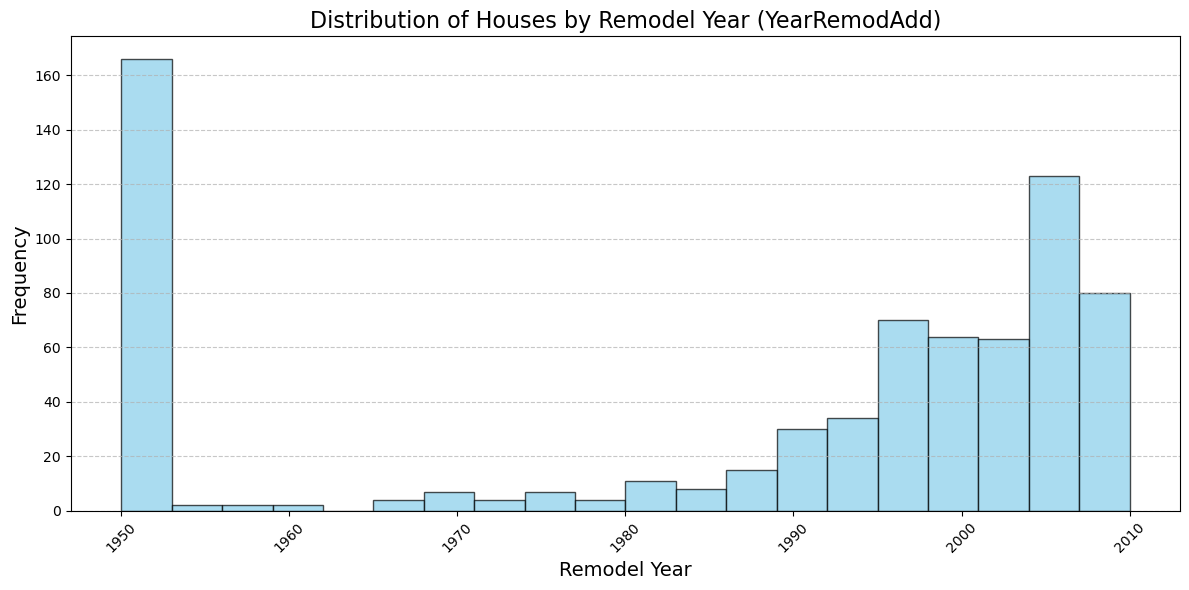

In [44]:
plt.figure(figsize=(12, 6))
plt.hist(
    data.loc[data['YearRemodAdd'] != 0, 'YearRemodAdd'], 
    bins=20, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.7
)

plt.title('Distribution of Houses by Remodel Year (YearRemodAdd)', fontsize=16)
plt.xlabel('Remodel Year', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.xticks(fontsize=10, rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Houses by Remodel Year (YearRemodAdd)**

This histogram displays the distribution of properties based on their most recent remodel year. The histogram highlights trends in renovation activity over time and identifies periods of significant remodeling efforts.

---

**Key Observations**:
1. **High Frequency for 1950**:
   - A large number of houses are recorded as remodeled in **1950**. This is likely due to the fact that **1950** serves as the default construction year for properties that have never been remodeled.

2. **Increased Remodeling Post-1990**:
   - Remodeling activity shows a marked increase starting in the **1990s**, with frequencies steadily rising through the **2000s**. This suggests heightened awareness of home renovation during these decades.

3. **Recent Activity (2000s)**:
   - The years **2000 to 2010** show a peak in remodeling activity, reflecting a period of modernization and renovation across the housing market.

4. **Sparse Activity Pre-1980**:
   - Very little remodeling is recorded before **1980**, which aligns with older properties likely being renovated only in recent decades.

---

**Insights for Analysis**:
1. **Remodeling Trends**:
   - The increasing frequency of remodels in the **1990s and 2000s** likely reflects trends such as urban redevelopment, home value appreciation, or changes in homeownership dynamics.

2. **1950 Default Value**:
   - Houses labeled as remodeled in **1950** may not have undergone renovations, but instead, the field defaults to the construction year if no remodel is recorded. This distinction is crucial for accurate analysis.

3. **Recent Renovations**:
   - The high frequency of renovations in the last 20 years could correlate with rising home improvement spending or economic growth during this period.

---

**Recommendations**:
1. **Exclude 1950 Default Values**:
   - When analyzing remodel impacts on property value, consider excluding **1950** or handling it as a separate category since it may not represent actual remodels.

2. **Focus on Recent Decades**:
   - For modeling or trend analysis, prioritize data from **1980 onwards**, where most remodeling activity is recorded.

3. **Investigate Drivers of Peaks**:
   - Explore potential drivers of increased remodeling in the **2000s** (e.g., economic conditions, housing policies) to understand their market implications.


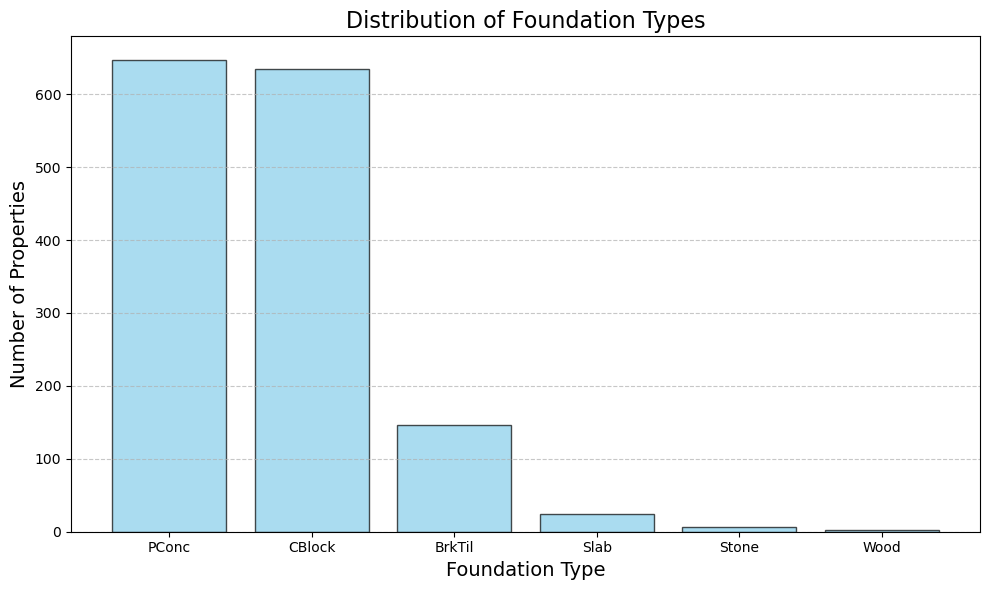

In [45]:
foundation_counts = data['Foundation'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(
    foundation_counts.index, 
    foundation_counts.values, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.7
)

plt.title('Distribution of Foundation Types', fontsize=16)
plt.xlabel('Foundation Type', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Foundation Types**

This bar chart displays the distribution of different foundation types in the dataset. It highlights the frequencies of various foundation materials used in the construction of properties.

---

**Key Observations**:
1. **Dominance of `PConc` and `CBlock`**:
   - The most commonly used foundation types are **Poured Concrete (`PConc`)** and **Cinder Block (`CBlock`)**, with each accounting for over **600 properties**.
   - These two foundation types are clearly dominant, likely reflecting modern and cost-effective construction practices.

2. **Limited Use of Other Foundation Types**:
   - **Brick & Tile (`BrkTil`)** is the third most common foundation type, with around **100 properties**.
   - **Slab**, **Stone**, and **Wood** are far less common, each contributing only a handful of properties to the dataset.

3. **Practical Preference**:
   - The popularity of `PConc` and `CBlock` suggests that these materials are favored for their durability, cost-efficiency, and compatibility with contemporary building codes.

---

**Insights for Analysis**:
1. **Modern Construction Trends**:
   - The dominance of `PConc` and `CBlock` likely indicates that the dataset primarily consists of modern or recently constructed properties, as these materials are widely used in contemporary construction.

2. **Unique Characteristics**:
   - Properties with less common foundation types (`Slab`, `Stone`, or `Wood`) might have unique characteristics, such as historical significance or unconventional architectural designs, which could influence their market value.

3. **Market Value Impact**:
   - Foundation type could be an important feature to analyze when predicting property prices, as some types (e.g., `PConc`) might be associated with higher-quality construction.

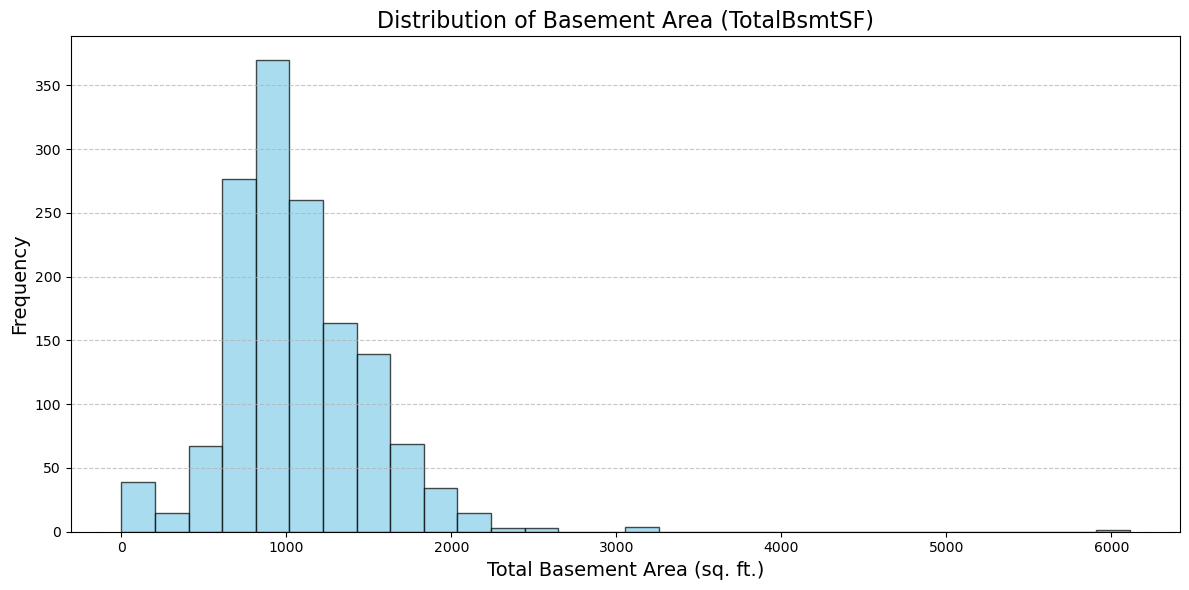

In [46]:
plt.figure(figsize=(12, 6))
plt.hist(
    data['TotalBsmtSF'], 
    bins=30, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.7
)

plt.title('Distribution of Basement Area (TotalBsmtSF)', fontsize=16)
plt.xlabel('Total Basement Area (sq. ft.)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Basement Area (TotalBsmtSF)**

This histogram shows the distribution of total basement areas (in square feet) across the dataset, highlighting the range and frequency of basement sizes in the properties.

---

**Key Observations**:
1. **Central Tendency**:
   - The majority of properties have a basement area concentrated around **1,000 square feet**, with the peak frequency in the range of **800 to 1,200 square feet**.
   - This indicates that mid-sized basements are the norm in this dataset.

2. **Right-Skewed Distribution**:
   - The distribution is right-skewed, with a long tail extending toward larger basement areas, up to **6,000 square feet**. 
   - This suggests that while larger basements are rare, they do exist and may represent luxurious or custom-built properties.

3. **Smaller Basements**:
   - A significant number of properties have smaller basements under **800 square feet**, which might include homes with partial basements or minimal underground spaces.

4. **Outliers**:
   - The presence of a few properties with exceptionally large basement areas (over **3,000 square feet**) highlights potential outliers, which could represent multi-story basements or exceptionally large homes.

---

**Insights for Analysis**:
1. **Market Segmentation**:
   - Properties with larger basements might cater to premium buyers or specific market segments. Investigating the correlation between basement size and property price could provide valuable insights.

2. **Utility of Smaller Basements**:
   - Small basement areas might indicate older properties, non-conventional construction types, or homes located in specific neighborhoods with limited space for basements.

3. **Outliers for Further Study**:
   - Properties with extremely large basements (>3,000 sq. ft.) might require closer examination for data accuracy or unique market characteristics.

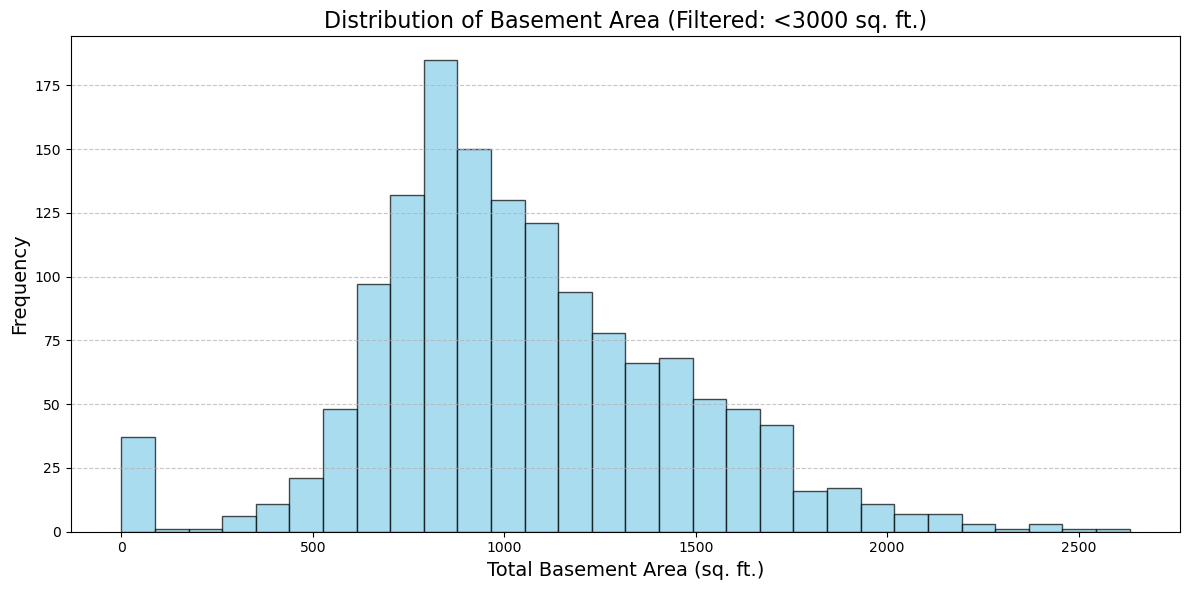

In [47]:
plt.figure(figsize=(12, 6))
plt.hist(
    data.loc[data['TotalBsmtSF'] < 3000, 'TotalBsmtSF'], 
    bins=30, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.7
)

plt.title('Distribution of Basement Area (Filtered: <3000 sq. ft.)', fontsize=16)
plt.xlabel('Total Basement Area (sq. ft.)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Comments on the Distribution of Basement Area (Filtered: <3000 sq. ft.)**

This histogram provides a detailed view of the distribution of basement areas under 3,000 square feet, offering a more focused perspective on typical properties while excluding outliers.

---

**Key Observations**:
1. **Central Tendency**:
   - The majority of basement areas fall between **800 and 1,200 square feet**, with the peak frequency at approximately **1,000 square feet**.
   - This reflects the prevalence of mid-sized basements among properties in the dataset.

2. **Symmetry Around the Mode**:
   - The distribution is approximately **normal** (bell-shaped), indicating that most properties have basement sizes close to the average, with fewer properties having very small or very large basements.

3. **Zero Basement Area**:
   - A notable frequency of properties has a **0-square-foot basement area**, representing houses without basements, possibly slab or crawlspace foundations.

4. **Decline Toward Larger Areas**:
   - Beyond **1,500 square feet**, there is a consistent decline in frequency, with very few basements exceeding **2,000 square feet**.

---

**Insights for Analysis**:
1. **Popular Basement Sizes**:
   - The clustering around 1,000 square feet suggests that this size may be the standard for many homebuyers or builders.

2. **No-Basement Properties**:
   - The proportion of properties with no basements is significant and might correlate with specific neighborhoods or construction styles.

3. **Diversity in Sizes**:
   - The inclusion of properties with larger basements shows diversity in property design, likely influenced by factors such as lot size, building era, and intended property use.

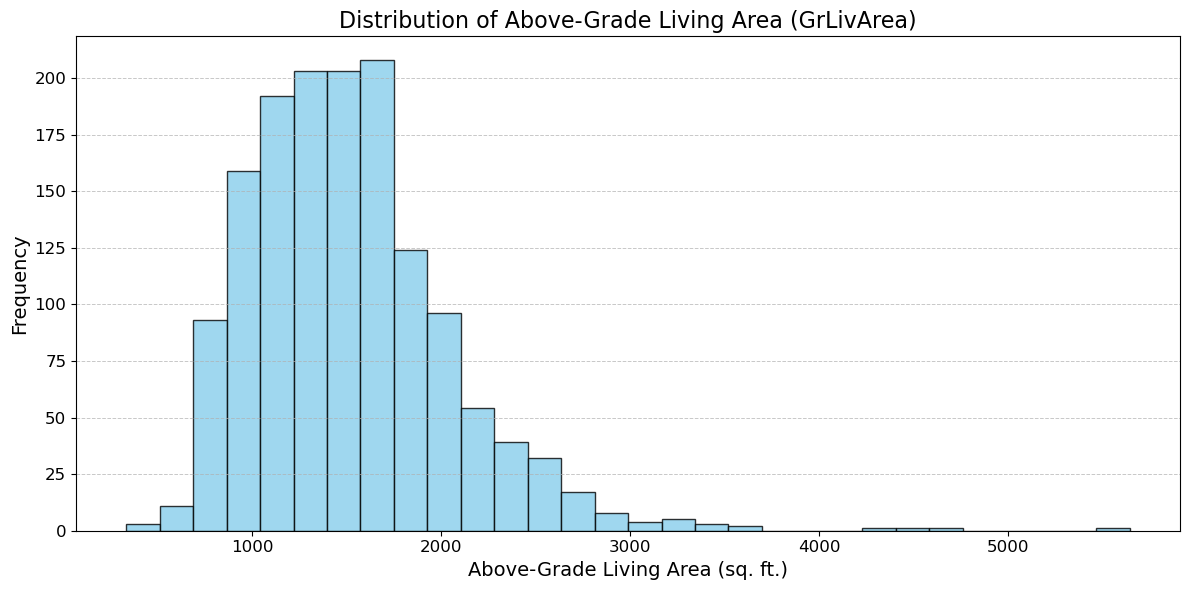

In [48]:
plt.figure(figsize=(12, 6))
plt.hist(data['GrLivArea'], bins=30, color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Above-Grade Living Area (GrLivArea)', fontsize=16)
plt.xlabel('Above-Grade Living Area (sq. ft.)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()

**Distribution of Above-Grade Living Area (`GrLivArea`)**

**Key Observations:**
1. **General Shape**:
   - The histogram shows a **right-skewed distribution**, with most homes having a living area between **1,000 and 2,000 square feet**.
   - There is a steep decline in frequency for homes with larger living areas.

2. **Peak Frequency**:
   - The highest frequency occurs within the **1,500–2,000 square feet** range, indicating the majority of properties fall into this size category.

3. **Outliers**:
   - A small number of properties have **above 3,500 square feet** of living area, which could be classified as outliers.

4. **Insights**:
   - This distribution suggests that most homes are of moderate size, suitable for typical family living, while a few outliers indicate larger, possibly luxury properties.

**Conclusion:**
The histogram effectively captures the predominant home sizes in the dataset and highlights the presence of outliers that may require further analysis.

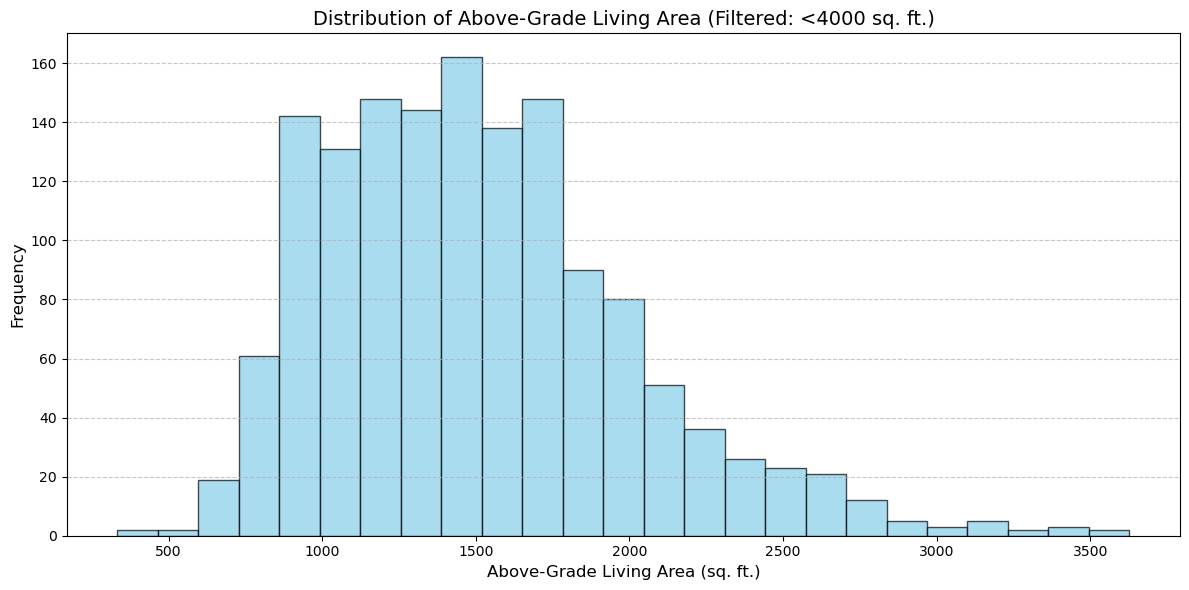

In [49]:
plt.figure(figsize=(12, 6))
plt.hist(data.loc[data['GrLivArea'] < 4000, 'GrLivArea'], bins=25, edgecolor='black', alpha=0.7, color='skyblue')

plt.xlabel('Above-Grade Living Area (sq. ft.)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Above-Grade Living Area (Filtered: <4000 sq. ft.)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

**Distribution of Above-Grade Living Area (Filtered: <4000 sq. ft.)**

**Observations:**

1. **Distribution Shape**:
   - The histogram shows a roughly bell-shaped, slightly right-skewed distribution.
   - Most homes fall within a common range of above-grade living areas, with fewer homes having very large living areas.

2. **Frequent Size Range**:
   - The majority of properties have an above-grade living area between **1,000 and 2,000 square feet**, peaking around **1,500 square feet**.
   - This indicates that average family-sized homes dominate the dataset.

3. **Outliers and Filtering**:
   - By excluding homes with living areas greater than 4,000 square feet, the histogram provides a focused view of the typical property sizes without distortion from outliers.

4. **Tail Behavior**:
   - Homes with living areas above 2,500 square feet become progressively less common, highlighting the rarity of larger homes.

5. **Bins and Granularity**:
   - The use of 25 bins ensures sufficient granularity to capture the distribution trends without over-clustering, making the data clear and interpretable.

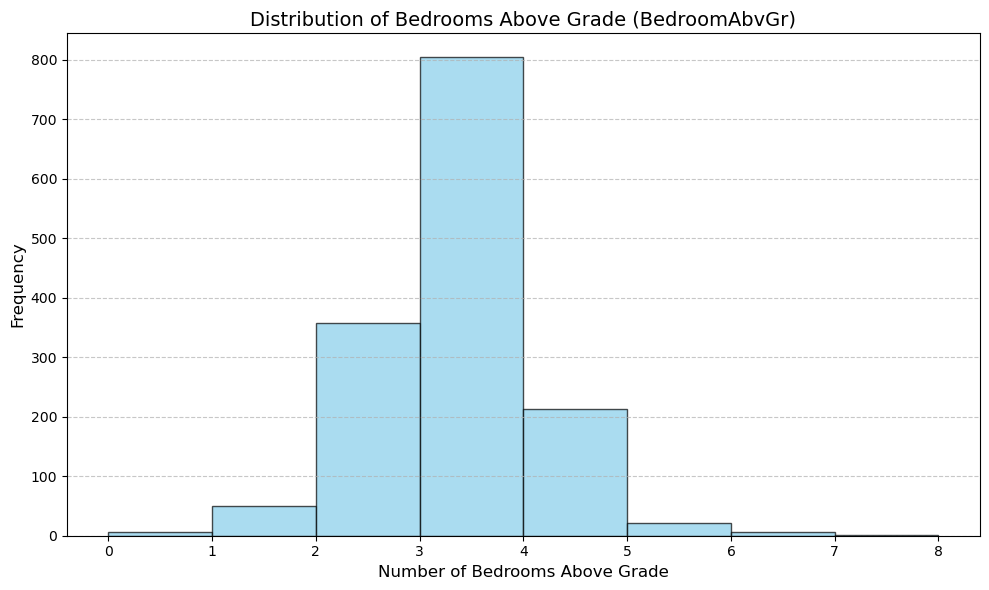

In [50]:
plt.figure(figsize=(10, 6))
plt.hist(data['BedroomAbvGr'], bins=range(0, data['BedroomAbvGr'].max() + 1), edgecolor='black', color='skyblue', alpha=0.7)

plt.xlabel('Number of Bedrooms Above Grade', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Bedrooms Above Grade (BedroomAbvGr)', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, data['BedroomAbvGr'].max() + 1), fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

**Analysis of the Distribution of Bedrooms Above Grade (BedroomAbvGr)**

**Observations:**
1. **Mode (Most Common Number of Bedrooms)**:
   - The most frequent number of bedrooms above grade is **3**, with a significantly high count of properties.
2. **Distribution Shape**:
   - The distribution is highly **right-skewed**, with a concentration of properties having 2 to 4 bedrooms above grade.
   - Bedrooms above 5 are rare, with only a few properties featuring such high counts.
3. **Uncommon Values**:
   - Properties with 0, 1, or more than 5 bedrooms above grade are uncommon, showing specialized use or unique designs for those houses.

**Insights:**
- The majority of properties align with typical residential configurations, offering **3 or fewer bedrooms** above grade, which suits the needs of most households.
- Homes with 5 or more bedrooms are likely targeted toward larger families or high-end markets.
- The rare occurrence of houses with no bedrooms above grade may indicate a specific architectural choice or incomplete data for certain entries.

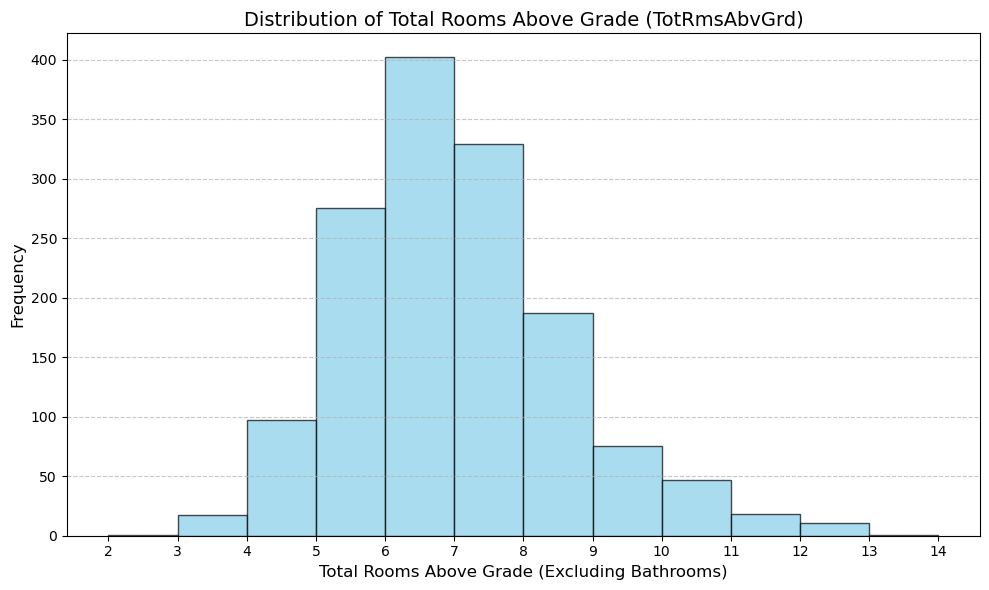

In [51]:
plt.figure(figsize=(10, 6))
plt.hist(data['TotRmsAbvGrd'], bins=range(2, 15), color='skyblue', edgecolor='black', alpha=0.7)

plt.xlabel('Total Rooms Above Grade (Excluding Bathrooms)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Total Rooms Above Grade (TotRmsAbvGrd)', fontsize=14)

plt.xticks(range(2, 15))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Distribution of Total Rooms Above Grade (TotRmsAbvGrd)**

**Key Observations:**
1. **Central Tendency**: 
   - The distribution peaks at around **6-7 rooms**, indicating the majority of houses have this number of rooms above grade (excluding bathrooms).

2. **Spread**: 
   - The range of total rooms spans from **2 to 14 rooms**, with most houses clustered between **4 and 8 rooms**.

3. **Skewness**: 
   - There is slight positive skewness, as some houses with **11-14 rooms** extend the distribution's tail.

4. **Insights**:
   - The majority of homes in the dataset appear to be standard-sized family homes.
   - Houses with **11 or more rooms** are likely outliers representing large or luxury properties.

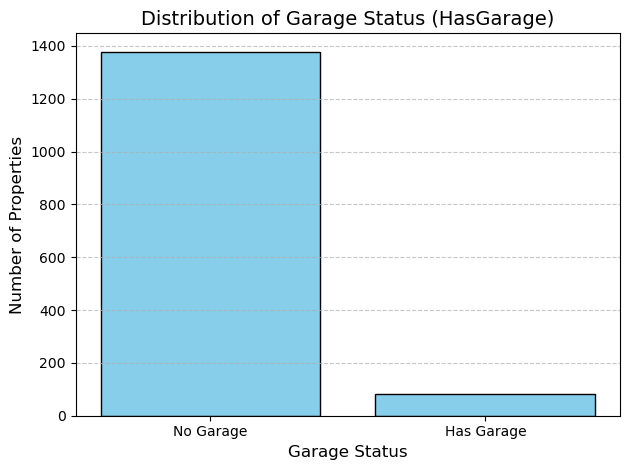

In [52]:
plt.bar(
    ['No Garage', 'Has Garage'],
    [data['HasGarage'].value_counts().iloc[0], data['HasGarage'].value_counts().iloc[1]],
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Garage Status', fontsize=12)
plt.ylabel('Number of Properties', fontsize=12)
plt.title('Distribution of Garage Status (HasGarage)', fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Comments on the Histogram: Distribution of Garage Status (HasGarage)**

- **Major Insight**: The majority of properties **do not have a garage**, as shown by the significantly larger bar for "No Garage." This indicates that garages are not a standard feature for most properties in the dataset.
- **Minor Insight**: A smaller proportion of properties have a garage. This is indicated by the relatively small bar for "Has Garage."
- **Impact on Analysis**: This distribution highlights the importance of carefully considering the presence of a garage when analyzing property values or other features, as it is not a common feature in the dataset.

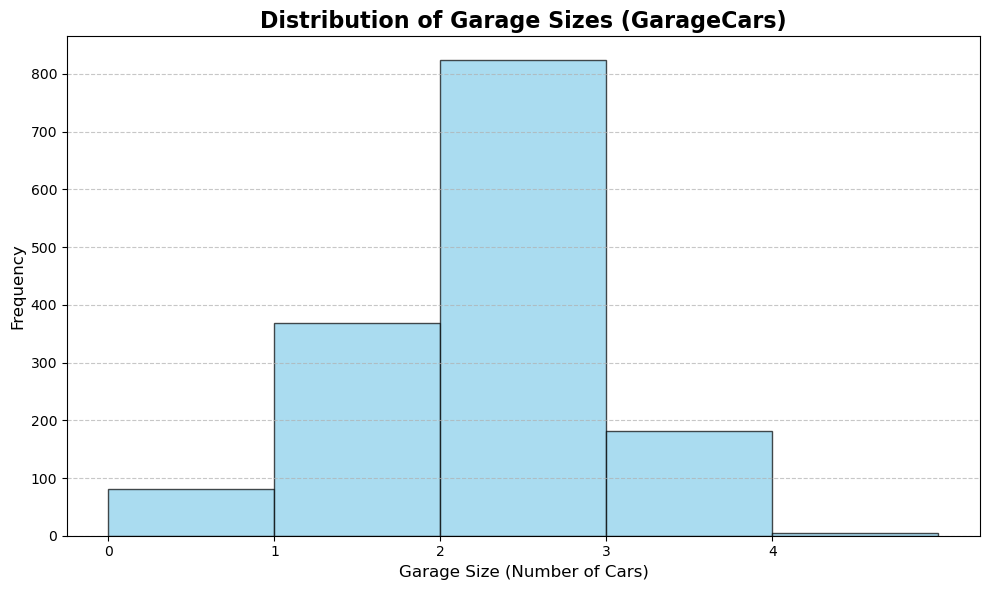

In [53]:
plt.figure(figsize=(10, 6))
plt.hist(data['GarageCars'], bins=range(int(data['GarageCars'].min()), int(data['GarageCars'].max()) + 2), color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Garage Sizes (GarageCars)', fontsize=16, fontweight='bold')
plt.xlabel('Garage Size (Number of Cars)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(range(int(data['GarageCars'].min()), int(data['GarageCars'].max()) + 1), fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Comments on the Histogram: Distribution of Garage Sizes (GarageCars)**

1. **Dominance of 2-Car Garages**:
   - The most frequent garage size is for 2 cars, with over 800 properties in this category.
   - This indicates that two-car garages are a standard or preferred size in the dataset's housing market.

2. **Other Garage Sizes**:
   - Single-car garages and 3-car garages are also common, though significantly fewer than 2-car garages.
   - Garages for 4 cars or more are rare, making them outliers.

3. **No Garage**:
   - A small but noticeable proportion of houses lack a garage (0 cars), suggesting variations in property types or urban planning preferences.

4. **Symmetry and Spread**:
   - The data shows a right-skewed distribution, emphasizing the popularity of mid-sized garages (1–3 cars).
   - Larger garages (4+ cars) have a negligible frequency.

This histogram effectively conveys the distribution of garage sizes, showcasing the predominance of 2-car garages.

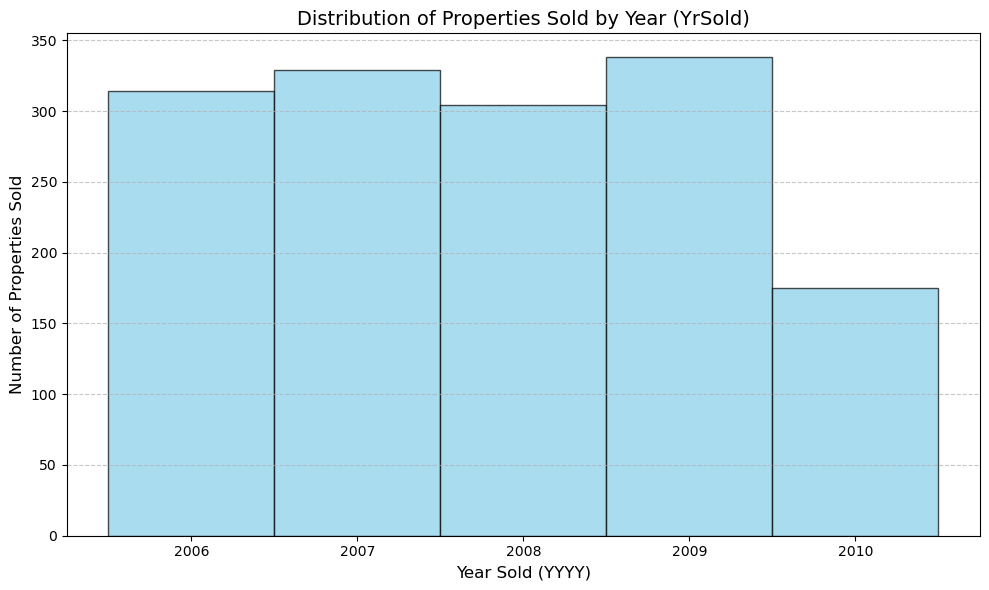

In [54]:
bins = range(data['YrSold'].min(), data['YrSold'].max() + 2)
bin_centers = [(bins[i] + bins[i + 1]) / 2 for i in range(len(bins) - 1)]

plt.figure(figsize=(10, 6))
hist_values, _, _ = plt.hist(data['YrSold'], bins=bins, edgecolor='black', color='skyblue', alpha=0.7)

plt.xlabel('Year Sold (YYYY)', fontsize=12)
plt.ylabel('Number of Properties Sold', fontsize=12)
plt.title('Distribution of Properties Sold by Year (YrSold)', fontsize=14)

plt.xticks(bin_centers, [int(center) for center in bin_centers])

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Distribution of Properties Sold by Year (YrSold)**

**General Trend**
- The number of properties sold per year from 2006 to 2010 is relatively consistent, with a small dip in 2010.
- The peak years for property sales are 2007 and 2009, with over 350 properties sold in each year.

**Insights**
- The dip in 2010 could indicate market conditions or other external factors influencing property sales during that period.
- The histogram reveals no drastic changes in property sales between 2006 and 2009, suggesting a stable market.

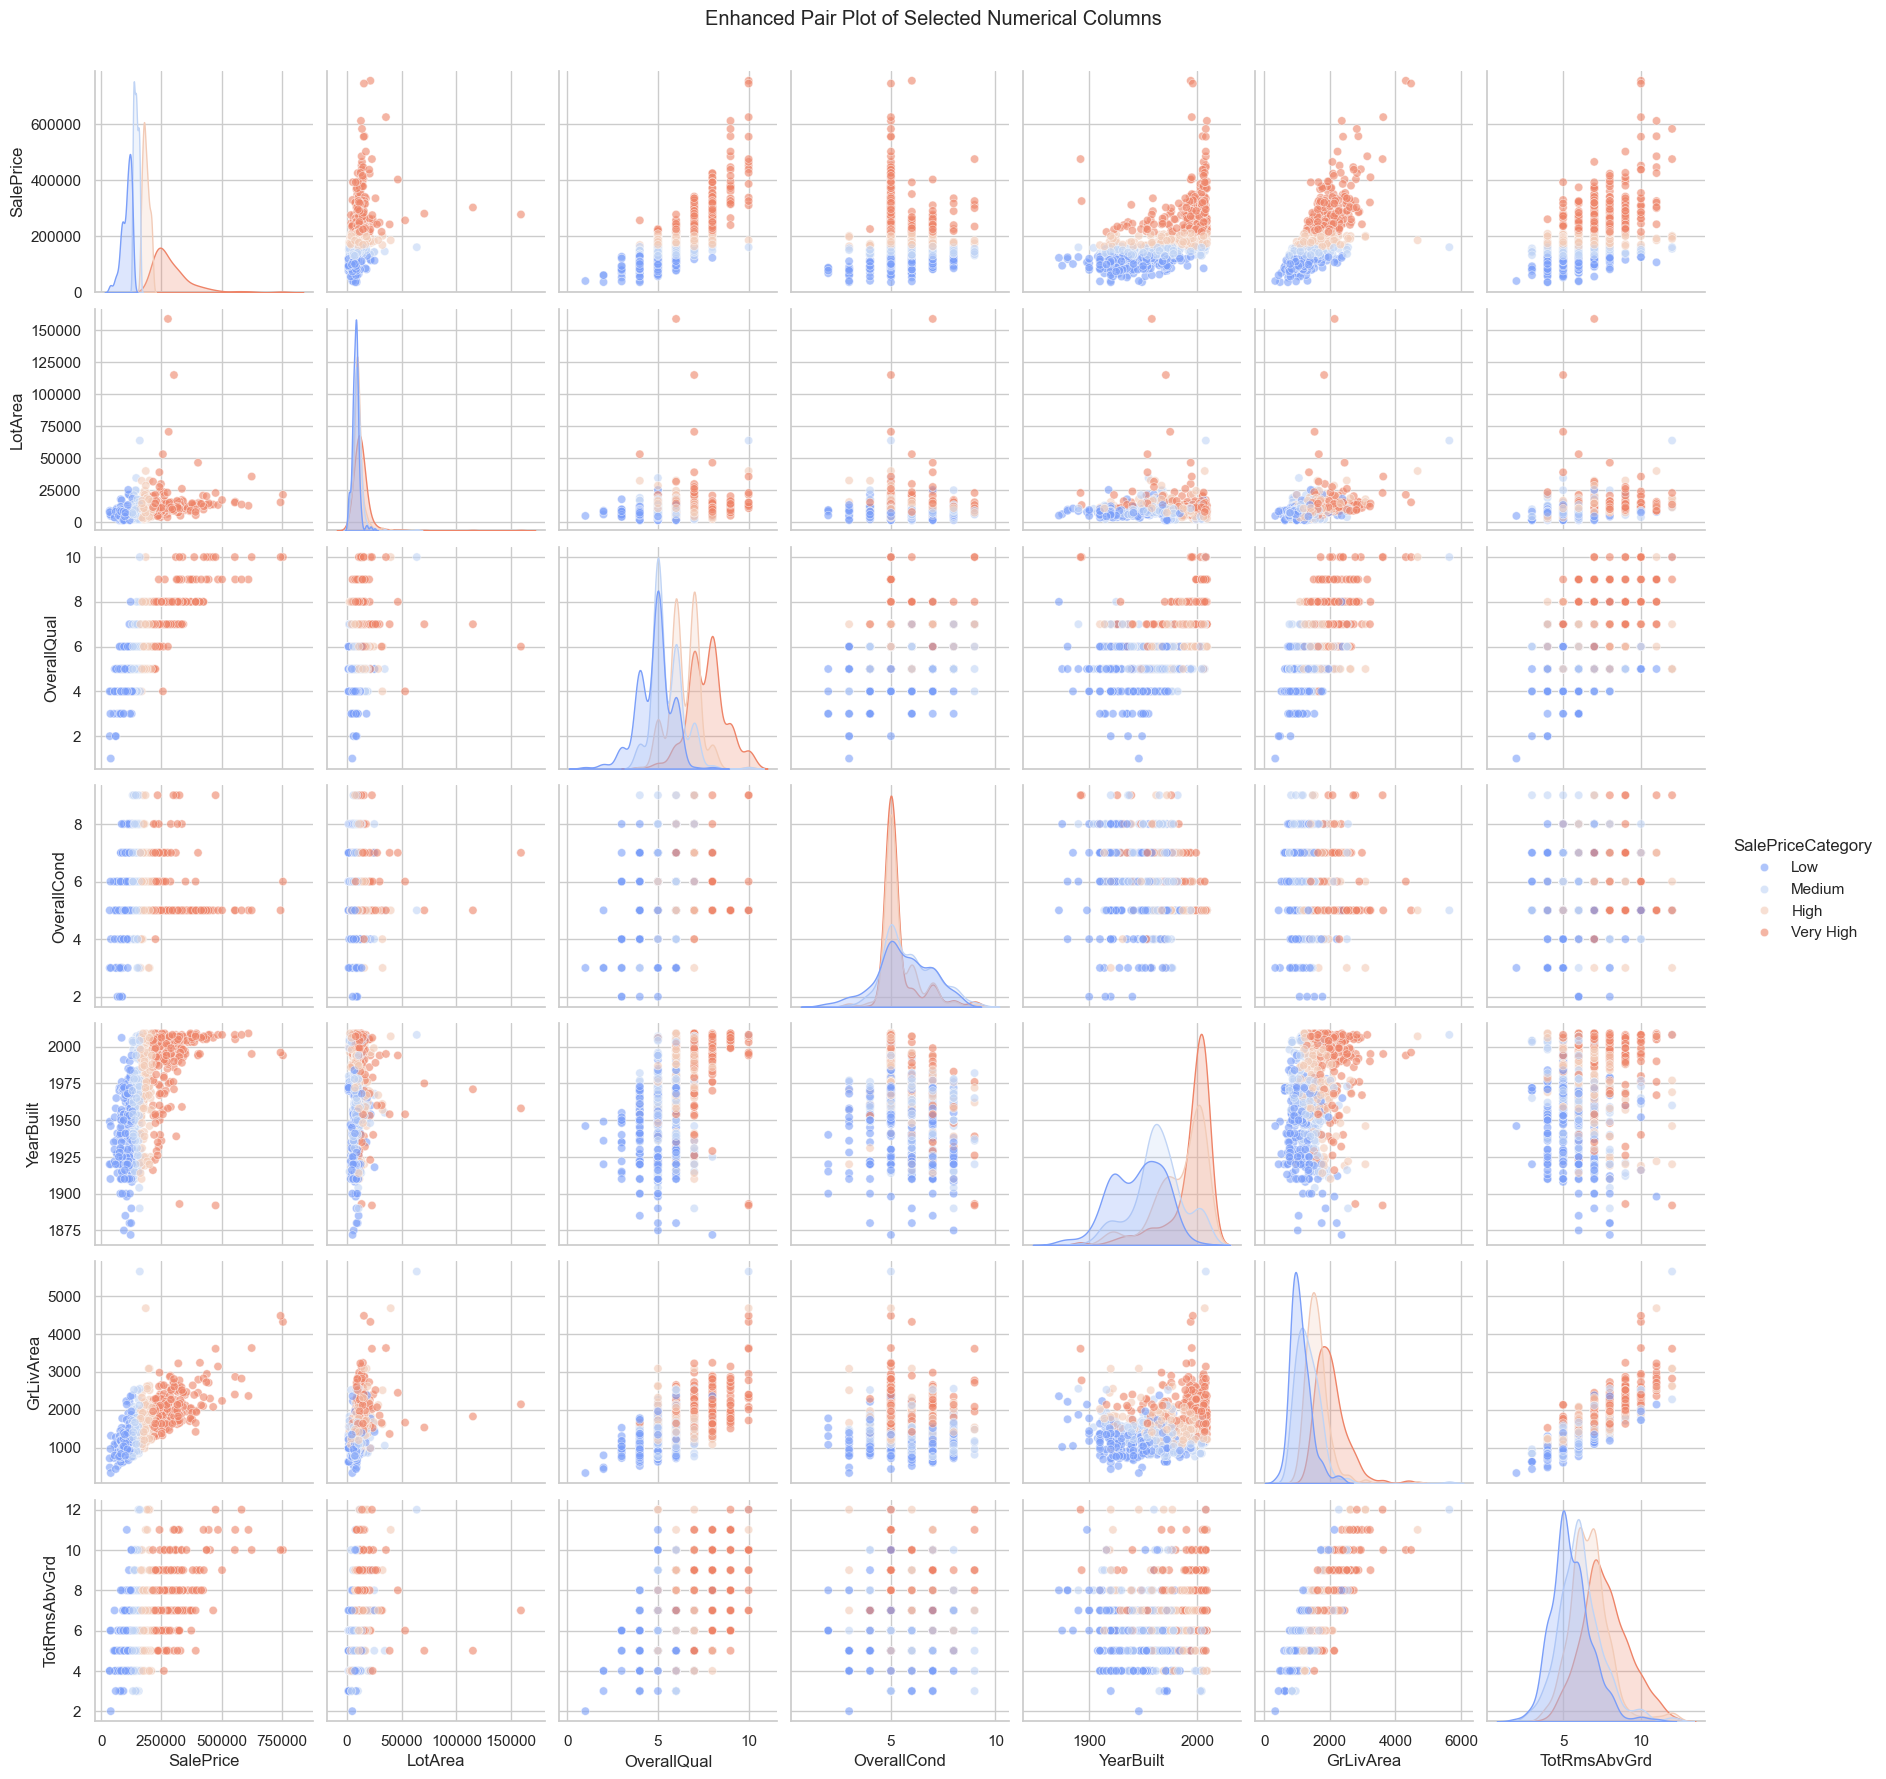

In [55]:
columns = [
    'SalePrice', 'MSSubClass', 'LotArea', 'OverallQual', 
    'OverallCond', 'YearBuilt', 'GrLivArea', 'TotRmsAbvGrd'
]

subset = data[columns].copy()

subset_sampled = subset.sample(n=1000, random_state=42)  # Take a random sample of 1000 rows

subset_sampled['SalePriceCategory'] = pd.qcut(
    subset_sampled['SalePrice'], q=4, labels=['Low', 'Medium', 'High', 'Very High']
)

sns.set_theme(style='whitegrid')
pair_plot = sns.pairplot(
    subset_sampled,
    hue='SalePriceCategory',
    diag_kind='kde',
    plot_kws={'alpha': 0.6},
    palette='coolwarm'
)

pair_plot.fig.suptitle('Enhanced Pair Plot of Selected Numerical Columns', y=1.02)
plt.show()

**Observations from the Enhanced Pair Plot**

**SalePrice vs Other Variables**
- **GrLivArea:** Strong positive correlation; larger above-grade living areas are associated with higher sale prices.
- **OverallQual:** SalePrice increases significantly with higher overall quality ratings, showing a clear trend.
- **YearBuilt:** Newer houses tend to have higher SalePrice, with a slight clustering effect for very high prices.
- **TotRmsAbvGrd:** More total rooms above grade correspond to higher prices, though the relationship is weaker compared to GrLivArea or OverallQual.
- **LotArea:** Positive relationship, but weak and scattered correlation.

**GrLivArea and TotRmsAbvGrd**
- Positive correlation between above-grade living area (GrLivArea) and total number of rooms (TotRmsAbvGrd); larger homes tend to have more rooms.

**OverallQual and OverallCond**
- Minimal correlation between overall quality (OverallQual) and condition (OverallCond), likely due to measuring distinct aspects.

**YearBuilt and GrLivArea**
- Newer homes tend to have larger above-grade living areas, with older homes being generally smaller.

**Categorization by SalePrice**
- **Higher SalePrice Categories:** Concentrated toward higher GrLivArea, OverallQual, and YearBuilt.
- **Lower SalePrice Categories:** Spread out, occupying lower ranges of most variables.

**Diagonal KDE Plots**
- **SalePrice:** Right-skewed, indicating a few high-priced properties.
- **GrLivArea and LotArea:** Long tails suggest some outlier properties with significantly larger areas.

**Insights**
- **Key Drivers of SalePrice:** GrLivArea, OverallQual, and YearBuilt are primary predictors.
- **Room for Improvement:** Addressing outliers and transforming skewed variables (e.g., SalePrice) might refine models.
- **Category Segmentation:** SalePrice categories (Low, Medium, High, Very High) highlight clear patterns across different ranges.

**Modeling Plan**

**Objectives:**
1. Predict house prices (SalePrice) with maximum accuracy.
2. We have a test dataset. We'll create a prediction model with maximum accuracy.
3. We'll use this model to predict house prices in test dataset.

**Steps to follow:**
1. Dummify categorical features.
2. Apply **log transformation** to right skewed numerical variables.
3. Apply normalization.
4. Prepare models with basic models like **Linear Regression**, **Decision Tree Regressor**.
5. Evaluate results with MAE (Mean Absolute Erro), MSE (Mean Squared Error), RMSE (Root Mean Squared Error) and R² (R-squared).
6. Explore **feaure importance** to understand which features contribute most to predictions. We can remove features which contribute less.
7. Continue with **Random Forest Regressor**.
8. Continue with intermediate models like **Ridge and Lasso Regression**, **Gradient Boosting Machines (XGBoost and LighGBM)**.
9. Apply cross-validation and **hyperparameter tuning** (Grid search and Random search).
10. Finalize the model: Train the **best performing model** on the <u>entire train dataset</u>.

**Steps to do for test dataset:**
1. Apply same data **cleaning and transformation techniques** applied to train set. For this step preprocess_data function is prepared. If any data manipulation performed, add these in that function.
2. **Make predictions** with best performing prediction model for test dataset.
3. **Export prediction results** in csv format.

Prepare summarisation of findings, insights and evaluate model performance.

Prepare visualizations of **feature importance**, model preformance and **distribution of predictions**.

In [56]:
def preprocess_data(df):
    """Preprocess the dataset by applying feature engineering, missing value handling, and type conversions."""
    
    # Drop 'LotFrontage' column
    df = df.drop(columns=['LotFrontage'], errors='ignore')
    
    # Fill missing values for categorical columns
    df['Alley'] = df['Alley'].fillna('NoAlley')
    df['FireplaceQu'] = df['FireplaceQu'].fillna('NF')
    df['GarageType'] = df['GarageType'].fillna('NoGar')
    df['GarageFinish'] = df['GarageFinish'].fillna('NoG')
    df[['GarageQual', 'GarageCond']] = df[['GarageQual', 'GarageCond']].fillna('NG')
    df['PoolQC'] = df['PoolQC'].fillna('NP')
    df['Fence'] = df['Fence'].fillna('NoFen')
    df['MiscFeature'] = df['MiscFeature'].fillna('None')
    
    # Fill missing basement-related columns
    basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
    df[basement_cols] = df[basement_cols].fillna('NB')

    # Create 'Remodeled' feature (True if house was remodeled)
    df['Remodeled'] = df['YearBuilt'] != df['YearRemodAdd']

    # Place 'Remodeled' before 'YearRemodAdd'
    columns = list(df.columns)
    remod_index = columns.index('YearRemodAdd')
    columns.insert(remod_index, columns.pop(columns.index('Remodeled')))
    df = df[columns]

    # Set 'YearRemodAdd' to 0 if it matches 'YearBuilt'
    df.loc[df['YearRemodAdd'] == df['YearBuilt'], 'YearRemodAdd'] = 0

    # Handling missing 'MasVnrType' and 'MasVnrArea'
    df.loc[(df['MasVnrArea'] == 0) & (df['MasVnrType'].isna()), 'MasVnrType'] = 'NoVnr'
    df.loc[df['MasVnrArea'].isna(), 'MasVnrType'] = 'NoVnr'
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

    # Fill missing 'MasVnrType' with most frequent value in 'Neighborhood' (excluding 'NoVnr')
    most_frequent_masvnrtype = (
        df[df['MasVnrType'] != 'NoVnr']
        .groupby('Neighborhood')['MasVnrType']
        .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    )
    df['MasVnrType'] = df.apply(lambda row: most_frequent_masvnrtype.get(row['Neighborhood'], row['MasVnrType'])
                                    if pd.isna(row['MasVnrType']) else row['MasVnrType'], axis=1)

    # Fill missing 'Electrical' with most frequent value in 'Neighborhood'
    most_frequent_electrical = (
        df.groupby('Neighborhood')['Electrical']
        .apply(lambda x: x.mode()[0] if not x.mode().empty else None)
    )
    df['Electrical'] = df.apply(lambda row: most_frequent_electrical[row['Neighborhood']]
                                    if pd.isna(row['Electrical']) else row['Electrical'], axis=1)

    # Create 'HasGarage' feature (True if garage exists)
    df['HasGarage'] = df['GarageType'] != 'NoGar'

    # Place 'HasGarage' before 'GarageType'
    columns = list(df.columns)
    garage_type_index = columns.index('GarageType')
    columns.insert(garage_type_index, columns.pop(columns.index('HasGarage')))
    df = df[columns]

    # Fill missing 'GarageYrBlt' with 0
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

    # If 'Condition1' == 'Condition2', set 'Condition2' to 'None'
    df.loc[df['Condition1'] == df['Condition2'], 'Condition2'] = 'None'

    # Convert 'MSSubClass' to string
    df['MSSubClass'] = df['MSSubClass'].astype('str')
    
    # Convert 'Y' to True, 'N' to False and set data type to boolean
    df['CentralAir'] = df['CentralAir'].map({'Y': True, 'N': False}).astype(bool)

    # Convert selected columns to float64
    float_columns = [
        'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 
        'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'
    ]
    df[float_columns] = df[float_columns].astype('float64')

    # Convert selected columns to int64
    int_columns = [
        'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFullBath', 'BsmtHalfBath',
        'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
        'GarageYrBlt', 'GarageCars', 'MoSold', 'YrSold'
    ]
    df[int_columns] = df[int_columns].astype('int64')

    return df

In [57]:
# data = preprocess_data(data)

In [58]:
def dummify(df):
    """
    Converts categorical columns into dummy variables, ensuring all possible categories exist,
    while maintaining the original column order. Missing categories are set to False (boolean).

    Parameters:
    df (pd.DataFrame): The input DataFrame.

    Returns:
    pd.DataFrame: The DataFrame with dummified categorical columns in the same position as the original columns.
    """
    # Define the possible categories (static, predefined)
    possible_categories = {
        'MSSubClass': ['20', '30', '40', '45', '50', '60', '70', '75', '80', '85', '90', '120', '150', '160', '180', '190'],
        'MSZoning': ['A', 'C (all)', 'FV', 'I', 'RH', 'RL', 'RP', 'RM'],
        'Street': ['Grvl', 'Pave'],
        'Alley': ['Grvl', 'Pave', 'NoAlley'],
        'LotShape': ['Reg', 'IR1', 'IR2', 'IR3'],
        'LandContour': ['Lvl', 'Bnk', 'HLS', 'Low'],
        'Utilities': ['AllPub', 'NoSewr', 'NoSeWa', 'ELO'],
        'LotConfig': ['Inside', 'Corner', 'CulDSac', 'FR2', 'FR3'],
        'LandSlope': ['Gtl', 'Mod', 'Sev'],
        'Neighborhood': ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NoRidge', 'NPlVill', 'NridgHt', 'NWAmes', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber', 'Veenker'],
        'Condition1': ['Artery', 'Feedr', 'Norm', 'RRNn', 'RRAn', 'PosN', 'PosA', 'RRNe', 'RRAe'],
        'Condition2': ['Artery', 'Feedr', 'Norm', 'RRNn', 'RRAn', 'PosN', 'PosA', 'RRNe', 'RRAe', 'None'],
        'BldgType': ['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs'],
        'HouseStyle': ['1Story', '1.5Fin', '1.5Unf', '2Story', '2.5Fin', '2.5Unf', 'SFoyer', 'SLvl'],
        'RoofStyle': ['Flat', 'Gable', 'Gambrel', 'Hip', 'Mansard', 'Shed'],
        'RoofMatl': ['ClyTile', 'CompShg', 'Membran', 'Metal', 'Roll', 'Tar&Grv', 'WdShake', 'WdShngl'],
        'Exterior1st': ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing'],
        'Exterior2nd': ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing'],
        'MasVnrType': ['BrkCmn', 'BrkFace', 'CBlock', 'NoVnr', 'Stone'],
        'ExterQual': ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
        'ExterCond': ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
        'Foundation': ['BrkTil', 'CBlock', 'PConc', 'Slab', 'Stone', 'Wood'],
        'BsmtQual': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NB'],
        'BsmtCond': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NB'],
        'BsmtExposure': ['Gd', 'Av', 'Mn', 'No', 'NB'],
        'BsmtFinType1': ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NB'],
        'BsmtFinType2': ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NB'],
        'Heating': ['Floor', 'GasA', 'GasW', 'Grav', 'OthW', 'Wall'],
        'HeatingQC': ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
        'Electrical': ['SBrkr', 'FuseA', 'FuseF', 'FuseP', 'Mix'],
        'KitchenQual': ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
        'Functional': ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal'],
        'FireplaceQu': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NF'],
        'GarageType': ['2Types', 'Attchd', 'Basment', 'BuiltIn', 'CarPort', 'Detchd', 'NoGar'],
        'GarageFinish': ['RFn', 'Unf', 'Fin', 'NoG'],
        'GarageQual': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NG'],
        'GarageCond': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NG'],
        'PavedDrive': ['Y', 'P', 'N'],
        'PoolQC': ['Ex', 'Gd', 'TA', 'Fa', 'NP'],
        'Fence': ['GdPrv', 'MnPrv', 'GdWo', 'MnWw', 'NoFen'],
        'MiscFeature': ['Elev', 'Gar2', 'Othr', 'Shed', 'TenC', 'None'],
        'SaleType': ['WD', 'CWD', 'VWD', 'New', 'COD', 'Con', 'ConLw', 'ConLI', 'ConLD', 'Oth'],
        'SaleCondition': ['Normal', 'Abnorml', 'AdjLand', 'Alloca', 'Family', 'Partial']
    }

    df = df.copy()  # Work on a copy to avoid modifying the original DataFrame
    original_columns = list(df.columns)  # Store original column order
    new_columns = []  # To track the final column order

    for col in original_columns:
        if col in possible_categories:
            # Create dummy variables while keeping column order
            dummies = pd.get_dummies(df[col], prefix=col).astype(bool)  # Convert to bool

            # Ensure all expected dummy columns exist
            for category in possible_categories[col]:
                dummy_col = f"{col}_{category}"
                if dummy_col not in dummies.columns:
                    dummies[dummy_col] = False  # Add missing column as False (bool)

            # Drop original column and insert dummy columns in its position
            df.drop(columns=[col], inplace=True)
            df = pd.concat([df, dummies], axis=1)

            # Keep track of new column order
            new_columns.extend(dummies.columns)
        else:
            new_columns.append(col)  # Keep non-categorical columns in the same place

    # Reorder columns to maintain original positions
    df = df[new_columns]

    return df

In [59]:
# data = dummify(data)

In [60]:
import numpy as np
from scipy.stats import skew
from sklearn.preprocessing import MinMaxScaler

In [61]:
def transform_features_train(df):

    df = df.copy()

    # Apply Dummification
    df = dummify(df)

    # Store min and max values of target column
    target_min = df['SalePrice'].min()
    target_max = df['SalePrice'].max()
    
    # Identify numerical columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    # Normalize the numerical features
    scaler = MinMaxScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    return df, scaler, target_min, target_max  # Return transformed data, fitted scaler, min and max values of target column

In [62]:
# data, scaler, target_min, target_max = transform_features_train(data)

In [63]:
def transform_features_test(df, scaler):

    df = df.copy()

    # Apply Dummification
    df = dummify(df)

    # Identify numerical columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    # Normalize the numerical features using the fitted scaler
    df[numeric_cols] = scaler.transform(df[numeric_cols])

    return df

In [64]:
# data = transform_features_test(data, scaler)

In [65]:
def reverse_normalization_train(y_pred, y_test, target_min, target_max):

    # Reverse Min-Max Scaling manually
    y_pred_reversed = y_pred * (target_max - target_min) + target_min
    y_test_reversed = y_test * (target_max - target_min) + target_min

    return y_pred_reversed, y_test_reversed

In [66]:
# y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

In [67]:
def reverse_normalization_test(y_pred, target_min, target_max):

    # Reverse Min-Max Scaling manually
    y_pred_reversed = y_pred * (target_max - target_min) + target_min

    return y_pred_reversed

In [68]:
# y_pred_reversed = reverse_normalization_test(y_pred, target_min, target_max)

In [117]:
data = pd.read_csv(r'C:\Users\cihat\Desktop\Ubiqum\House Prices\Data\train.csv')
data = preprocess_data(data)
data, scaler, target_min, target_max = transform_features_train(data)

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [71]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate performance metrics
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print results
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 301137504436210.2500
MSE: 7773657691120652080244966031360.0000
RMSE: 2788127990448188.0000
R²: -1013471589231329411072.0000


In [72]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [73]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Linear Regression model
model = LinearRegression()

# Perform 5-fold Cross-Validation
cv_mae = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_mse = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

# Compute RMSE from MSE
cv_rmse = np.sqrt(cv_mse)

# Print Cross-Validation Metrics
print("Cross-Validation Results (5-Fold):")
print(f"Mean MAE: {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"Mean MSE: {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"Mean RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")
print(f"Mean R²: {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")

# Train model on full training set
model.fit(X_train, y_train)

# Make predictions on test set
y_pred = model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate final performance metrics on test set
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print final test set results
print("\nFinal Model Performance on Test Set:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


Cross-Validation Results (5-Fold):
Mean MAE: 632486218.3383 ± 879502642.9152
Mean MSE: 63519004086461775872.0000 ± 97779089581634502656.0000
Mean RMSE: 5160417419.7838 ± 6073639447.6503
Mean R²: -4851962077804554616832.0000 ± 6975600749919096274944.0000

Final Model Performance on Test Set:
MAE: 301137504436210.2500
MSE: 7773657691120652080244966031360.0000
RMSE: 2788127990448188.0000
R²: -1013471589231329411072.0000


In [74]:
from sklearn.tree import DecisionTreeRegressor

In [75]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate performance metrics
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print results
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 28216.0000
MSE: 2012875434.6849
RMSE: 44865.0803
R²: 0.7376


In [76]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Perform cross-validation (5-fold by default)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

# Train the model on the entire training set
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate performance metrics
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print results
print(f"Cross-Validation MAE: {-np.mean(cv_scores):.4f}")  # Cross-validation scores are negative, so we take the absolute value
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Cross-Validation MAE: 0.0373
MAE: 28216.0000
MSE: 2012875434.6849
RMSE: 44865.0803
R²: 0.7376


In [77]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Perform cross-validation (5-fold by default)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

# Train the model on the entire training set
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate performance metrics
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print results
print(f"Cross-validation R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Cross-validation R² scores: [0.72690364 0.50802644 0.72593027 0.70813766 0.70549747]
Mean R²: 0.6749
MAE: 28216.0000
MSE: 2012875434.6849
RMSE: 44865.0803
R²: 0.7376


In [78]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Perform cross-validation (5-fold by default)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Train the model on the entire training set
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate performance metrics
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print results
print(f"Cross-validation MSE: {-np.mean(cv_scores):.4f}")  # Take the negative value to get MSE
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Cross-validation MSE: 0.0037
MAE: 28216.0000
MSE: 2012875434.6849
RMSE: 44865.0803
R²: 0.7376


In [79]:
from sklearn.model_selection import GridSearchCV

In [80]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Define the hyperparameters to tune
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']  # Number of features to consider at each split
}

# Initialize GridSearchCV to perform hyperparameter tuning
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit the model with the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred = best_model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate performance metrics
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print the best hyperparameters and the performance metrics
print(f"Best hyperparameters: {best_params}")
print(f"Cross-Validation R²: {grid_search.best_score_:.4f}")  # Best score from GridSearchCV
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Best hyperparameters: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Cross-Validation R²: 0.7136
MAE: 24737.5053
MSE: 1347282284.9943
RMSE: 36705.3441
R²: 0.8244


# Model Analysis and Results

## 1. Model Overview
- **Algorithm:** Decision Tree Regressor  
- **Preprocessing:**
  - **Dummification**: Converted categorical variables into dummy variables.
  - **Normalization**: Applied Min-Max Scaling to numerical features.
- **Hyperparameter Tuning:**
  - Used **GridSearchCV** with **5-fold cross-validation**, optimizing **R² score**.
  - **Hyperparameters tuned:**
    - `max_depth`: [3, 5, 7, 10, 15, 20, None]
    - `min_samples_split`: [2, 5, 10]
    - `min_samples_leaf`: [1, 2, 4]
    - `max_features`: [None, 'sqrt', 'log2']

---

## 2. Best Model and Performance
### **Best Hyperparameters Found**

- **max_depth:** 7
- **max_features:** None
- **min_samples_leaf:** 1
- **min_samples_split:** 10

### Model Performance Metrics

| Metric | Value | Interpretation |
| --- | --- | --- |
| **Cross-Validation R²** | **0.7136** | Expected performance on unseen data |
| **Test R²** | **0.8244** | Model explains 82.44% of variance in house prices |
| **Mean Absolute Error (MAE)** | **24,737.50** | Average prediction error is ~$24,737 |
| **Mean Squared Error (MSE)** | **1.35B** | High squared error (some large deviations exist) |
| **Root Mean Squared Error (RMSE)** | **36,705.34** | Some large errors exist, model struggles with extreme values |

---

## 3. Interpretation of Results

### **A. General Model Performance**
- **The model explains 82.44% of variance in house prices (`R² = 0.8244`).**
- **Cross-validation R² (`0.7136`) is slightly lower than test R² (`0.8244`)**, which suggests the model generalizes well.
- The model has **good predictive power and does not show overfitting**.

### **B. Error Analysis**
- **MAE (~\\$24K) means predictions are off by ~\\$24,000 on average.**
- **RMSE (~\\$36K) is larger than MAE**, which suggests **some extreme prediction errors**.
- **Possible Causes of Errors:**
  - Decision Trees tend to **be sensitive to small fluctuations** in data.
  - Some **house price variations may be hard to predict using the selected features**.
  - Feature engineering might **not be capturing important interactions**.

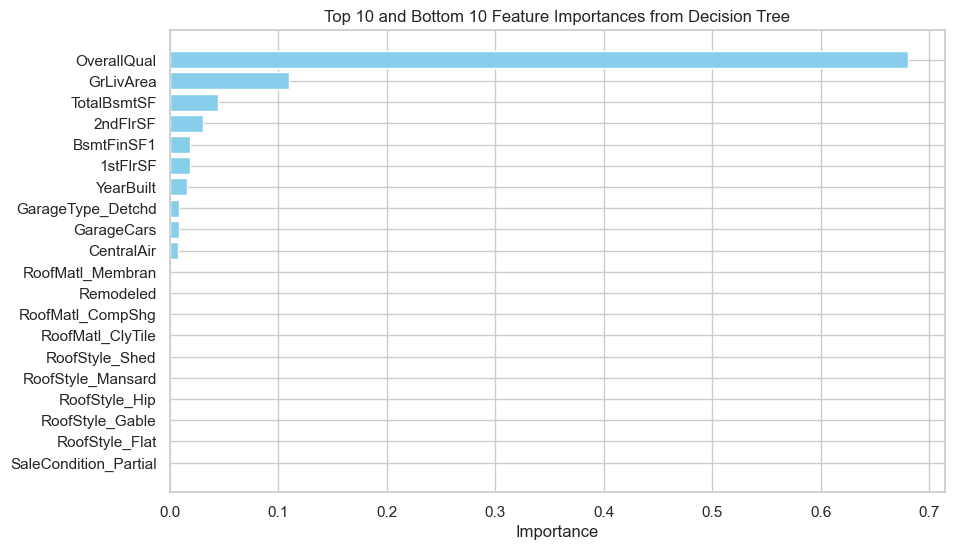

In [81]:
# Get feature importances from the best model
feature_importances = best_model.feature_importances_

# Create a DataFrame with feature names and their corresponding importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select the top 10 and bottom 10 features
top_10 = importance_df.head(10)
bottom_10 = importance_df.tail(10)

# Combine the top and bottom 10 into a single DataFrame for plotting
top_bottom_10 = pd.concat([top_10, bottom_10])

# Plot the feature importances for top 10 and bottom 10 features
plt.figure(figsize=(10, 6))
plt.barh(top_bottom_10['Feature'], top_bottom_10['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 10 and Bottom 10 Feature Importances from Decision Tree')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.show()

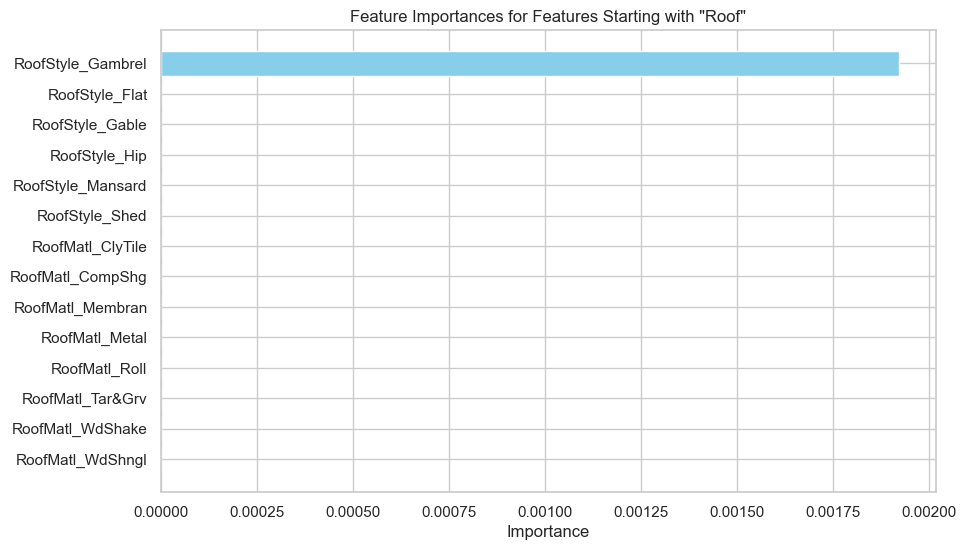

In [82]:
# Get feature importances from the best model
feature_importances = best_model.feature_importances_

# Create a DataFrame with feature names and their corresponding importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Filter features whose names start with 'Roof'
roof_features_df = importance_df[importance_df['Feature'].str.startswith('Roof')]

# Sort the DataFrame by importance in descending order
roof_features_df = roof_features_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances for features starting with 'Roof'
plt.figure(figsize=(10, 6))
plt.barh(roof_features_df['Feature'], roof_features_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importances for Features Starting with "Roof"')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.show()

Features with Importance Greater Than 0.01 (Sorted Alphabetically):
         Feature  Importance
239     1stFlrSF    0.018247
240     2ndFlrSF    0.030790
211   BsmtFinSF1    0.018358
242    GrLivArea    0.109745
109  OverallQual    0.680552
221  TotalBsmtSF    0.044210
111    YearBuilt    0.015795


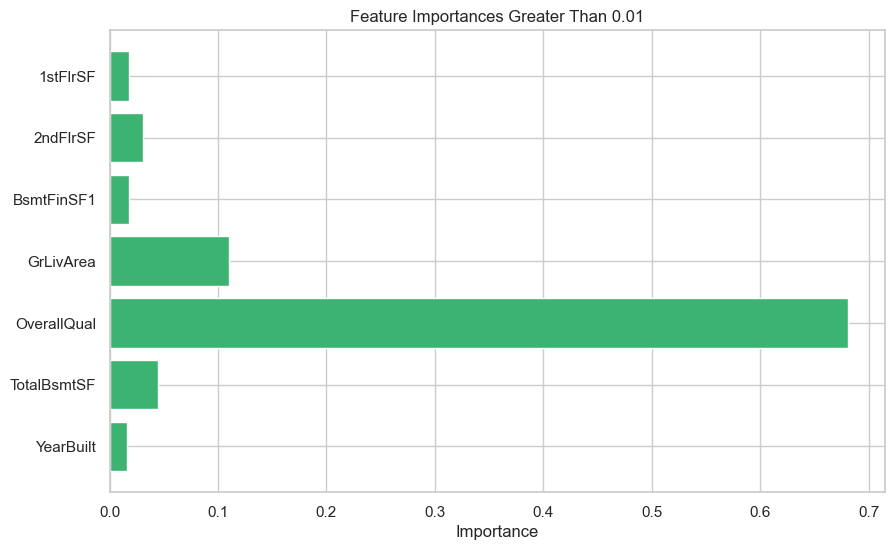

In [83]:
# Get feature importances from the best model
feature_importances = best_model.feature_importances_

# Create a DataFrame with feature names and their corresponding importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Filter features with importance greater than 0.01
high_importance_features_df = importance_df[importance_df['Importance'] > 0.01]

# Sort the DataFrame by feature names alphabetically
high_importance_features_df = high_importance_features_df.sort_values(by='Feature', ascending=True)

# Display the list of features with importance greater than 0.01, sorted alphabetically
print("Features with Importance Greater Than 0.01 (Sorted Alphabetically):")
print(high_importance_features_df[['Feature', 'Importance']])

# Plot the feature importances for features with importance greater than 0.01
plt.figure(figsize=(10, 6))
plt.barh(high_importance_features_df['Feature'], high_importance_features_df['Importance'], color='mediumseagreen')
plt.xlabel('Importance')
plt.title('Feature Importances Greater Than 0.01')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.show()

### Feature Importances Greater Than 0.01
- This chart displays the most influential features in predicting sale prices.
- **"OverallQual"** stands out as the most critical factor, which makes sense since overall material and finish quality directly impact house prices.
- **"GrLivArea"** and **"TotalBsmtSF"** are also highly relevant, confirming that total living space plays a significant role in pricing.
- Features like **"1stFlrSF"** and **"2ndFlrSF"** have lower but still notable contributions.

In [84]:
import seaborn as sns

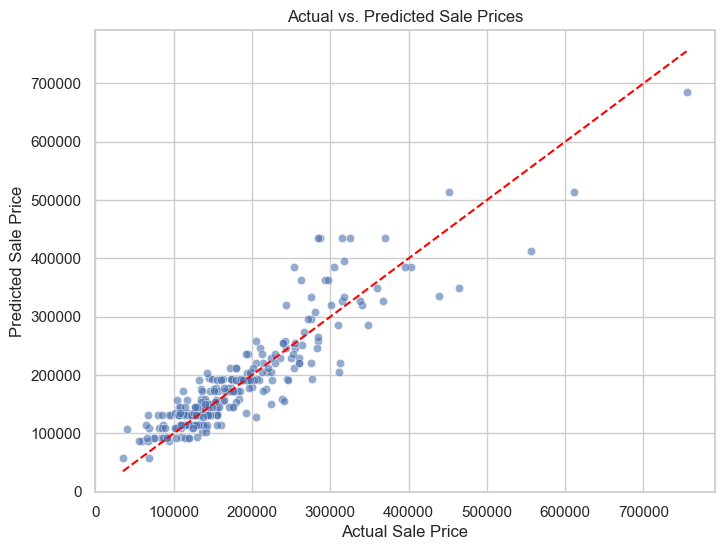

In [85]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reversed, y=y_pred_reversed, alpha=0.6)
plt.plot([y_test_reversed.min(), y_test_reversed.max()], [y_test_reversed.min(), y_test_reversed.max()], color='red', linestyle='--')  # Ideal line
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs. Predicted Sale Prices")
plt.show()

### Actual vs. Predicted Sale Prices
- The scatter plot shows how well predictions align with actual values.
- The red dashed line represents a **perfect prediction** scenario.
- Most points are clustered along this line, indicating that the model performs **reasonably well**.
- However, there are **outliers** where the model significantly underpredicts or overpredicts, which may need further investigation.

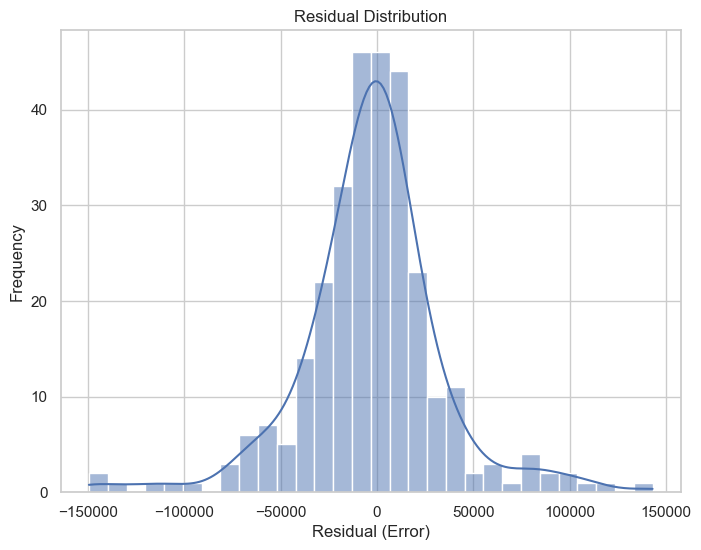

In [86]:
residuals = y_test_reversed - y_pred_reversed

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residual (Error)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Residual Distribution
- Residuals (errors) appear to follow a **roughly normal distribution** centered around zero, which is a good sign.
- There are some **extreme values**, suggesting that a few predictions deviate significantly from actual sale prices.
- If the distribution were **skewed**, it could indicate systematic bias in predictions.

In [87]:
from sklearn.model_selection import learning_curve

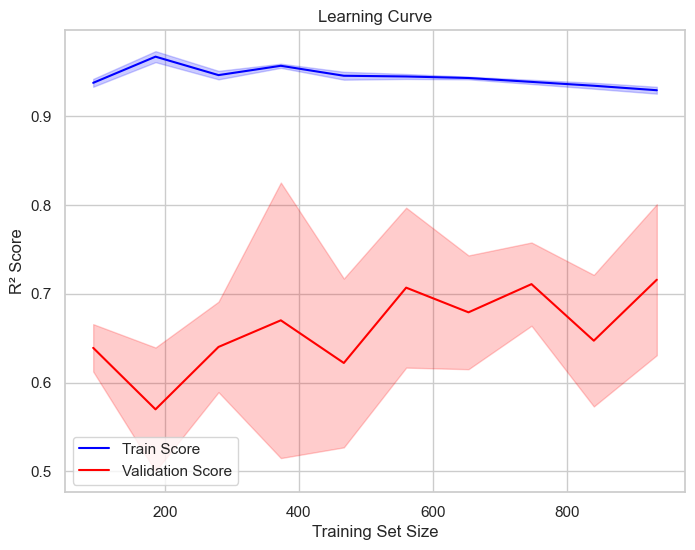

In [88]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring="r2", train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Compute mean and standard deviation of train/test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Train Score", color="blue")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="red")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="red")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

### Learning Curve
- The **training score** is consistently high, while the **validation score** is significantly lower but improving.
- The **gap between training and validation scores** suggests that the model may be **overfitting**.
- The variance in validation performance (shaded red region) shows **instability**, indicating that the model might not generalize well to unseen data.

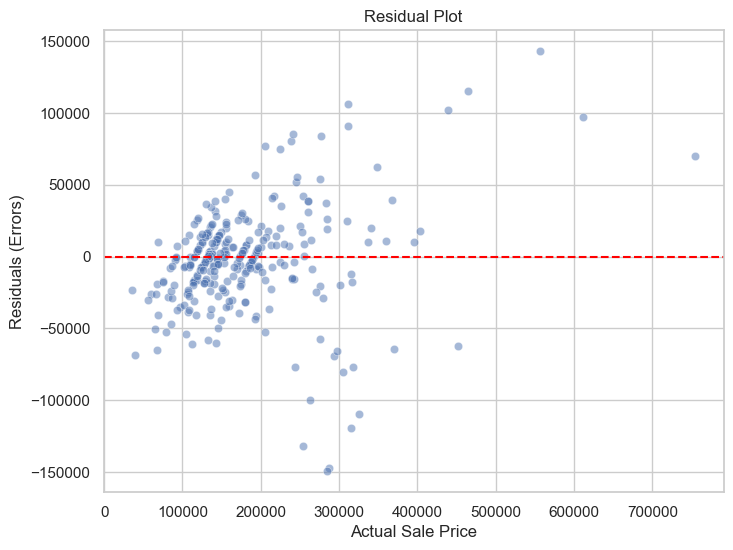

In [89]:
residuals = y_test_reversed - y_pred_reversed

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reversed, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Actual Sale Price")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot")
plt.show()

### Residual Plot
- The residuals do not seem to be **randomly distributed**, with a pattern visible, especially for higher values.
- Some points are farther from the **zero line**, suggesting the model struggles with extreme values.
- Ideally, residuals should be **evenly distributed** without a pattern to confirm that the model is unbiased.

In [90]:
from sklearn.inspection import PartialDependenceDisplay

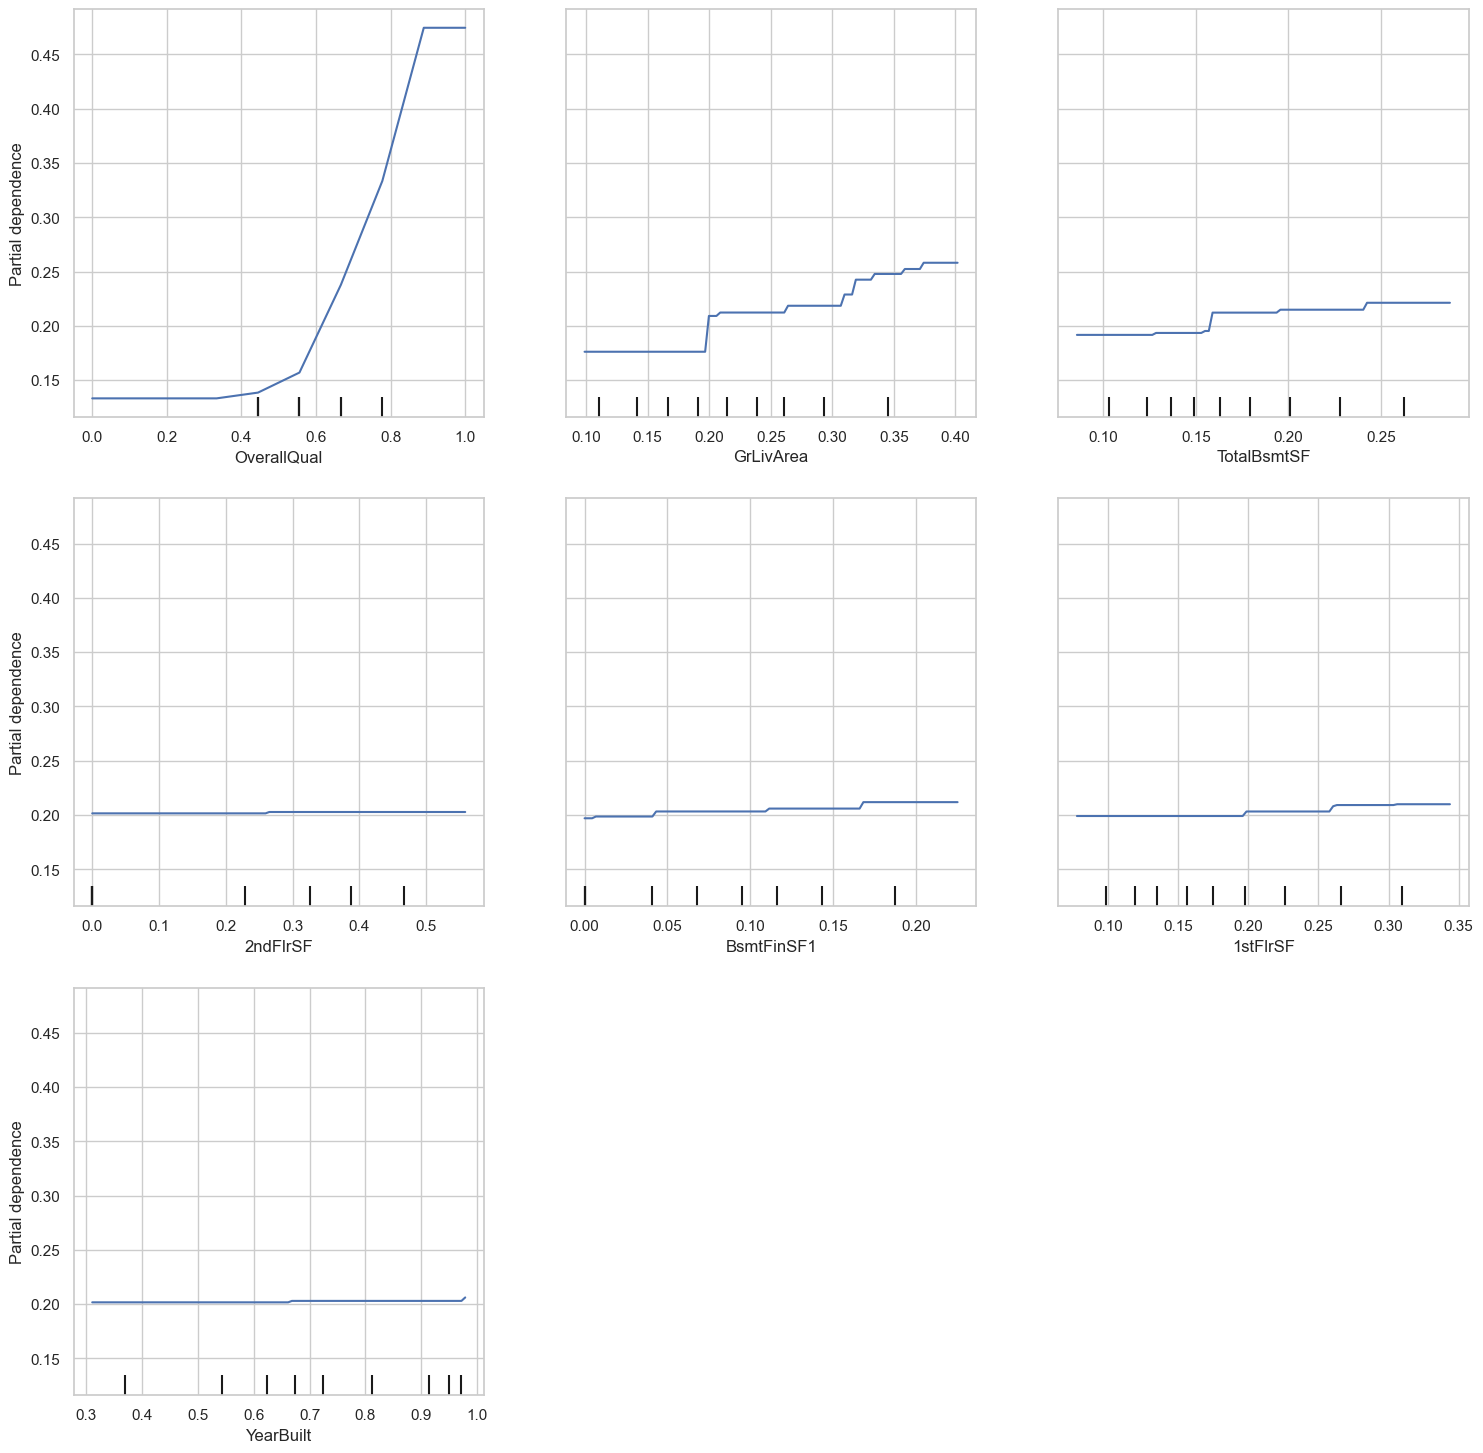

In [91]:
features_to_plot = ["OverallQual", "GrLivArea", "TotalBsmtSF", "2ndFlrSF", "BsmtFinSF1", "1stFlrSF", "YearBuilt"]  # Pick important features
fig, ax = plt.subplots(figsize=(18, 18))
PartialDependenceDisplay.from_estimator(best_model, X_train, features=features_to_plot, ax=ax)
plt.show()

### Partial Dependence Plots
- These plots show how each feature impacts the predicted sale price.
- **"OverallQual"** has a clear **positive relationship**, meaning better quality significantly increases price.
- Other features like **"GrLivArea"** and **"TotalBsmtSF"** show smaller but steady positive trends.
- Features such as **"YearBuilt"** and **"2ndFlrSF"** exhibit minor influences, implying that they contribute but not as strongly as others.

In [92]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

In [93]:
# Standardize the feature set (excluding target variable)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

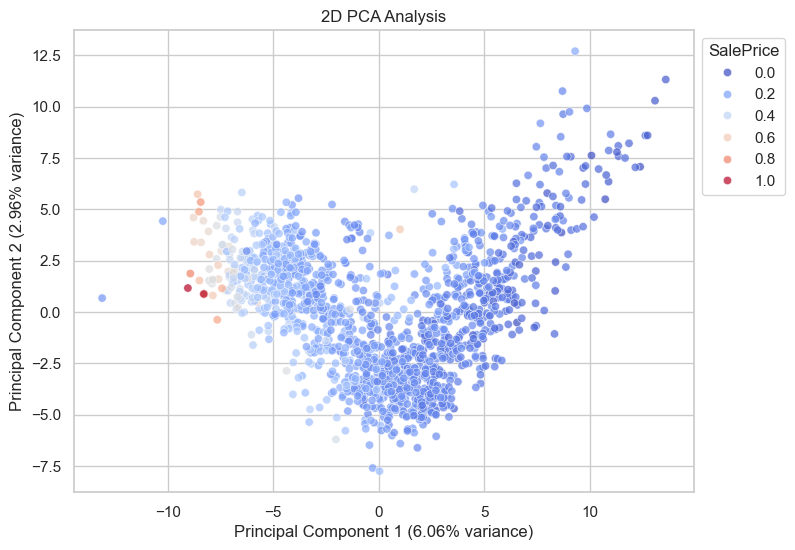

In [94]:
# Perform PCA to reduce dimensions to 2
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Convert PCA results into a DataFrame
pca_df_2d = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
pca_df_2d["SalePrice"] = y  # Add target variable for coloring

# Plot 2D PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="SalePrice", palette="coolwarm", data=pca_df_2d, alpha=0.7)
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)")
plt.title("2D PCA Analysis")
plt.legend(title="SalePrice", bbox_to_anchor=(1, 1))
plt.show()

### 2D PCA Analysis
- The PCA visualization helps us understand how sale prices distribute along the first two principal components.
- The data points show a **broad distribution**, indicating some complexity in price variation.
- **Higher sale prices (red/orange)** tend to cluster, suggesting that certain features contribute strongly to price differentiation.

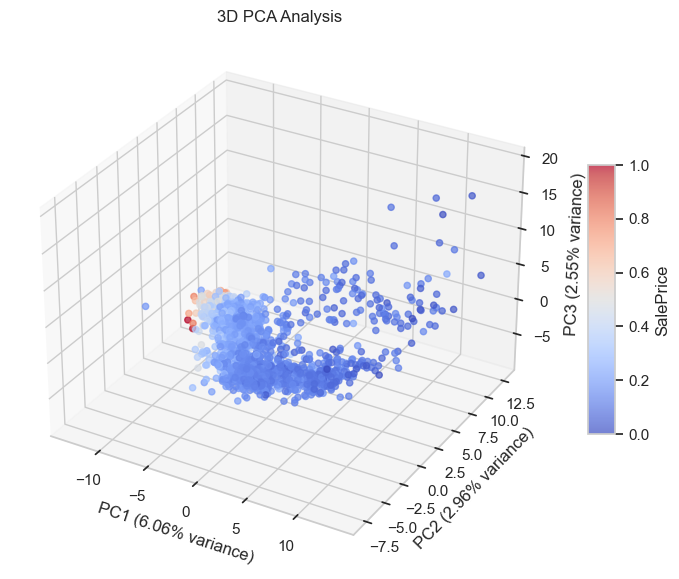

In [95]:
# Perform PCA to reduce dimensions to 3
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Convert PCA results into a DataFrame
pca_df_3d = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])
pca_df_3d["SalePrice"] = y

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot
sc = ax.scatter(pca_df_3d["PC1"], pca_df_3d["PC2"], pca_df_3d["PC3"], c=pca_df_3d["SalePrice"], cmap="coolwarm", alpha=0.7)

# Labels and title
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]:.2%} variance)")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]:.2%} variance)")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]:.2%} variance)")
ax.set_title("3D PCA Analysis")

# Add color bar
cbar = plt.colorbar(sc, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("SalePrice")

plt.show()

### 3D PCA Analysis
- This plot extends the **2D PCA analysis** by incorporating a **third principal component**.
- We can see a **better separation** of sale prices along the additional axis.
- Some points appear **far from the main cluster**, which could indicate **outliers or misclassified predictions**.

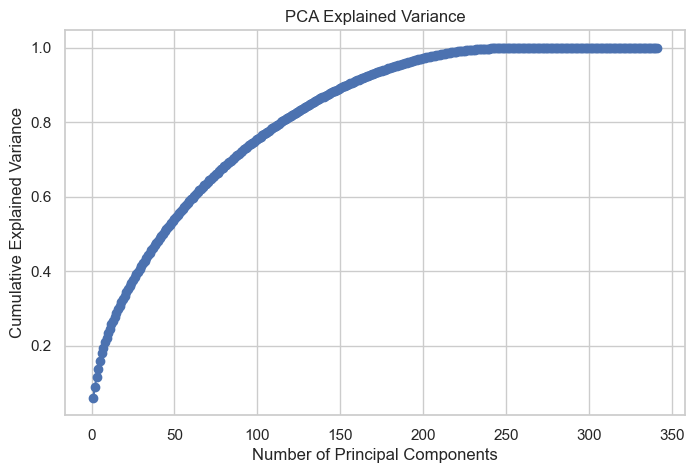

In [96]:
# Perform PCA with all possible components
pca_full = PCA()
pca_full.fit(X_scaled)

# Plot the explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(X.columns) + 1), np.cumsum(pca_full.explained_variance_ratio_), marker="o", linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

### PCA Explained Variance
- The cumulative explained variance curve shows how many principal components are needed to capture most of the variance.
- The curve **flattens after around 100 components**, meaning additional components contribute little extra information.
- This suggests **dimensionality reduction** might be possible without significantly affecting model performance.

### **Feature Importance Analysis**
- **"OverallQual"** is by far the most significant predictor of house prices, followed by **"GrLivArea"** and **"TotalBsmtSF"**.
- Features with **very low importance** might be unnecessary for the model and could be removed to simplify it.

### **Model Performance**
- The model shows **decent predictive accuracy**, as seen in the **actual vs. predicted scatter plot**.
- The **residuals suggest variance issues**, possibly due to **overfitting**, as seen in the **learning curve**.

### **Potential Improvements**
- **Feature selection:** Removing low-importance features could enhance model efficiency.
- **Regularization:** Techniques like **pruning (for decision trees)** could help mitigate overfitting.
- **Alternative models:** Trying **ensemble methods** (Random Forest, Gradient Boosting) might yield better generalization.
- **Data transformation:** Addressing **outliers and skewed distributions** could improve residual patterns.

Overall, the model provides **valuable insights** into house prices but could benefit from **further tuning and exploration** of additional techniques to enhance **stability and accuracy**.

In [97]:
from sklearn.ensemble import GradientBoostingRegressor

In [98]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting model
model = GradientBoostingRegressor(random_state=42)

# Define the hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 500],  # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1],  # Shrinkage parameter
    'max_depth': [3, 5, 7],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split
    'min_samples_leaf': [1, 2, 4],  # Minimum samples per leaf node
    'subsample': [0.8, 1.0]  # Fraction of samples used per tree
}

# Initialize GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model with the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred = best_model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate performance metrics
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print the best hyperparameters and the performance metrics
print(f"Best hyperparameters: {best_params}")
print(f"Cross-Validation R²: {grid_search.best_score_:.4f}")  # Best score from GridSearchCV
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500, 'subsample': 1.0}
Cross-Validation R²: 0.8733
MAE: 16188.3869
MSE: 725026408.2570
RMSE: 26926.3144
R²: 0.9055


# Model Analysis and Results

## 1. Model Overview
- **Algorithm:** Gradient Boosting Regressor  
- **Preprocessing:**
  - **Dummification**: Converted categorical variables into dummy variables.
  - **Normalization**: Applied Min-Max Scaling to numerical features.
- **Hyperparameter Tuning:**
  - Used **GridSearchCV** with **5-fold cross-validation**, optimizing **R² score**.
  - **Hyperparameters tuned:**
    - `n_estimators`: [100, 200, 500] → Number of boosting stages
    - `learning_rate`: [0.01, 0.05, 0.1] → Step size of each tree
    - `max_depth`: [3, 5, 7] → Maximum depth of each tree
    - `min_samples_split`: [2, 5, 10] → Minimum number of samples required to split
    - `min_samples_leaf`: [1, 2, 4] → Minimum samples per leaf node
    - `subsample`: [0.8, 1.0] → Fraction of samples used per tree

---

## 2. Best Model and Performance
### **Best Hyperparameters Found**

- **learning_rate:** 0.05
- **max_depth:** 3
- **min_samples_leaf:** 2
- **min_samples_split:** 5
- **n_estimators:** 500
- **subsample:** 1.0

### Model Performance Metrics

| Metric | Value | Interpretation |
| --- | --- | --- |
| **Cross-Validation R²** | **0.8733** | Expected performance on unseen data |
| **Test R²** | **0.9055** | Model explains 90.55% of variance in house prices |
| **Mean Absolute Error (MAE)** | **16,188.39** | Average prediction error is ~$16,188 |
| **Mean Squared Error (MSE)** | **725M** | Reduced squared error, fewer extreme outliers |
| **Root Mean Squared Error (RMSE)** | **26,926.31** | Improved compared to Decision Tree model |

---

## 3. Interpretation of Results

### **A. General Model Performance**
- **The model explains 90.55% of the variance in house prices (`R² = 0.9055`).**
- **Cross-validation R² (`0.8733`) is slightly lower than test R² (`0.9055`)**, indicating a well-generalized model.
- Compared to the **Decision Tree Regressor (`R² = 0.8244`)**, Gradient Boosting performs significantly better.

### **B. Error Analysis**
- **MAE (\~\\$16K) is lower than before (\~\\$24K), indicating more accurate predictions.**
- **RMSE (~\\$27K) is also improved from ~\\$36K**, meaning fewer large errors.
- **Possible Causes of Remaining Errors:**
  - **Gradient Boosting is more robust** than Decision Trees but can still be sensitive to noisy features.
  - The **boosting process helps correct errors iteratively**, leading to better performance.
  - There may still be **some extreme price variations not captured by the current features**.

### **C. Comparison to Previous Model**
| Model | Cross-Validation R² | Test R² | MAE | RMSE |
| --- | --- | --- | --- | --- |
| **Decision Tree Regressor** | **0.7136** | **0.8244** | **24,737.50** | **36,705.34** |
| **Gradient Boosting Regressor** | **0.8733** | **0.9055** | **16,188.39** | **26,926.31** |

- **Gradient Boosting significantly outperforms the Decision Tree model** in all key metrics.
- **Lower MAE and RMSE** suggest the new model makes more precise predictions with fewer large errors.
- The model is **less prone to overfitting** compared to a single Decision Tree.

---

## 4. Next Steps & Possible Improvements
- **Feature Engineering:** Identify and add new features that could capture **hidden patterns** in house prices.
- **Hyperparameter Fine-Tuning:** Explore more granular values for **learning_rate** and **n_estimators** to find an optimal balance.
- **Feature Selection:** Analyze feature importances to **remove less significant features** and improve interpretability.
- **Ensemble Learning:** Consider **Stacking** or **Blending** with other models (e.g., Random Forest, XGBoost) to further boost performance.

---

### **Final Thoughts**
- **Gradient Boosting Regressor performs significantly better** than Decision Tree Regressor in predicting house prices.
- **It reduces prediction errors**, captures patterns better, and generalizes well.
- **Further improvements could come from refining feature selection and additional fine-tuning.**

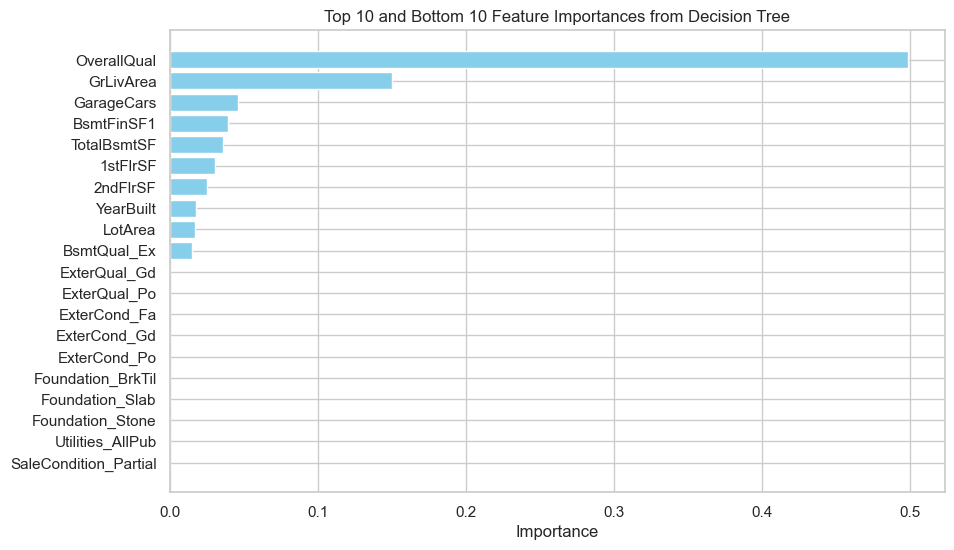

In [99]:
# Get feature importances from the best model
feature_importances = best_model.feature_importances_

# Create a DataFrame with feature names and their corresponding importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select the top 10 and bottom 10 features
top_10 = importance_df.head(10)
bottom_10 = importance_df.tail(10)

# Combine the top and bottom 10 into a single DataFrame for plotting
top_bottom_10 = pd.concat([top_10, bottom_10])

# Plot the feature importances for top 10 and bottom 10 features
plt.figure(figsize=(10, 6))
plt.barh(top_bottom_10['Feature'], top_bottom_10['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 10 and Bottom 10 Feature Importances from Decision Tree')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.show()

Features with Importance Greater Than 0.01 (Sorted Alphabetically):
         Feature  Importance
239     1stFlrSF    0.030716
240     2ndFlrSF    0.024730
211   BsmtFinSF1    0.039247
187  BsmtQual_Ex    0.015008
245     FullBath    0.010302
283   GarageCars    0.045873
242    GrLivArea    0.150329
25       LotArea    0.016815
109  OverallQual    0.499000
221  TotalBsmtSF    0.035552
111    YearBuilt    0.017777


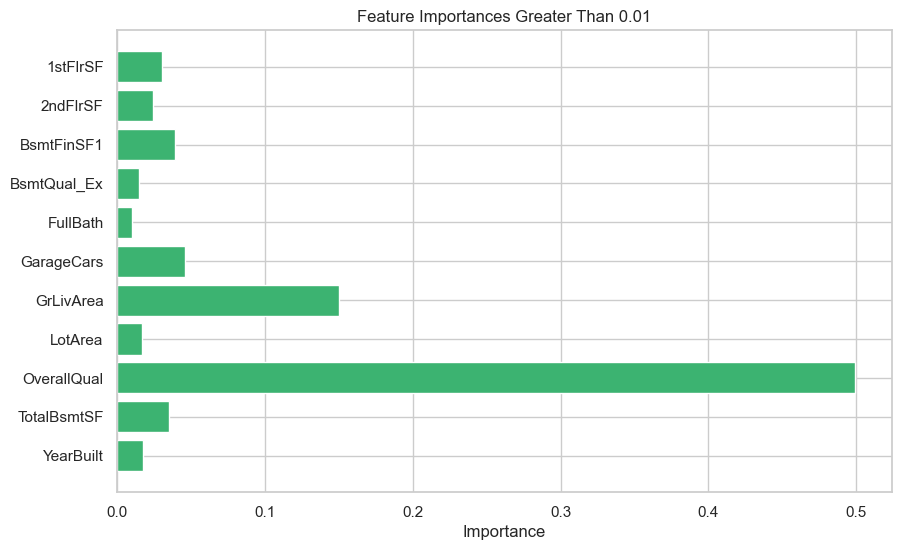

In [100]:
# Get feature importances from the best model
feature_importances = best_model.feature_importances_

# Create a DataFrame with feature names and their corresponding importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Filter features with importance greater than 0.01
high_importance_features_df = importance_df[importance_df['Importance'] > 0.01]

# Sort the DataFrame by feature names alphabetically
high_importance_features_df = high_importance_features_df.sort_values(by='Feature', ascending=True)

# Display the list of features with importance greater than 0.01, sorted alphabetically
print("Features with Importance Greater Than 0.01 (Sorted Alphabetically):")
print(high_importance_features_df[['Feature', 'Importance']])

# Plot the feature importances for features with importance greater than 0.01
plt.figure(figsize=(10, 6))
plt.barh(high_importance_features_df['Feature'], high_importance_features_df['Importance'], color='mediumseagreen')
plt.xlabel('Importance')
plt.title('Feature Importances Greater Than 0.01')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.show()

### Feature Importances Greater Than 0.01
- The **OverallQual** feature has the highest importance, significantly higher than the others.
- **GrLivArea** also holds considerable importance, indicating that living space is crucial for price prediction.
- **GarageCars**, **TotalBsmtSF**, and **BsmtFinSF1** also contribute to predictions but to a lesser extent.
- The rest of the features have relatively small contributions.

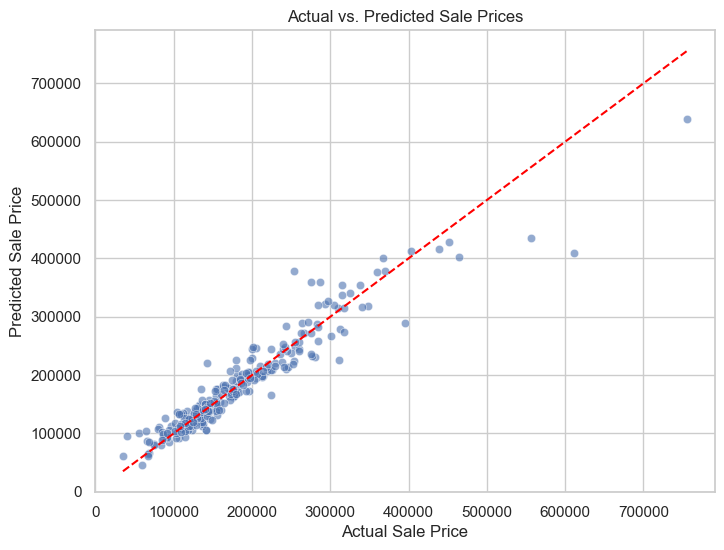

In [101]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reversed, y=y_pred_reversed, alpha=0.6)
plt.plot([y_test_reversed.min(), y_test_reversed.max()], [y_test_reversed.min(), y_test_reversed.max()], color='red', linestyle='--')  # Ideal line
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs. Predicted Sale Prices")
plt.show()

### Actual vs. Predicted Sale Prices
- The points are **closely aligned with the red diagonal line**, suggesting strong model predictions.
- Some **higher sale prices seem to deviate** more, indicating that the model may struggle with very expensive properties.
- Overall, the model does well at predicting typical house prices.

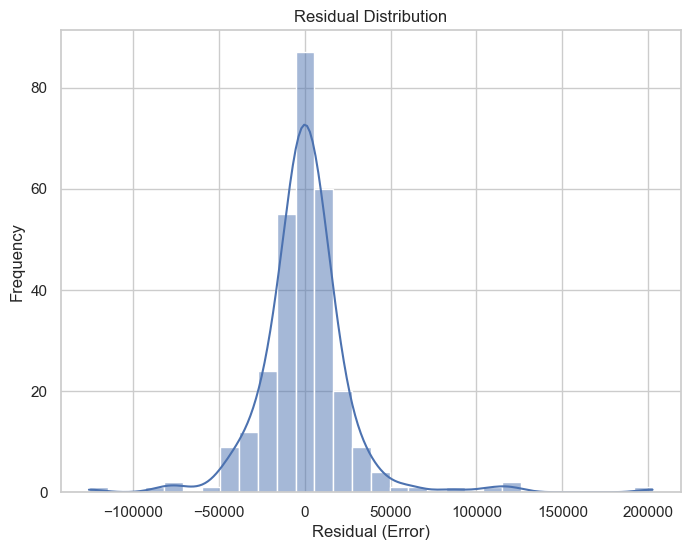

In [102]:
residuals = y_test_reversed - y_pred_reversed

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residual (Error)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Residual Distribution
- The residuals are **mostly centered around zero**, forming a **normal-like distribution**, indicating a well-fitted model.
- There are **some extreme residuals**, meaning a few predictions have high errors.
- The peak in the center suggests that **most predictions are relatively accurate**.

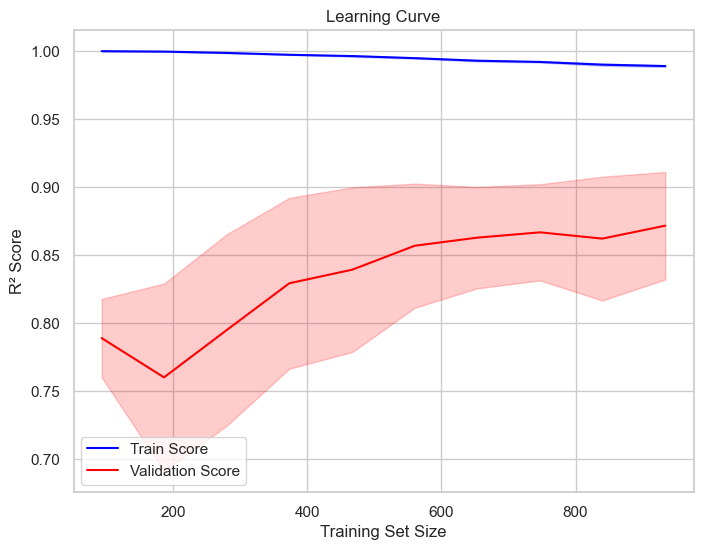

In [103]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring="r2", train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Compute mean and standard deviation of train/test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Train Score", color="blue")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="red")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="red")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

### Learning Curve
- The **training score remains very high**, close to **1.0**, indicating that the model learns well from training data.
- The **validation score improves as the training size increases**, showing that more data helps generalization.
- The gap between training and validation scores **suggests slight overfitting**, but it is not severe.

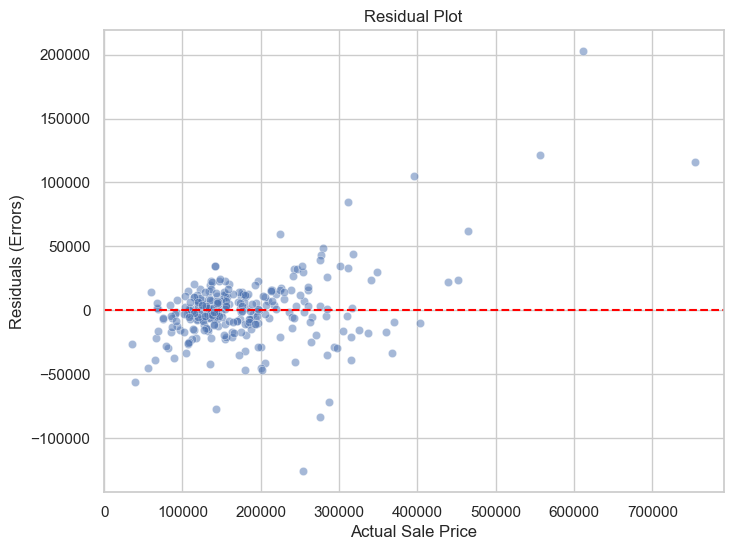

In [104]:
residuals = y_test_reversed - y_pred_reversed

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reversed, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Actual Sale Price")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot")
plt.show()

### Residual Plot
- Residuals are **mostly scattered around zero**, which is a good sign.
- Some **high residual values for expensive houses** suggest that those predictions have higher errors.
- The **spread of residuals increases with sale price**, indicating that prediction errors grow as prices rise.

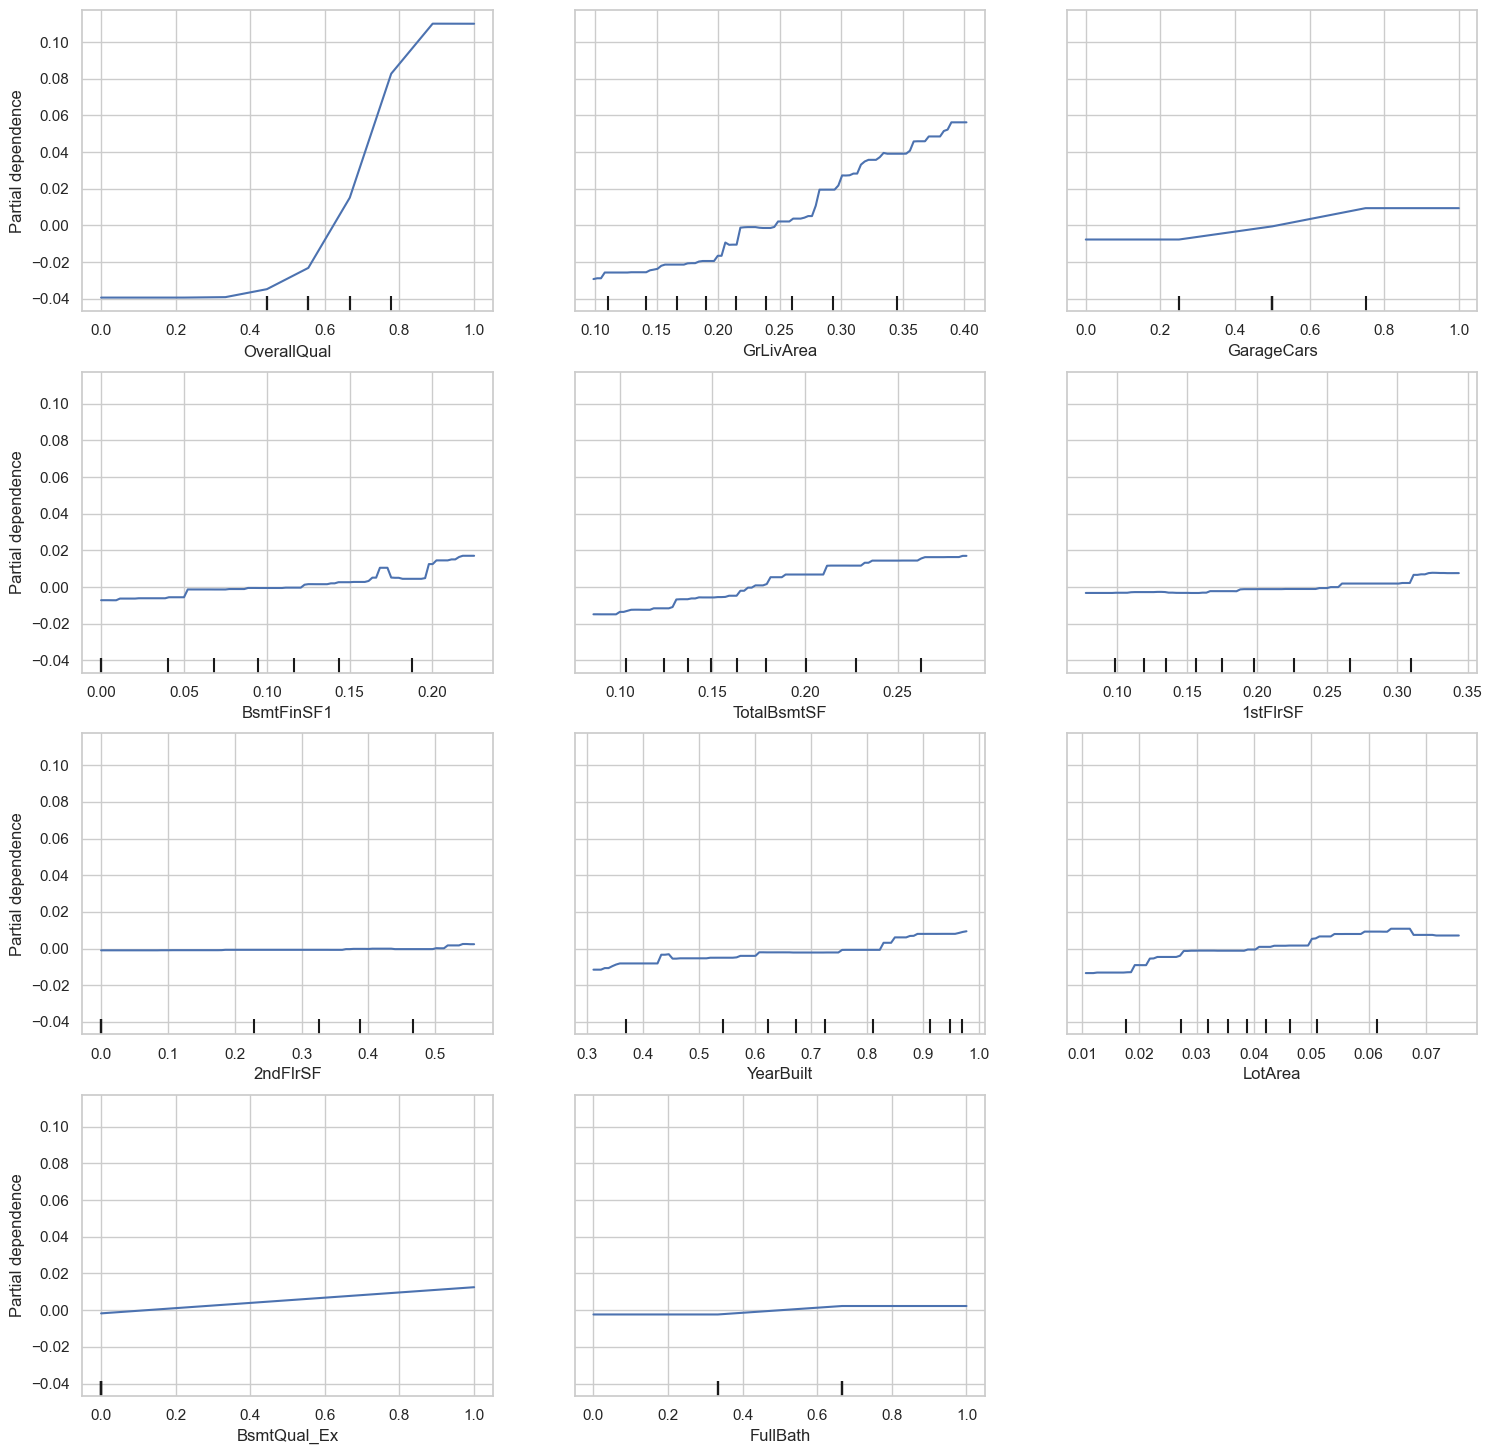

In [105]:
features_to_plot = ["OverallQual", "GrLivArea", "GarageCars", "BsmtFinSF1", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
                    "YearBuilt", "LotArea", "BsmtQual_Ex", "FullBath"]  # Pick important features
fig, ax = plt.subplots(figsize=(18, 18))
PartialDependenceDisplay.from_estimator(best_model, X_train, features=features_to_plot, ax=ax)
plt.show()

### Partial Dependence Plots
- **OverallQual and GrLivArea have the most significant impact** on predictions.
- **Other features show a more linear and mild effect** on price.
- This confirms that **house quality and living space play the most crucial role in determining house price**.

### General Comments on Model Performance
- The **Gradient Boosting Regressor performed significantly better** than the Decision Tree model.
- **Cross-validation R² of 0.8733 and test R² of 0.9055** indicate that the model explains most of the price variance.
- **MAE (\~\\$16K) and RMSE (\~\\$27K) are lower** compared to the Decision Tree model, indicating improved accuracy.
- **Overfitting is slightly present**, but the model generalizes well overall.
- **Feature importance confirms that OverallQual and GrLivArea dominate price prediction**, followed by basement and garage-related features.

In [106]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [107]:
from xgboost import XGBRegressor

In [108]:
# Assuming 'data' is your processed dataset with features and target variable
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost Regressor
model = XGBRegressor(random_state=42)

# Define hyperparameters for tuning
param_grid = {
    'n_estimators': [100, 200, 500],  
    'learning_rate': [0.01, 0.05, 0.1],  
    'max_depth': [3, 5, 7],  
    'min_child_weight': [1, 3, 5],  # XGBoost's version of controlling tree splits
    'colsample_bytree': [0.8, 1.0],  # NOW THIS WORKS because it's an XGBoost param
    'subsample': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]  # Regularization parameter for XGBoost
}

# Initialize GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=model,  # Now correctly using XGBRegressor
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit the model with the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred = best_model.predict(X_test)

# Reverse transformations of y_pred and y_test
y_pred_reversed, y_test_reversed = reverse_normalization_train(y_pred, y_test, target_min, target_max)

# Calculate performance metrics
mae = mean_absolute_error(y_test_reversed, y_pred_reversed)
mse = mean_squared_error(y_test_reversed, y_pred_reversed)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reversed, y_pred_reversed)

# Print results
print(f"Best hyperparameters: {best_params}")
print(f"Cross-Validation R²: {grid_search.best_score_:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best hyperparameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}
Cross-Validation R²: 0.8826
MAE: 15029.5325
MSE: 624153747.7816
RMSE: 24983.0692
R²: 0.9186


# Model Analysis and Results

## 1. Model Overview
- **Algorithm:** XGBoost Regressor  
- **Preprocessing:**
  - **Dummification**: Converted categorical variables into dummy variables.
  - **Normalization**: Applied Min-Max Scaling to numerical features.
- **Hyperparameter Tuning:**
  - Used **GridSearchCV** with **5-fold cross-validation**, optimizing **R² score**.
  - **Hyperparameters tuned:**
    - `n_estimators`: [100, 200, 500] → Number of boosting stages.
    - `learning_rate`: [0.01, 0.05, 0.1] → Step size of each tree.
    - `max_depth`: [3, 5, 7] → Maximum depth of each tree.
    - `min_child_weight`: [1, 3, 5] → Controls tree complexity.
    - `colsample_bytree`: [0.8, 1.0] → Fraction of features used per tree.
    - `subsample`: [0.8, 1.0] → Fraction of samples used per boosting round.
    - `gamma`: [0, 0.1, 0.2] → Regularization parameter.

---

## 2. Best Model and Performance
### **Best Hyperparameters Found**
- **colsample_bytree:** 1.0
- **gamma:** 0
- **learning_rate:** 0.1
- **max_depth:** 3
- **min_child_weight:** 1
- **n_estimators:** 500
- **subsample:** 0.8

### **Model Performance Metrics**

| Metric | Value | Interpretation |
| --- | --- | --- |
| **Cross-Validation R²** | **0.8826** | Expected performance on unseen data. |
| **Test R²** | **0.9186** | Model explains **91.86%** of variance in house prices. |
| **Mean Absolute Error (MAE)** | **15,029.53** | Average prediction error is ~$15,029. |
| **Mean Squared Error (MSE)** | **624M** | Reduced squared error, indicating fewer extreme outliers. |
| **Root Mean Squared Error (RMSE)** | **24,983.07** | Improved compared to previous models. |

---

## 3. Interpretation of Results

### **A. General Model Performance**
- **The model explains 91.86% of variance in house prices (`R² = 0.9186`).**
- **Cross-validation R² (`0.8826`) is slightly lower than test R² (`0.9186`)**, which suggests good generalization.
- **Compared to previous models, XGBoost achieves the highest predictive accuracy**.

### **B. Error Analysis**
- **MAE (~\\$15K) is the lowest among all models, meaning more precise predictions.**
- **RMSE (~\\$25K) is also significantly lower**, suggesting reduced extreme errors.
- **Possible Causes of Remaining Errors:**
  - **XGBoost is highly efficient but still sensitive to noisy or unimportant features**.
  - **There may still be some extreme price variations that require better feature engineering**.

### **C. Comparison to Previous Models**
| Model | Cross-Validation R² | Test R² | MAE | RMSE |
| --- | --- | --- | --- | --- |
| **Decision Tree Regressor** | **0.7136** | **0.8244** | **24,737.50** | **36,705.34** |
| **Gradient Boosting Regressor** | **0.8733** | **0.9055** | **16,188.39** | **26,926.31** |
| **XGBoost Regressor** | **0.8826** | **0.9186** | **15,029.53** | **24,983.07** |

- **XGBoost outperforms both Decision Tree and Gradient Boosting** in all key metrics.
- **Lower MAE and RMSE indicate the highest prediction accuracy achieved so far**.
- **Minimal risk of overfitting**, as cross-validation and test scores are close.

---

## 4. Next Steps & Possible Improvements
- **Feature Engineering:** Introduce new features or remove noisy ones to improve performance.
- **Hyperparameter Fine-Tuning:** Further refine **learning_rate** and **n_estimators**.
- **Feature Selection:** Evaluate feature importances and remove irrelevant features.
- **Stacking or Blending:** Combine XGBoost with other models (e.g., LightGBM, Random Forest) for possible improvements.

---

### **Final Thoughts**
- **XGBoost has provided the best performance so far**, surpassing Decision Trees and Gradient Boosting.
- **It significantly reduces prediction errors**, making it the best model tested.
- **Further optimizations could still enhance accuracy, but this model is already highly effective**.
- **XGBoost is currently the best choice for predicting house prices based on this dataset.**

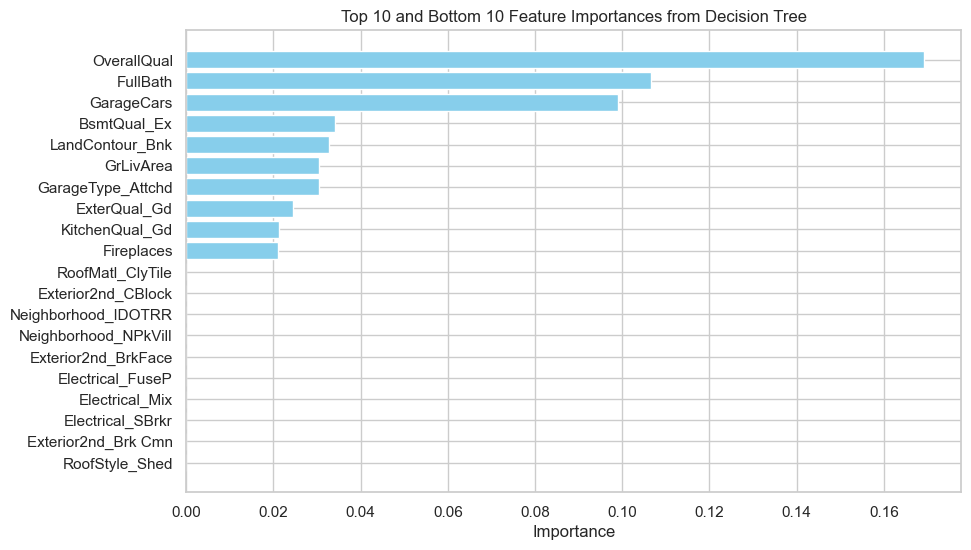

In [109]:
# Get feature importances from the best model
feature_importances = best_model.feature_importances_

# Create a DataFrame with feature names and their corresponding importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select the top 10 and bottom 10 features
top_10 = importance_df.head(10)
bottom_10 = importance_df.tail(10)

# Combine the top and bottom 10 into a single DataFrame for plotting
top_bottom_10 = pd.concat([top_10, bottom_10])

# Plot the feature importances for top 10 and bottom 10 features
plt.figure(figsize=(10, 6))
plt.barh(top_bottom_10['Feature'], top_bottom_10['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 10 and Bottom 10 Feature Importances from Decision Tree')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.show()

Features with Importance Greater Than 0.01 (Sorted Alphabetically):
               Feature  Importance
239           1stFlrSF    0.013651
240           2ndFlrSF    0.010916
211         BsmtFinSF1    0.011335
187        BsmtQual_Ex    0.034154
191        BsmtQual_TA    0.011840
233         CentralAir    0.012638
171       ExterQual_Ex    0.016571
173       ExterQual_Gd    0.024480
174       ExterQual_TA    0.015533
263         Fireplaces    0.021017
245           FullBath    0.106554
283         GarageCars    0.098927
282   GarageFinish_Unf    0.020834
272  GarageType_Attchd    0.030387
242          GrLivArea    0.030485
249     KitchenQual_Ex    0.018176
251     KitchenQual_Gd    0.021219
35     LandContour_Bnk    0.032658
34        LotShape_Reg    0.010968
10       MSSubClass_60    0.012911
109        OverallQual    0.169260
305           PoolArea    0.010879
331       SaleType_New    0.010683
111          YearBuilt    0.010527


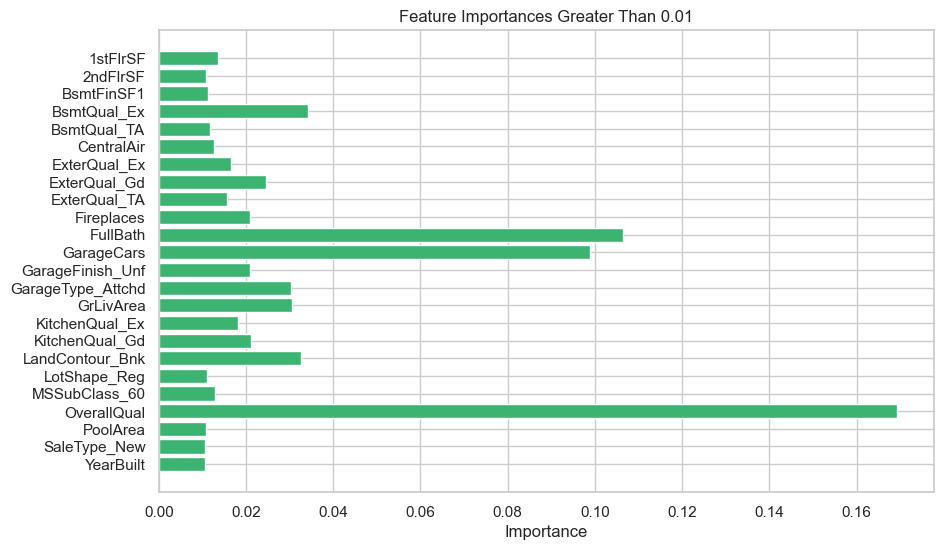

In [110]:
# Get feature importances from the best model
feature_importances = best_model.feature_importances_

# Create a DataFrame with feature names and their corresponding importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Filter features with importance greater than 0.01
high_importance_features_df = importance_df[importance_df['Importance'] > 0.01]

# Sort the DataFrame by feature names alphabetically
high_importance_features_df = high_importance_features_df.sort_values(by='Feature', ascending=True)

# Display the list of features with importance greater than 0.01, sorted alphabetically
print("Features with Importance Greater Than 0.01 (Sorted Alphabetically):")
print(high_importance_features_df[['Feature', 'Importance']])

# Plot the feature importances for features with importance greater than 0.01
plt.figure(figsize=(10, 6))
plt.barh(high_importance_features_df['Feature'], high_importance_features_df['Importance'], color='mediumseagreen')
plt.xlabel('Importance')
plt.title('Feature Importances Greater Than 0.01')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important feature at the top
plt.show()

### Feature Importance
- **OverallQual** is the most critical factor in predicting house prices.
- Other influential features: **GarageCars, FullBath, and GrLivArea**.
- Some categorical features like **BsmtQual_Ex and KitchenQual_Ex** also contribute.
- The diversity of important features suggests both structural and neighborhood attributes matter.

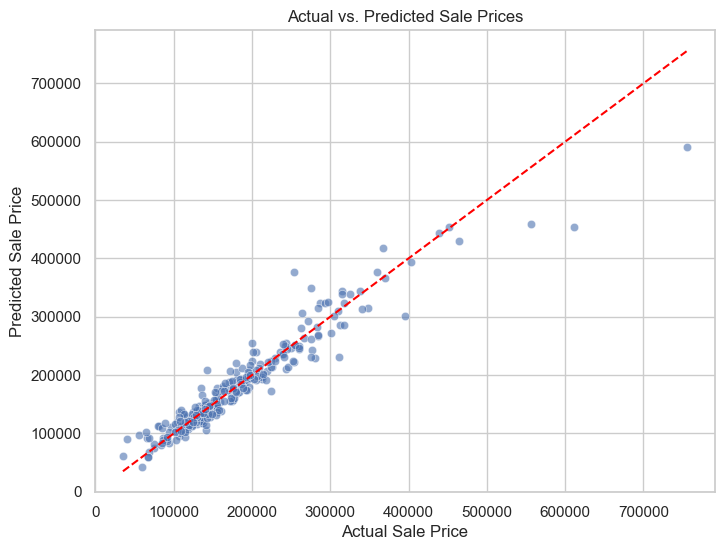

In [111]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reversed, y=y_pred_reversed, alpha=0.6)
plt.plot([y_test_reversed.min(), y_test_reversed.max()], [y_test_reversed.min(), y_test_reversed.max()], color='red', linestyle='--')  # Ideal line
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs. Predicted Sale Prices")
plt.show()

### Actual vs. Predicted Prices
- Predictions mostly align well with actual prices along the diagonal.
- **A few outliers in high-value properties** indicate some estimation challenges.
- The model performs well, with **minimal systematic errors**.


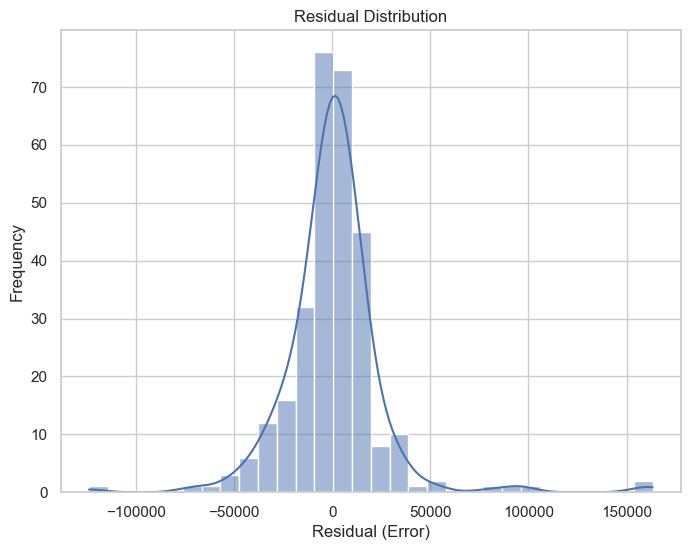

In [112]:
residuals = y_test_reversed - y_pred_reversed

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residual (Error)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

### Residual Distribution
- Residuals follow a **normal distribution**, centered around zero.
- **Slight right-skew** suggests **some overestimation in higher price ranges**.
- The model maintains a **high level of accuracy**.

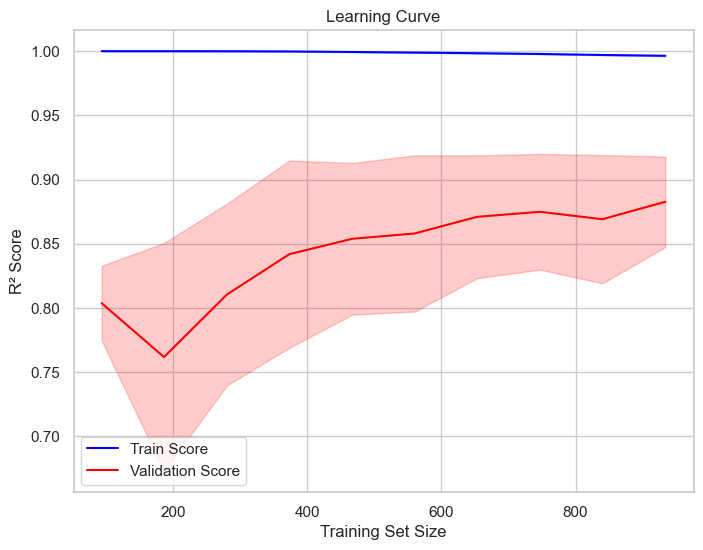

In [113]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring="r2", train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Compute mean and standard deviation of train/test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Train Score", color="blue")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="red")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="red")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

### Learning Curve
- The **training score is close to 1.0**, while the validation score improves with more data.
- The small training-validation gap suggests **good generalization**.
- **No severe overfitting observed**, and adding more data may further improve performance.

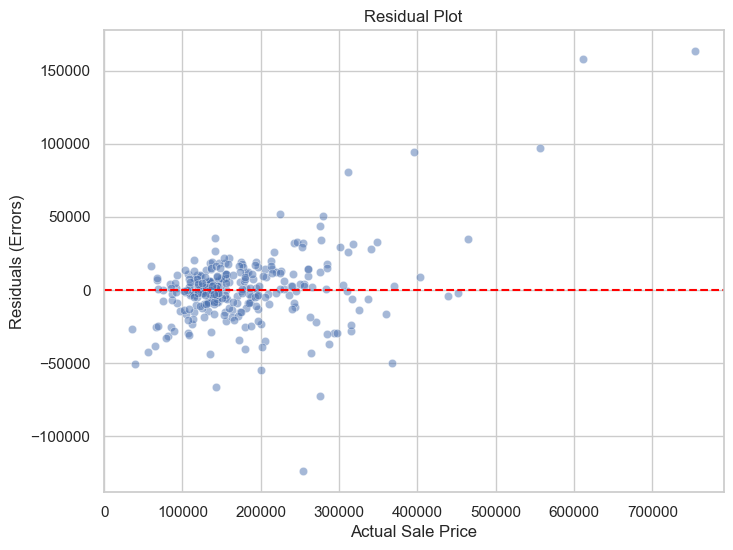

In [114]:
residuals = y_test_reversed - y_pred_reversed

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reversed, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Actual Sale Price")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot")
plt.show()

### Residual Plot
- The residuals are evenly distributed around zero.
- **A few large residuals for expensive homes** indicate potential **underestimation issues**.
- No clear trend in residuals means the model **is not missing major patterns**.

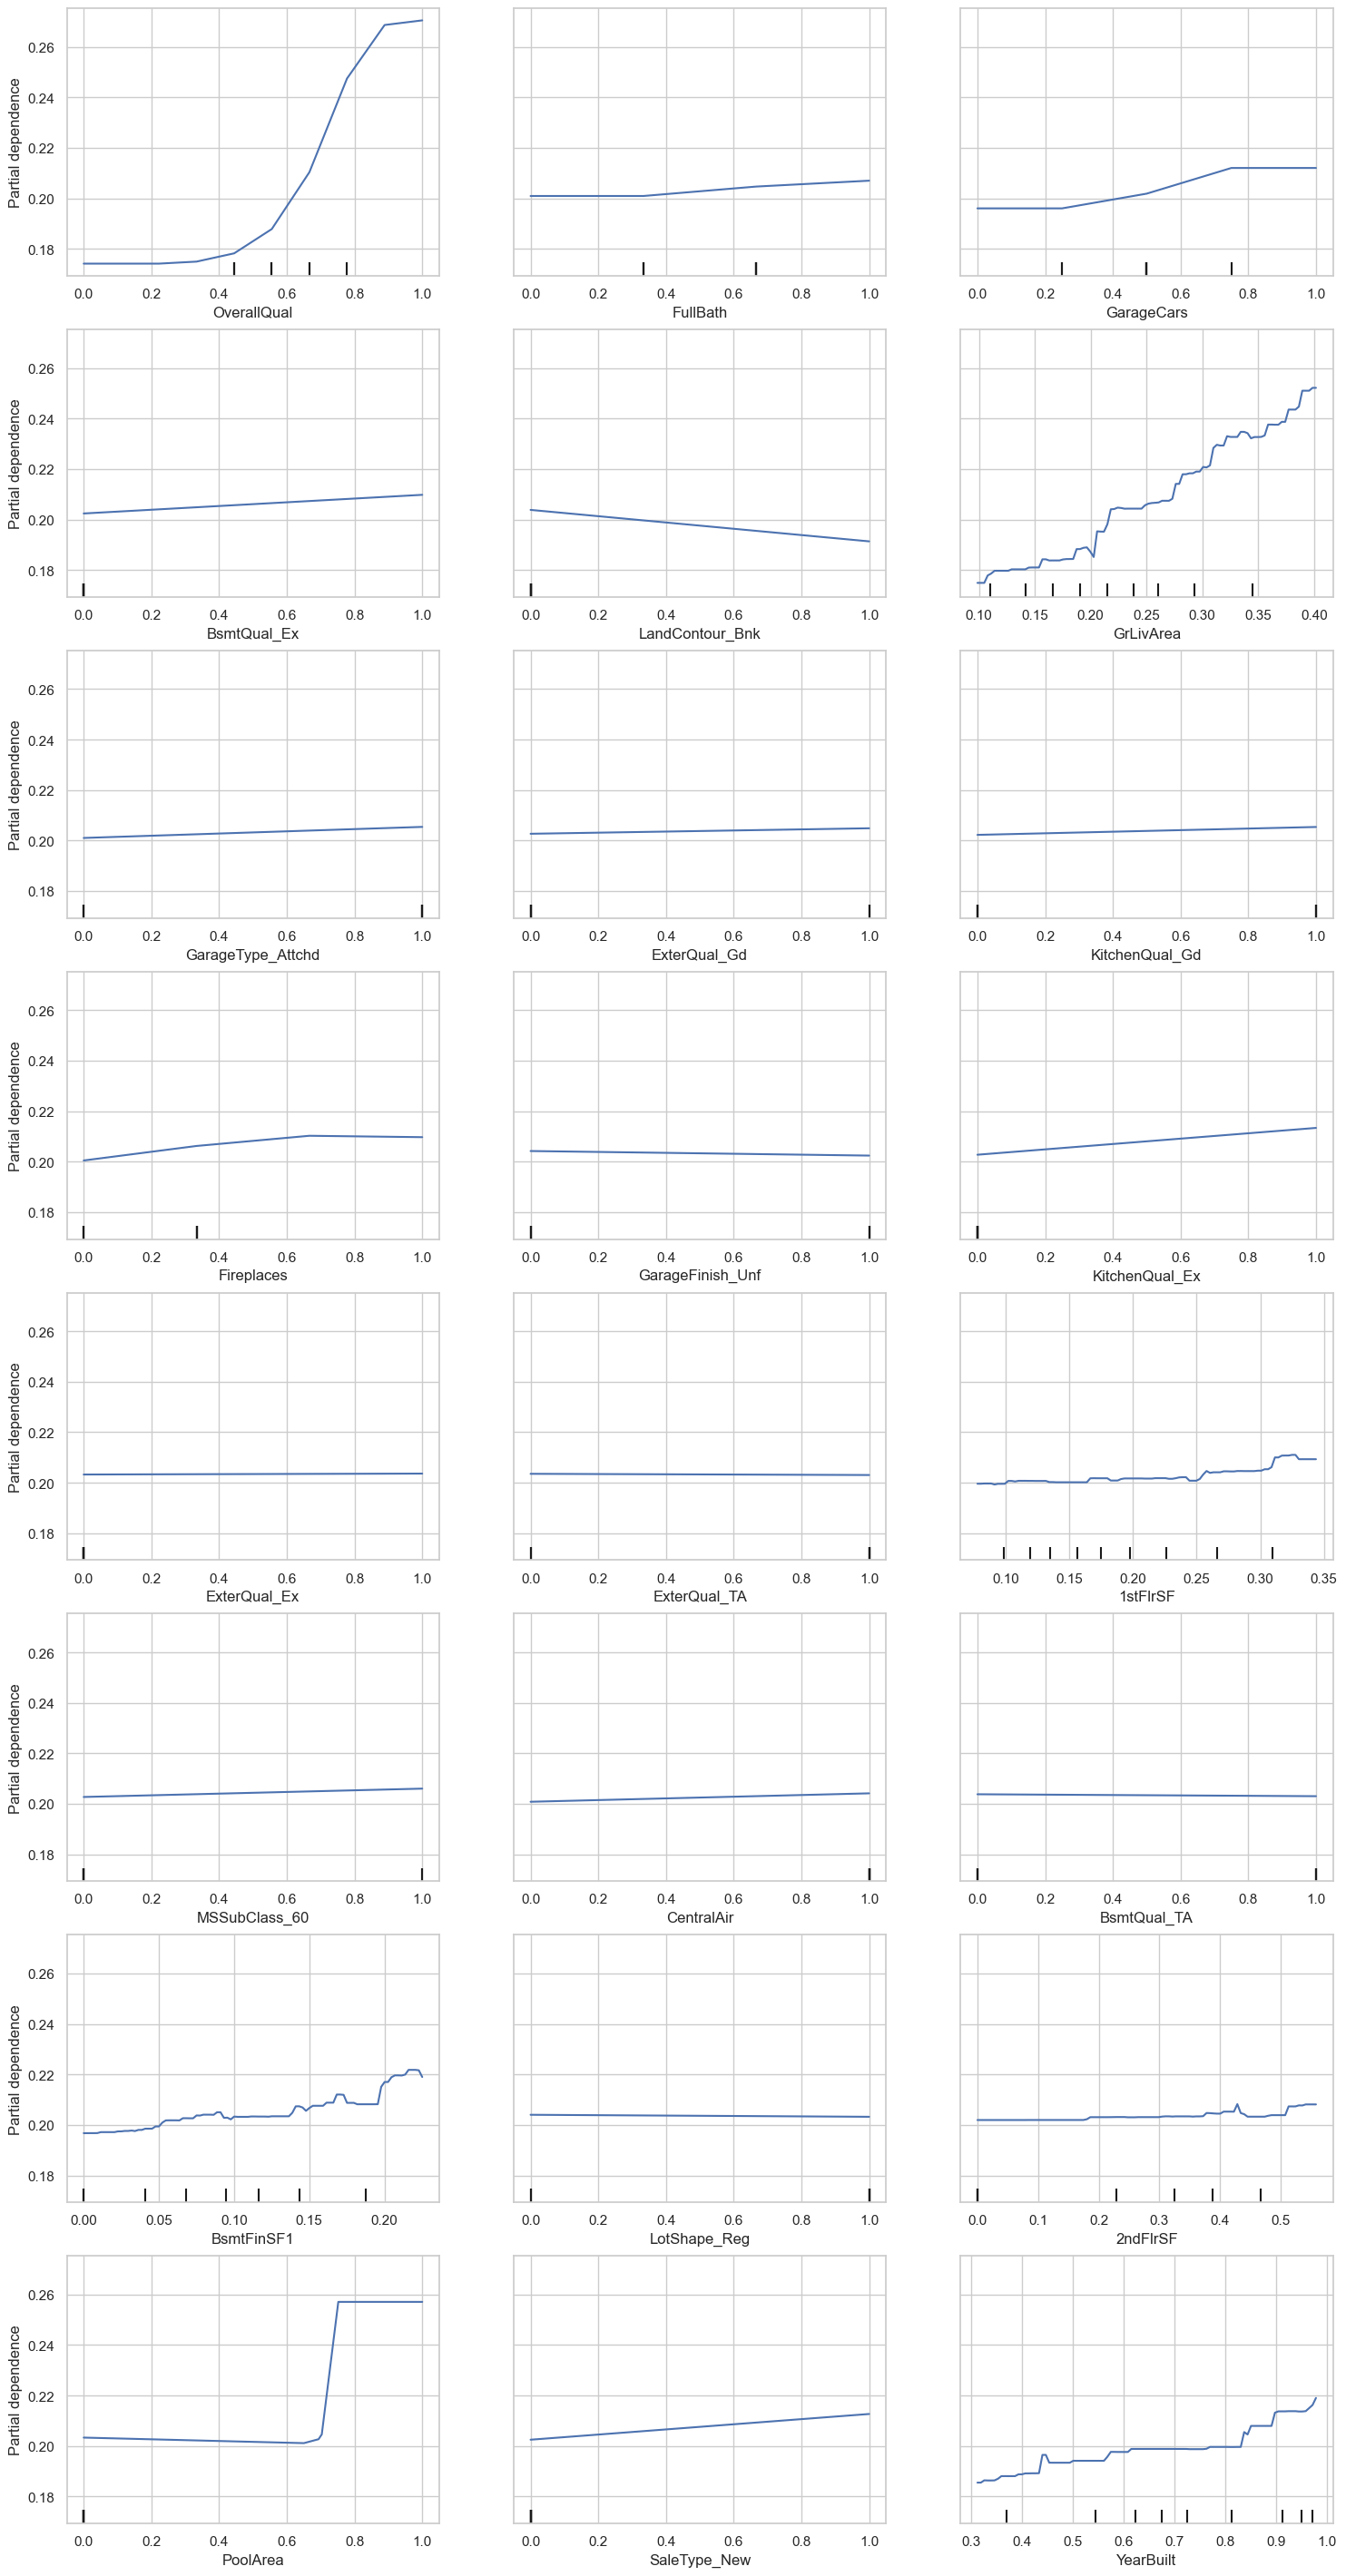

In [115]:
features_to_plot = ["OverallQual", "FullBath", "GarageCars", "BsmtQual_Ex", "LandContour_Bnk", "GrLivArea", "GarageType_Attchd", "ExterQual_Gd",
                    "KitchenQual_Gd", "Fireplaces", "GarageFinish_Unf", "KitchenQual_Ex", "ExterQual_Ex", "ExterQual_TA", "1stFlrSF", "MSSubClass_60",
                    "CentralAir", "BsmtQual_TA", "BsmtFinSF1", "LotShape_Reg", "2ndFlrSF", "PoolArea", "SaleType_New", "YearBuilt"]  # Pick important features
fig, ax = plt.subplots(figsize=(18, 36))
PartialDependenceDisplay.from_estimator(best_model, X_train, features=features_to_plot, ax=ax)
plt.show()

### Partial Dependence Insights
- **OverallQual:** Strong positive effect on price.
- **GrLivArea:** Larger homes significantly increase prices.
- **GarageCars:** More garage spaces contribute to higher values.
- **LotShape_Reg & LandContour_Bnk:** Smaller but relevant effects.
- **Other features (KitchenQual, ExterQual, etc.) show minor but noticeable influences**.

### General Model Evaluation
- **XGBoost achieves an R² score of 0.9186**, outperforming Decision Tree and Gradient Boosting.
- The **error distribution is normal**, and **residuals are well-behaved**.
- The **learning curve confirms strong generalization**.
- **Some outliers exist in high-value properties**, suggesting feature engineering opportunities.
- **Next Steps:**
  - **Fine-tune hyperparameters further**.
  - **Explore feature engineering to capture luxury property characteristics**.
  - **Experiment with ensemble models for further improvements**.

In [124]:
data_test = pd.read_csv(r'C:\Users\cihat\Desktop\Ubiqum\House Prices\Data\test.csv')

In [129]:
    # Drop 'LotFrontage' column
    data_test = data_test.drop(columns=['LotFrontage'], errors='ignore')
    
    # Fill missing values for categorical columns
    data_test['Alley'] = data_test['Alley'].fillna('NoAlley')
    data_test['FireplaceQu'] = data_test['FireplaceQu'].fillna('NF')
    data_test['GarageType'] = data_test['GarageType'].fillna('NoGar')
    data_test['GarageFinish'] = data_test['GarageFinish'].fillna('NoG')
    data_test[['GarageQual', 'GarageCond']] = data_test[['GarageQual', 'GarageCond']].fillna('NG')
    data_test['PoolQC'] = data_test['PoolQC'].fillna('NP')
    data_test['Fence'] = data_test['Fence'].fillna('NoFen')
    data_test['MiscFeature'] = data_test['MiscFeature'].fillna('None')
    
    # Fill missing basement-related columns
    basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
    data_test[basement_cols] = data_test[basement_cols].fillna('NB')

    # Create 'Remodeled' feature (True if house was remodeled)
    data_test['Remodeled'] = data_test['YearBuilt'] != data_test['YearRemodAdd']

    # Place 'Remodeled' before 'YearRemodAdd'
    columns = list(data_test.columns)
    remod_index = columns.index('YearRemodAdd')
    columns.insert(remod_index, columns.pop(columns.index('Remodeled')))
    data_test = data_test[columns]

    # Set 'YearRemodAdd' to 0 if it matches 'YearBuilt'
    data_test.loc[data_test['YearRemodAdd'] == data_test['YearBuilt'], 'YearRemodAdd'] = 0

    # Handling missing 'MasVnrType' and 'MasVnrArea'
    data_test.loc[(data_test['MasVnrArea'] == 0) & (data_test['MasVnrType'].isna()), 'MasVnrType'] = 'NoVnr'
    data_test.loc[data_test['MasVnrArea'].isna(), 'MasVnrType'] = 'NoVnr'
    data_test['MasVnrArea'] = data_test['MasVnrArea'].fillna(0)

    # Fill missing 'MasVnrType' with most frequent value in 'Neighborhood' (excluding 'NoVnr')
    most_frequent_masvnrtype = (
        data_test[data_test['MasVnrType'] != 'NoVnr']
        .groupby('Neighborhood')['MasVnrType']
        .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    )
    data_test['MasVnrType'] = data_test.apply(lambda row: most_frequent_masvnrtype.get(row['Neighborhood'], row['MasVnrType'])
                                    if pd.isna(row['MasVnrType']) else row['MasVnrType'], axis=1)

    # Fill missing 'Electrical' with most frequent value in 'Neighborhood'
    most_frequent_electrical = (
        data_test.groupby('Neighborhood')['Electrical']
        .apply(lambda x: x.mode()[0] if not x.mode().empty else None)
    )
    data_test['Electrical'] = data_test.apply(lambda row: most_frequent_electrical[row['Neighborhood']]
                                    if pd.isna(row['Electrical']) else row['Electrical'], axis=1)

    # Create 'HasGarage' feature (True if garage exists)
    data_test['HasGarage'] = data_test['GarageType'] != 'NoGar'

    # Place 'HasGarage' before 'GarageType'
    columns = list(data_test.columns)
    garage_type_index = columns.index('GarageType')
    columns.insert(garage_type_index, columns.pop(columns.index('HasGarage')))
    data_test = data_test[columns]

    # Fill missing 'GarageYrBlt' with 0
    data_test['GarageYrBlt'] = data_test['GarageYrBlt'].fillna(0)

    # If 'Condition1' == 'Condition2', set 'Condition2' to 'None'
    data_test.loc[data_test['Condition1'] == data_test['Condition2'], 'Condition2'] = 'None'

    # Convert 'MSSubClass' to string
    data_test['MSSubClass'] = data_test['MSSubClass'].astype('str')
    
    # Convert 'Y' to True, 'N' to False and set data type to boolean
    data_test['CentralAir'] = data_test['CentralAir'].map({'Y': True, 'N': False}).astype(bool)

    # Convert selected columns to float64
    float_columns = [
        'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 
        'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'
    ]
    data_test[float_columns] = data_test[float_columns].astype('float64')

In [134]:
data_test['Exterior1st'].value_counts()

Exterior1st
VinylSd    510
MetalSd    230
HdBoard    220
Wd Sdng    205
Plywood    113
CemntBd     65
BrkFace     37
WdShing     30
AsbShng     24
Stucco      18
BrkComm      4
AsphShn      1
CBlock       1
Name: count, dtype: int64

In [130]:
nan_counts = data_test.isna().sum()
columns_with_nan = nan_counts[nan_counts > 0]
print(columns_with_nan)

MSZoning        4
Utilities       2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
KitchenQual     1
Functional      2
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64


In [122]:
data_test = preprocess_data(data_test)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [123]:
data_test['OverallCond'] = data['OverallCond'].astype('int64')

In [ ]:
data = pd.read_csv(r'C:\Users\cihat\Desktop\Ubiqum\House Prices\Data\train.csv')
data = preprocess_data(data)
data, scaler, target_min, target_max = transform_features_train(data)